In [95]:
#EVERY CELL CAN BE RUN INDEPENDENTLY, BUT THIS ONE HAS TO BE RUN ALWAYS BEFORE YOU RAN ANY OTHER:implements the metadata inside the program + the condition we want to run our code inside

import pandas as pd
import os 
import json
import numpy as np
import ast
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns

#LETS BUILD A PLOT FOR EACH LINEAGE IN THE METDATA FILE GIVEN BY TAMARA, in order to analyze the frequence of each new junction evdience that wasn't directly assigned
#to a single mutation

pars_folder = 'stdpar' #SELECT THE PARAMETERS YOU WANT TO ANALYZE THE DATA FROM
metadata = pd.read_csv('/scicore/home/nimwegen/bojani0000/20260808-succinate-data/Succinate_samples_AP_202607_metadata.csv') #read the data labelling each well

metadata['Sample_name'] = metadata['Sample_name'].str.replace('_','-') #fix the names to be suitable for your dataset

n_lineages = max(metadata['Lineage'].fillna(0).astype(float)) #set the number

dict_lineages = {}

for i in range(1, int(n_lineages+1)):
    dict_lineages.update({i:metadata[metadata['Lineage']==float(i)]})  #divide the metadata through the indexes

dict_lineages


B8_coverage = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/Pre-culture-B8-breseq/data/coverage.csv'
H1_coverage = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/Pre-culture-H1-breseq/data/coverage.csv'
dict_precultures = {'B8': B8_coverage ,
                   'H1': H1_coverage}


{1:     Unnamed: 0 Sample_name Strain Media_growth_round  Lineage  Growth_rate  \
 2            3  B8-SUC1-G9     B8              Suc_1      1.0         0.55   
 8            9   B8-GLU-G9     B8                Glu      1.0         1.03   
 14          15  B8-SUC2-G5     B8              Suc_2      1.0         0.71   
 
    Growth_rate_trend_suc1                Yield_info  
 2                    FLAT  high yield to high yield  
 8                    FLAT  high yield to high yield  
 14                   FLAT  high yield to high yield  ,
 2:     Unnamed: 0  Sample_name Strain Media_growth_round  Lineage  Growth_rate  \
 3            4  B8-SUC1-F10     B8              Suc_1      2.0         0.82   
 9           10   B8-GLU-F10     B8                Glu      2.0         1.10   
 15          16   B8-SUC2-F8     B8              Suc_2      2.0         0.85   
 
    Growth_rate_trend_suc1                Yield_info  
 3                    FLAT  high yield to high yield  
 9                    F

/scratch/cappel0001/slurm-job.21044080/ipykernel_765470/1641629525.py:30: DtypeWarning: Columns (1,2,5,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63) have mixed types. Specify dtype option on import or set low_memory=False.
  breseq_sample = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' +pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names) #upload the output file
/scratch/cappel0001/slurm-job.21044080/ipykernel_765470/1641629525.py:30: DtypeWarning: Columns (1,2,5,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63) have mixed types. Specify dtype option on import or set low_memory=False.
  breseq_sample = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' +pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names) #upload the output file


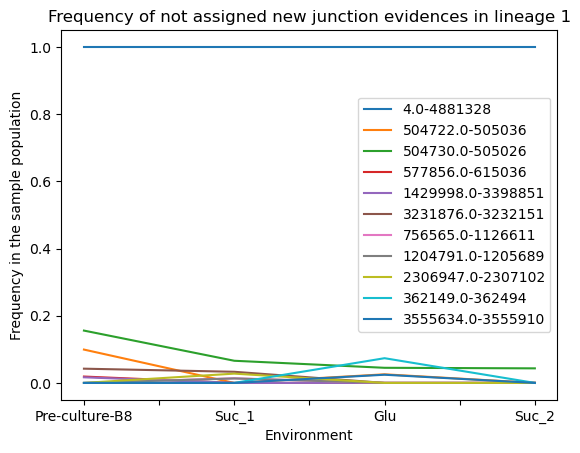

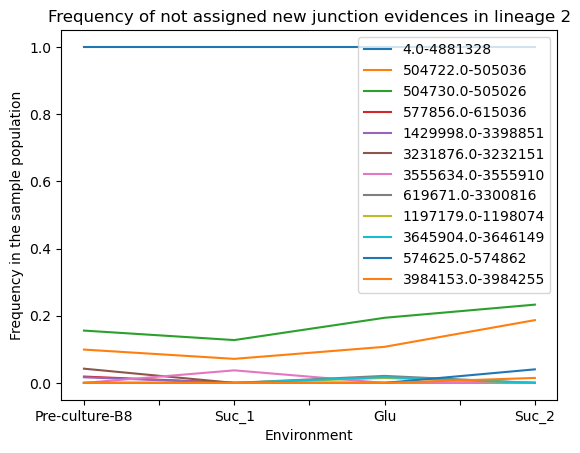

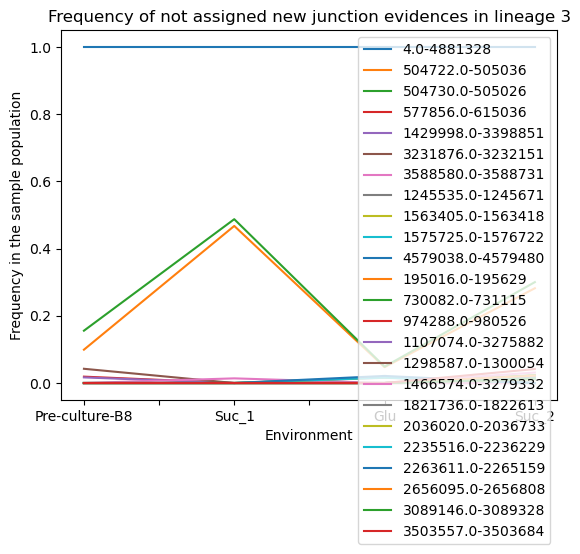

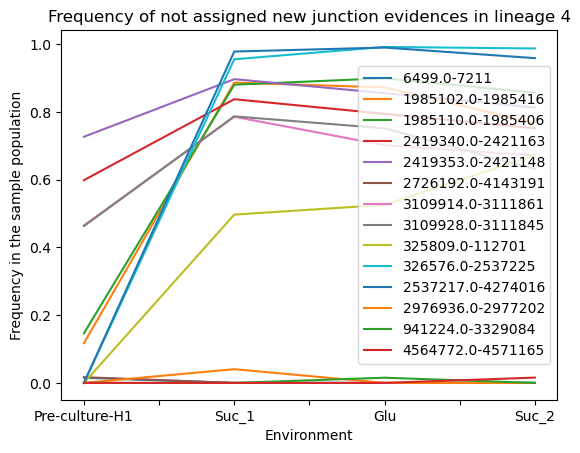

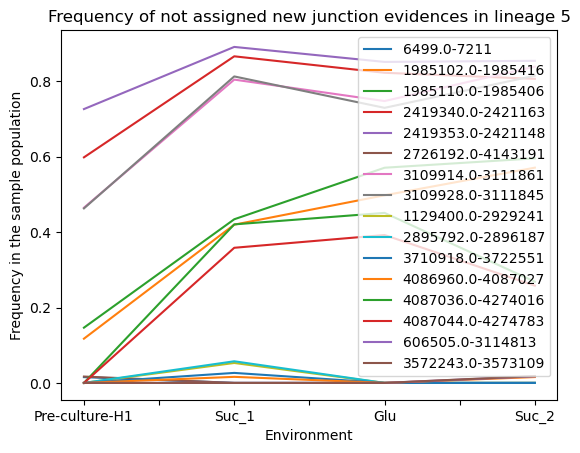

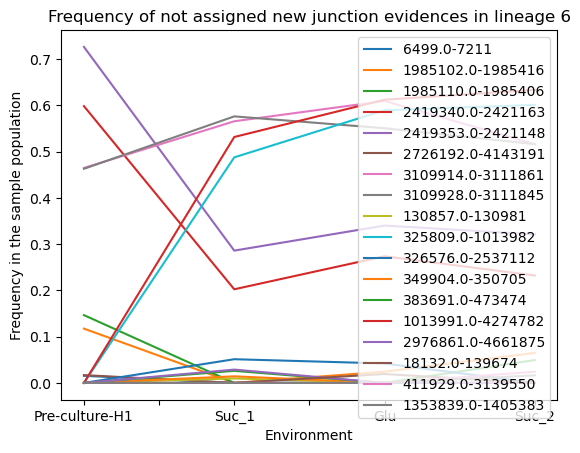

In [2]:


for i in dict_lineages.keys():

    working_df = dict_lineages[i]
    max_expected_columns = 70
    column_names = [f"col_{i}" for i in range(max_expected_columns)]
    #fig, axes = plt.subplots(1, len(working_df), squeeze =False)

    #LET'S CREATE THE PLOT_FREQUENCIES with the full dataset of variation from the preculture

    strain = dict_lineages[i].iloc[0]['Strain'] #let's identify the sample we need
    preculture_name = metadata[metadata['Sample_name'].str.endswith(strain)]['Sample_name'].iloc[0] #let's get the right row by looking at the end of the sample name, then select the name of the
    #preculture
    prec_sample = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' +pars_folder + '/'+preculture_name+'-breseq/data/annotated.gd', sep='\t', names = column_names)

    prec_JC = prec_sample[prec_sample['col_0']=='JC'] #let's take only the missing JC evidences
    #FREQUENCIES ARE AT COLUMN 15, IN STRINGS 'frequency=float'
    prec_JC = prec_JC[prec_JC['col_16']!='ignore=CIRCULAR_CHROMOSOME'] #let's ignore the circular chromosomes
    prec_JC = prec_JC[prec_JC['col_34'].str.startswith('polymorphism_frequency')] #2nd filter:exclude the no show columns
    prec_JC = prec_JC[prec_JC['col_37'].str.startswith('side')] #3rd filter:exclude the rejected ones
    frequencies = prec_JC['col_15'].str.strip('frequency=').astype(float) #extract the frequencies
    position_identifiers = prec_JC['col_4'].astype(str)+'-'+(prec_JC['col_7'].astype(int)).astype(str) #get the label that identifies the position of each single new junction ev
    
    tmp_df = pd.DataFrame(frequencies).set_index(position_identifiers).rename(columns={'col_15':preculture_name}) #change the name of the column with the medias in order to automatically plot
    plot_frequencies = [tmp_df]

    
    for j in working_df.index: #now let's take the output file for each sample
        sample = working_df.loc[j]['Sample_name']
        media = working_df.loc[j]['Media_growth_round']
        breseq_sample = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' +pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names) #upload the output file
        breseq_JC = breseq_sample[breseq_sample['col_0']=='JC'] #let's take only the missing JC evidences
        #FREQUENCIES ARE AT COLUMN 15, IN STRINGS 'frequency=float'
        breseq_JC = breseq_JC[breseq_JC['col_16']!='ignore=CIRCULAR_CHROMOSOME'] #let's ignore the circular chromosomes
        breseq_JC = breseq_JC[breseq_JC['col_34'].str.startswith('polymorphism_frequency')] #2nd filter:exclude the no show columns
        breseq_JC = breseq_JC[breseq_JC['col_37'].str.startswith('side')] #3rd filter:exclude the rejected ones
        frequencies = breseq_JC['col_15'].str.strip('frequency=').astype(float) #extract the frequencies
        position_identifiers = breseq_JC['col_4'].astype(str)+'-'+(breseq_JC['col_7'].astype(int)).astype(str) #get the label that identifies the position of each single new junction ev
        
        tmp_df = pd.DataFrame(frequencies).set_index(position_identifiers).rename(columns={'col_15':media}) #change the name of the column with the medias in order to automatically plot 
        #the right elements on the x-axis
        plot_frequencies.append(tmp_df)

    plot_df = pd.concat(plot_frequencies,  axis = 1)
    plot_df = plot_df.fillna(0).T
    plot_df.plot(title = 'Frequency of not assigned new junction evidences in lineage '+str(i), xlabel = 'Environment', ylabel = 'Frequency in the sample population')


        


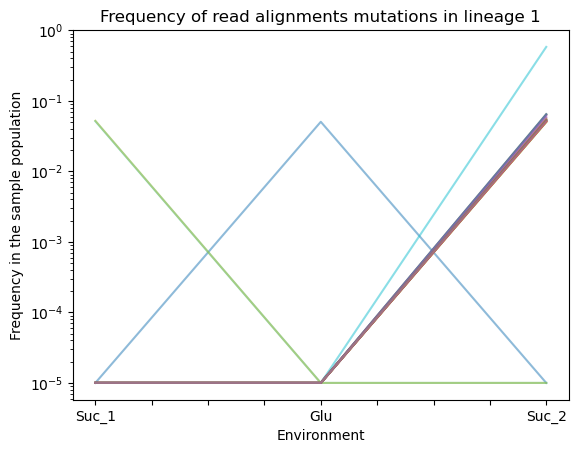

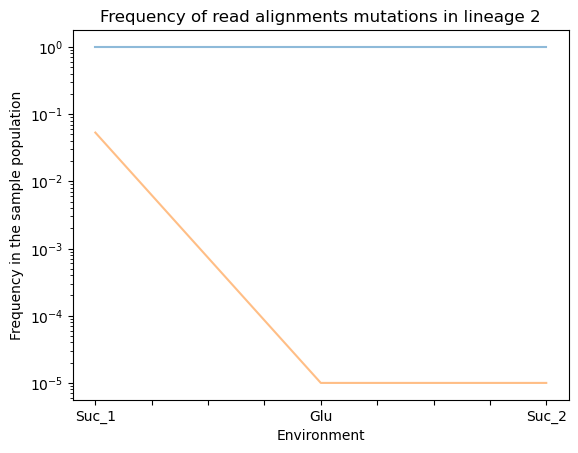

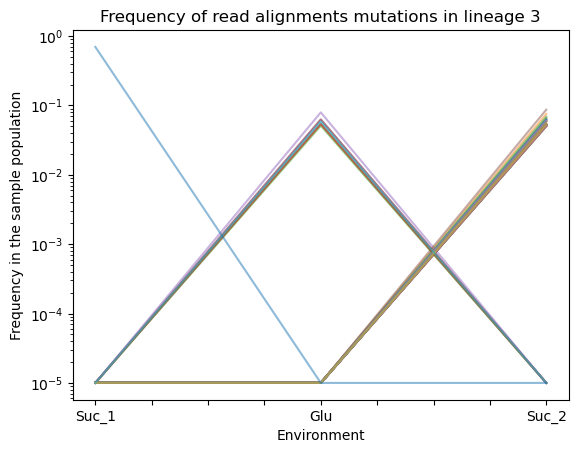

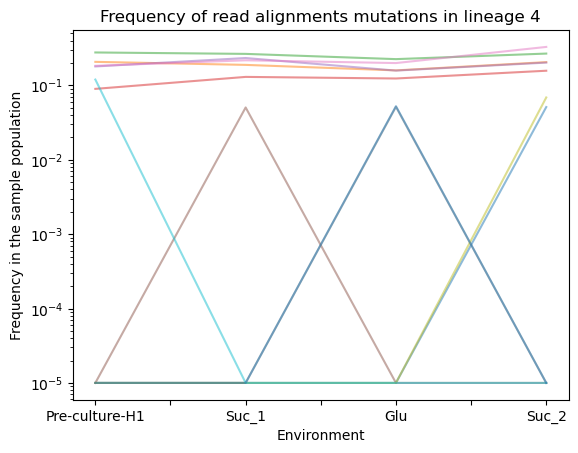

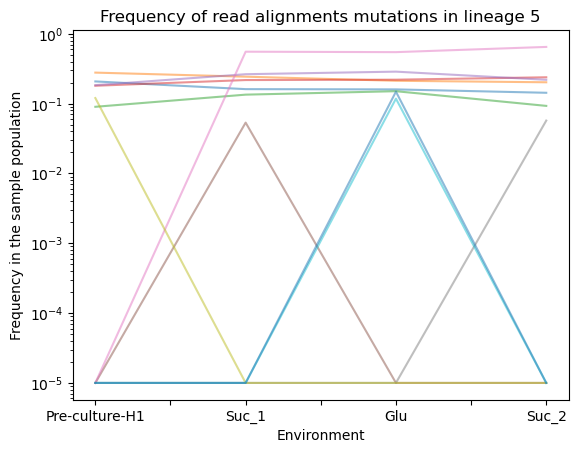

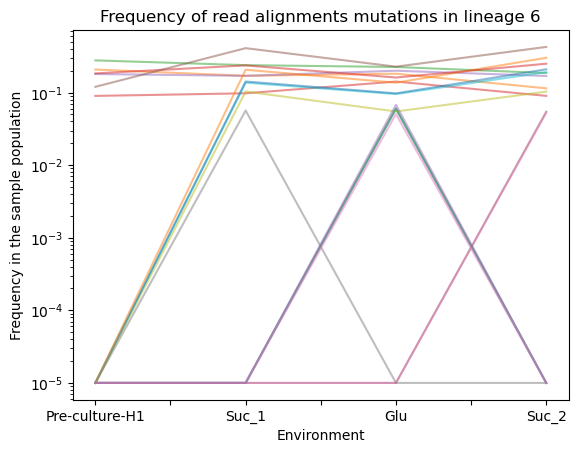

In [13]:
#plotting the same plots for read alignment


for i in dict_lineages.keys():

    working_df = dict_lineages[i]
    max_expected_columns = 70
    column_names = [f"col_{i}" for i in range(max_expected_columns)]

    # LET'S CREATE THE PLOT_FREQUENCIES with the full dataset of variation from the preculture
    strain = dict_lineages[i].iloc[0]['Strain'] 
    preculture_name = metadata[metadata['Sample_name'].str.endswith(strain)]['Sample_name'].iloc[0] 
    
    prec_sample = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/'+preculture_name+'-breseq/data/annotated.gd', sep='\t', names = column_names)

    prec_RA = prec_sample[prec_sample['col_0']=='RA']
    frequencies_prec = []
    
    if len(prec_RA)!=0: 
        frequencies_prec = np.zeros(len(prec_RA))
        has_reject = prec_RA.astype(str).apply(lambda row: row.str.startswith('reject').any(), axis=1) 
        prec_RA = prec_RA[~has_reject] 
        
        # YOU WILL HAVE TO GET THE FREQUENCIES FOR EACH ROW 
        only_frequencies_mask = prec_RA.astype(str).apply(lambda row: row.str.startswith('frequency='))
        only_frequencies_df = prec_RA[only_frequencies_mask]
        frequencies = np.array(only_frequencies_df.bfill(axis=1)['col_0'].str.strip('frequency=').astype(float).reset_index(drop=True))
        
        # OPTION 2: Create a unique index using Position (col_4) + Alt Base (col_5)
        position_ids = prec_RA['col_4'].astype(str) + "_" + prec_RA['col_5'].astype(str)
        
        prec_series = pd.Series(data=frequencies, index=position_ids.values, dtype=float)
        # Bulletproof protection: resolve any remaining exact identical duplicates by taking the max
        prec_series = prec_series.groupby(level=0).max() 
        
        plot_df = {preculture_name:prec_series}
    else:
        plot_df = {}

    for j in working_df.index: 
        sample = working_df.loc[j]['Sample_name']
        media = working_df.loc[j]['Media_growth_round']
        breseq_sample = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/'+ sample + '-breseq/data/annotated.gd', sep='\t', names = column_names) 
        
        breseq_RA = breseq_sample[breseq_sample['col_0']=='RA']
        has_reject = breseq_RA.astype(str).apply(lambda row: row.str.startswith('reject').any(), axis=1) 
        breseq_RA = breseq_RA[~has_reject] 
        
        # YOU WILL HAVE TO GET THE FREQUENCIES FOR EACH ROW
        only_frequencies_mask = breseq_RA.astype(str).apply(lambda row: row.str.startswith('frequency='))
        only_frequencies_df = breseq_RA[only_frequencies_mask]
        frequencies = np.array(only_frequencies_df.bfill(axis=1)['col_0'].str.strip('frequency=').astype(float).reset_index(drop=True))
        
        # OPTION 2: Create a unique index using Position (col_4) + Alt Base (col_5)
        position_ids = breseq_RA['col_4'].astype(str) + "_" + breseq_RA['col_5'].astype(str)
        
        prec_series = pd.Series(data=frequencies, index=position_ids.values, dtype=float)
        # Bulletproof protection: resolve any remaining exact identical duplicates by taking the max
        prec_series = prec_series.groupby(level=0).max() 
        
        plot_df.update({media:prec_series})

    plot_df = pd.DataFrame(plot_df).T.fillna(0) + pow(10, -5)
    
    # Legend turned off via legend=False
    plot_df.plot(
        title = 'Frequency of read alignments mutations in lineage '+str(i), 
        xlabel = 'Environment', 
        ylabel = 'Frequency in the sample population', 
        logy=True, 
        alpha = 0.5,
        legend=False
    ) 

    # under 10^-5 = not found




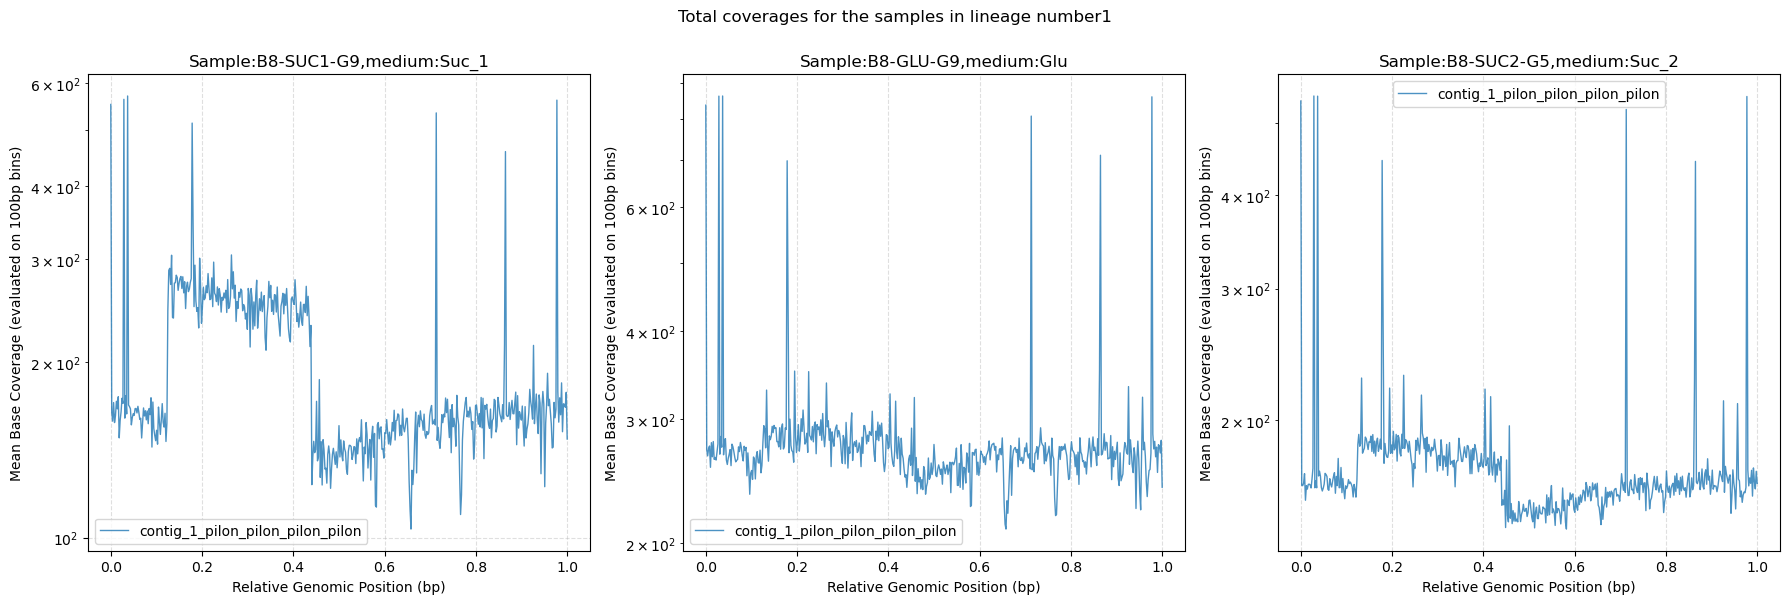

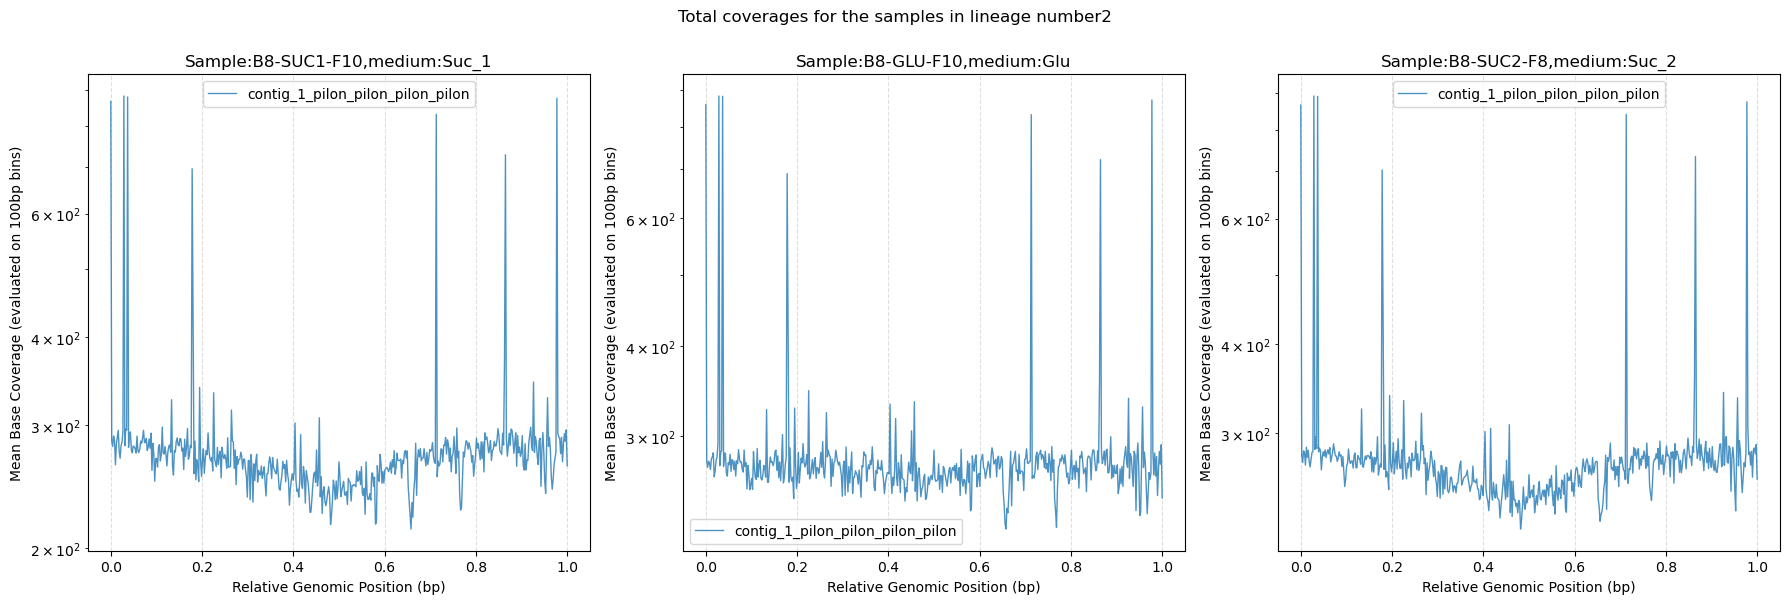

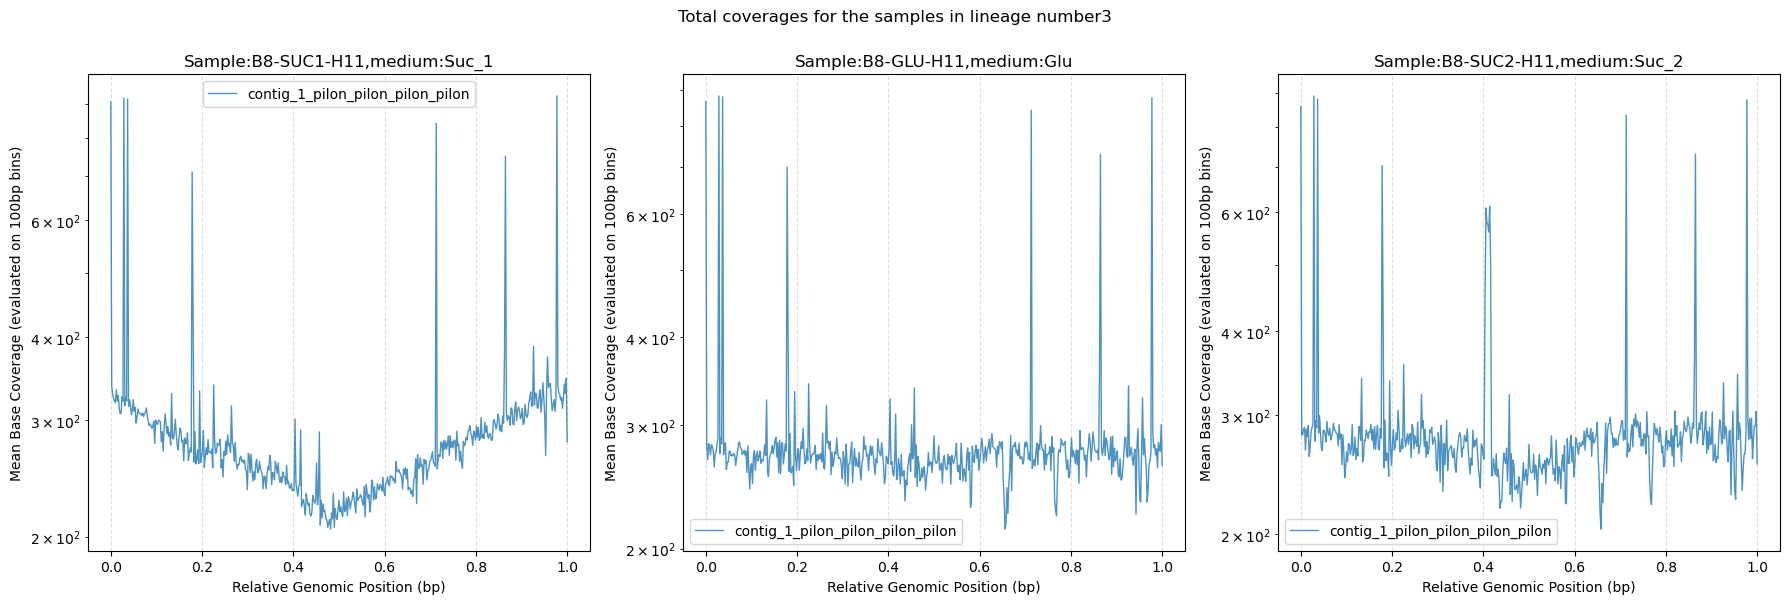

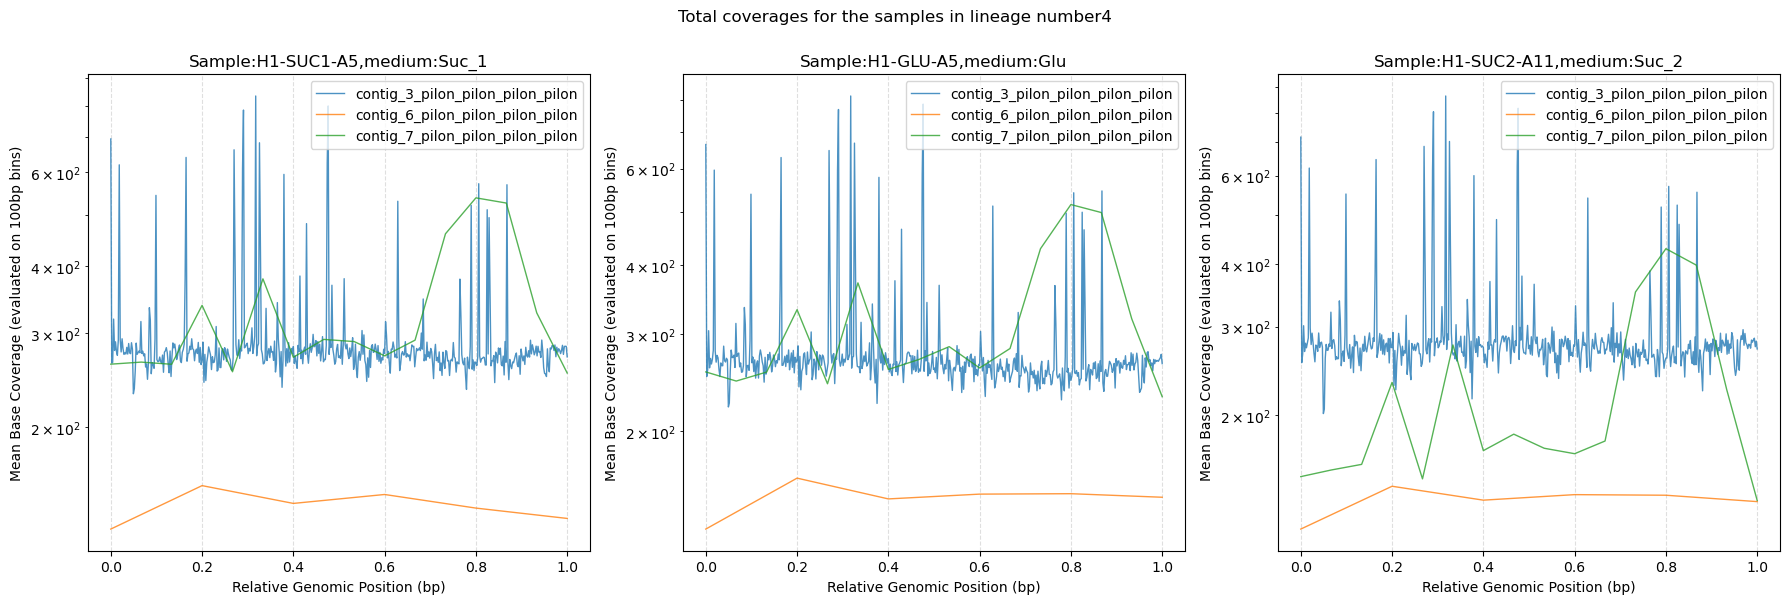

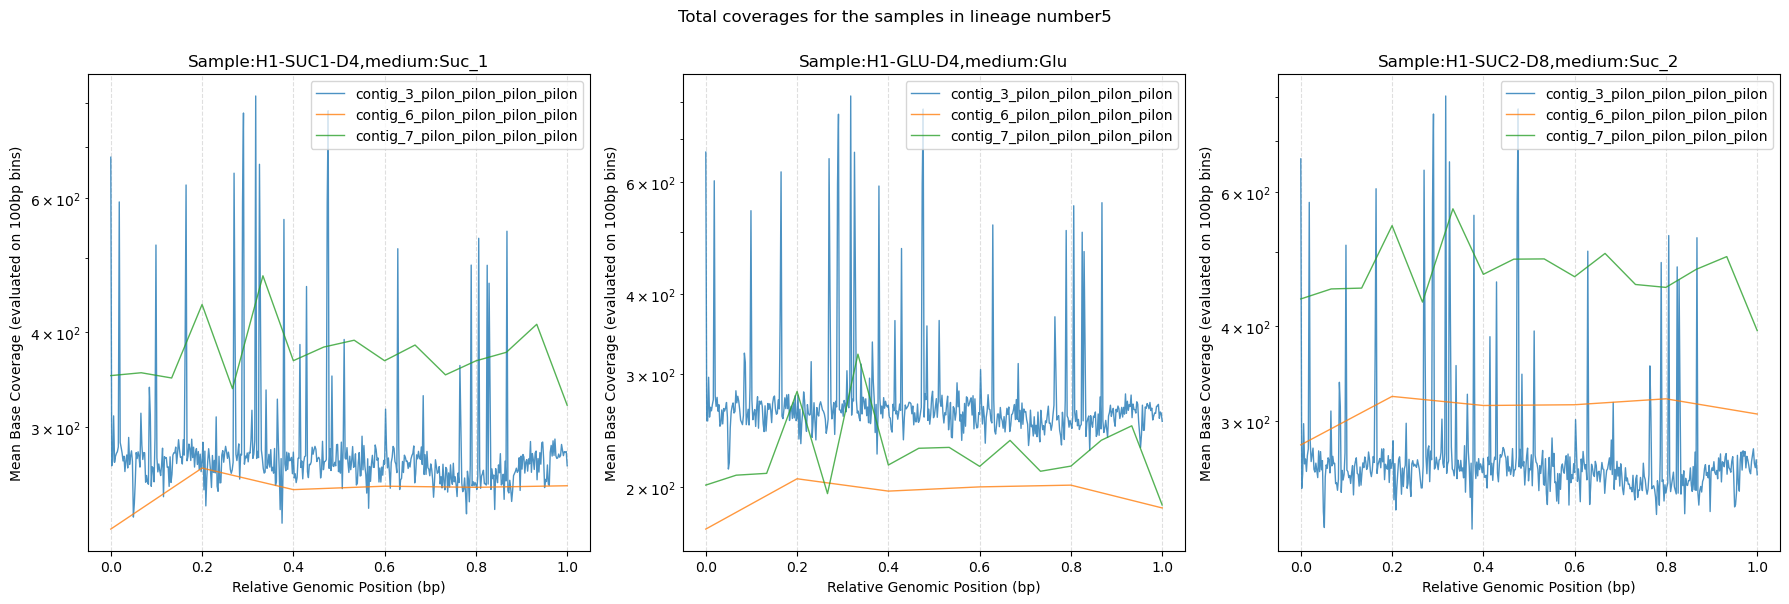

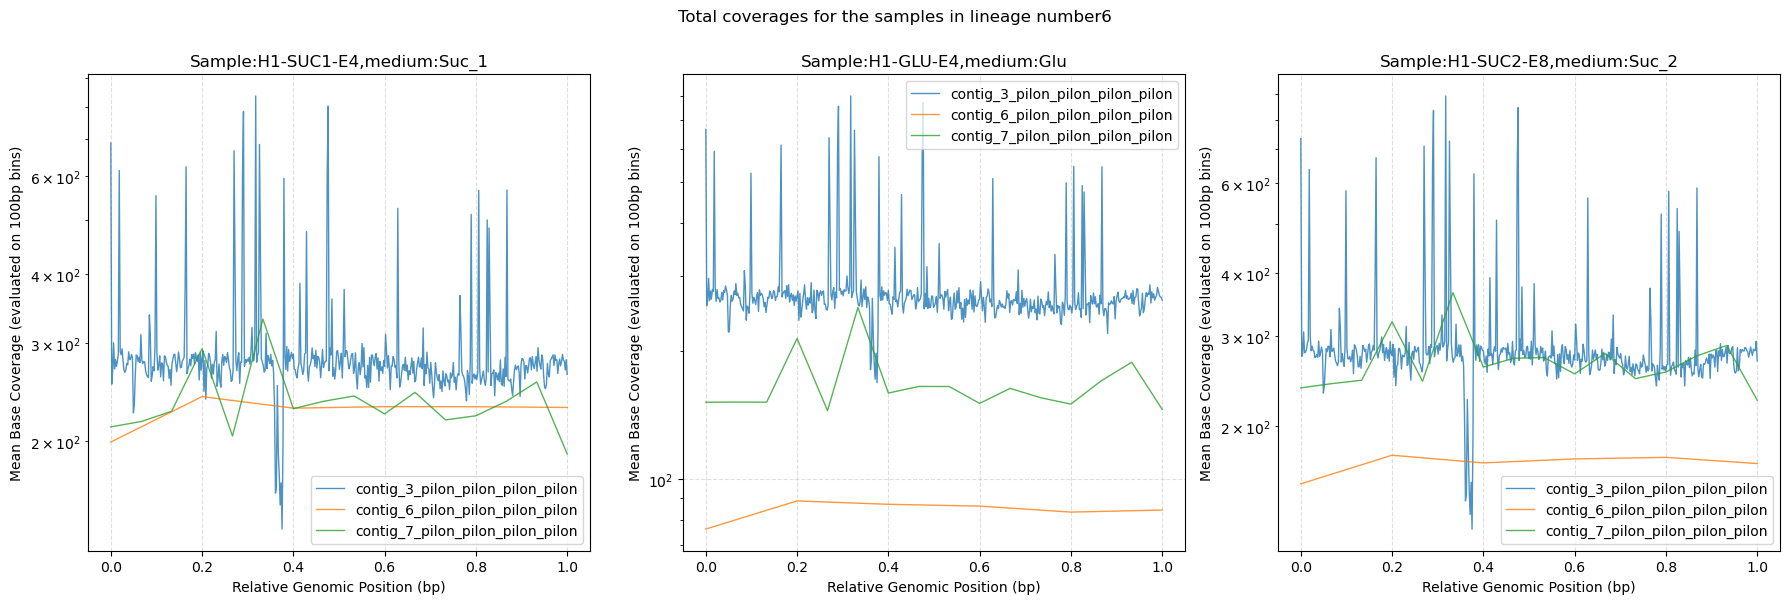

In [5]:
#PLOT THE COVERAGE PLOTS FOR 100-BASES-LONG BINS FOR EACH SAMPLE (NO SEPARATION BETWEEN CONTIGS)
bin_size = 10000
for i in dict_lineages.keys():

    working_df = dict_lineages[i]
    fig, axes = plt.subplots(nrows=1, ncols=len(working_df), figsize=(6 * len(working_df), 6), squeeze=False)
    
    for idx, sample in enumerate(working_df['Sample_name']):

        ax = axes[0][idx]

        ref_file = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/'+ sample + '-breseq/data/coverage.csv'
        cov_file = pd.read_csv(ref_file, sep = '\t', names = ['Contig', 'Position', 'Coverage'])

        for contig, data in cov_file.groupby(by='Contig'):
            data['Bin'] = (data['Position'] // bin_size) * bin_size
            data['Relative_bin'] = data['Bin']/max(data['Bin'])
            bin_coverage = data.groupby('Relative_bin')['Coverage'].mean().reset_index()
    
            ax.plot(bin_coverage['Relative_bin'],bin_coverage['Coverage'], label = contig, linewidth = 1, alpha = 0.8)

        ax.set_title('Sample:'+sample+',medium:'+working_df.iloc[idx]['Media_growth_round'])
        ax.set_xlabel('Relative Genomic Position (bp)', fontsize=10)
        ax.set_ylabel('Mean Base Coverage (evaluated on 100bp bins)', fontsize=10)
        ax.set_yscale('log')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend()
    fig.suptitle('Total coverages for the samples in lineage number'+str(i), fontsize = 12, y=1)
    plt.tight_layout()
    plt.show()
    plt.close()
    
    
    

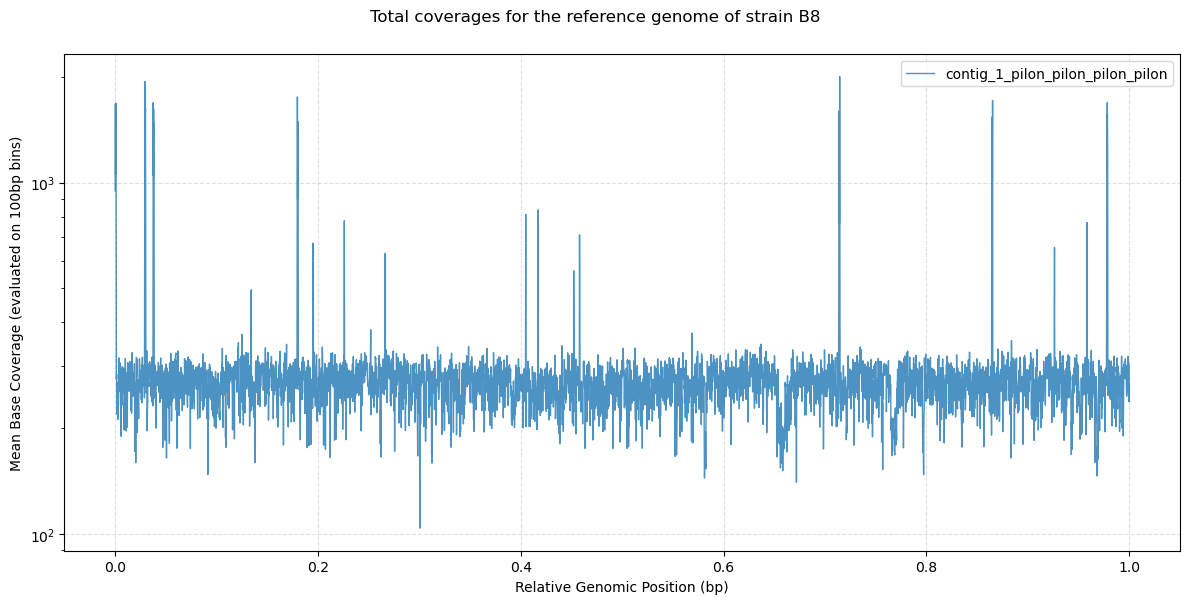

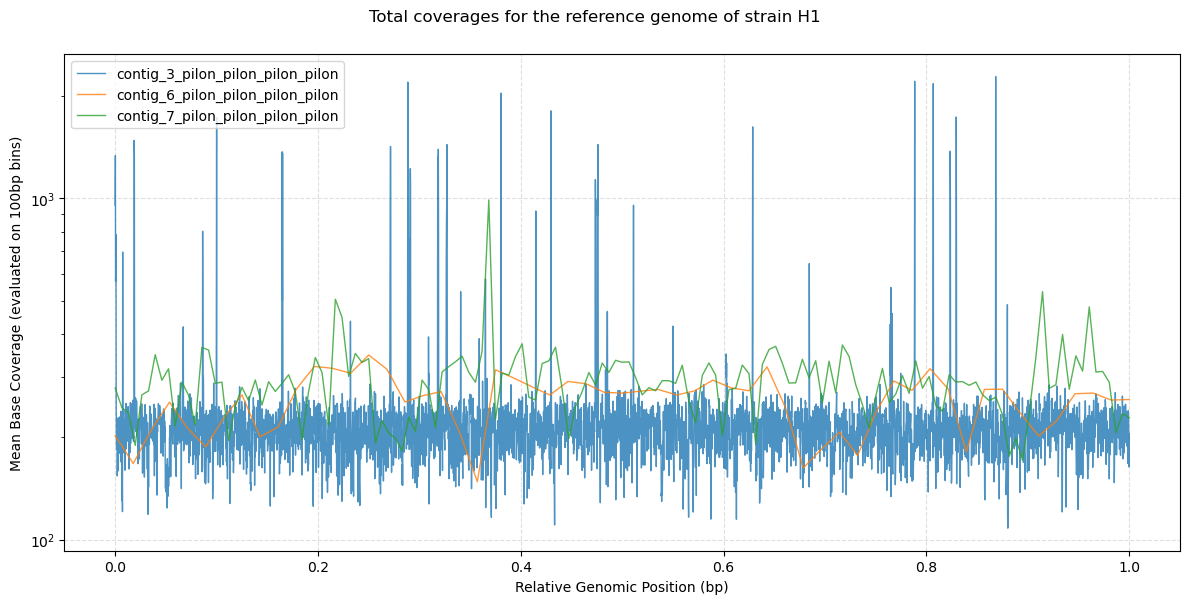

In [63]:
#PLOT THE COVERAGE PLOTS FOR 10000-BASES-LONG BINS FOR EACH SAMPLE

bin_size = 1000
for i in dict_precultures.keys():
    
    fig, ax = plt.subplots(figsize=(12, 6))


    ref_file = dict_precultures[i]
    cov_file = pd.read_csv(ref_file, sep = '\t', names = ['Contig', 'Position', 'Coverage'])

    for contig, data in cov_file.groupby(by='Contig'):
        data['Bin'] = (data['Position'] // bin_size) * bin_size
        data['Relative_bin'] = data['Bin']/max(data['Bin'])
        
        bin_coverage = data.groupby('Relative_bin')['Coverage'].mean().reset_index()

        ax.plot(bin_coverage['Relative_bin'],bin_coverage['Coverage'], label = contig, linewidth = 1, alpha = 0.8)

    ax.set_xlabel('Relative Genomic Position (bp)', fontsize=10)
    ax.set_ylabel('Mean Base Coverage (evaluated on 100bp bins)', fontsize=10)
    ax.set_yscale('log')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend()
    fig.suptitle('Total coverages for the reference genome of strain '+str(i), fontsize = 12, y=1)
    plt.tight_layout()
    plt.show()
    plt.close()
    

B8-SUC1-G9 done!
B8-GLU-G9 done!
B8-SUC2-G5 done!
B8-SUC1-F10 done!
B8-GLU-F10 done!
B8-SUC2-F8 done!
B8-SUC1-H11 done!


/scratch/cappel0001/slurm-job.21090640/ipykernel_2140292/3516586220.py:17: DtypeWarning: Columns (2,5,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63) have mixed types. Specify dtype option on import or set low_memory=False.
  mutation_data = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names, comment = '#')


B8-GLU-H11 done!


/scratch/cappel0001/slurm-job.21090640/ipykernel_2140292/3516586220.py:17: DtypeWarning: Columns (2,5,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63) have mixed types. Specify dtype option on import or set low_memory=False.
  mutation_data = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names, comment = '#')


B8-SUC2-H11 done!
H1-SUC1-A5 done!
H1-GLU-A5 done!
H1-SUC2-A11 done!
H1-SUC1-D4 done!
H1-GLU-D4 done!
H1-SUC2-D8 done!
H1-SUC1-E4 done!
H1-GLU-E4 done!
H1-SUC2-E8 done!


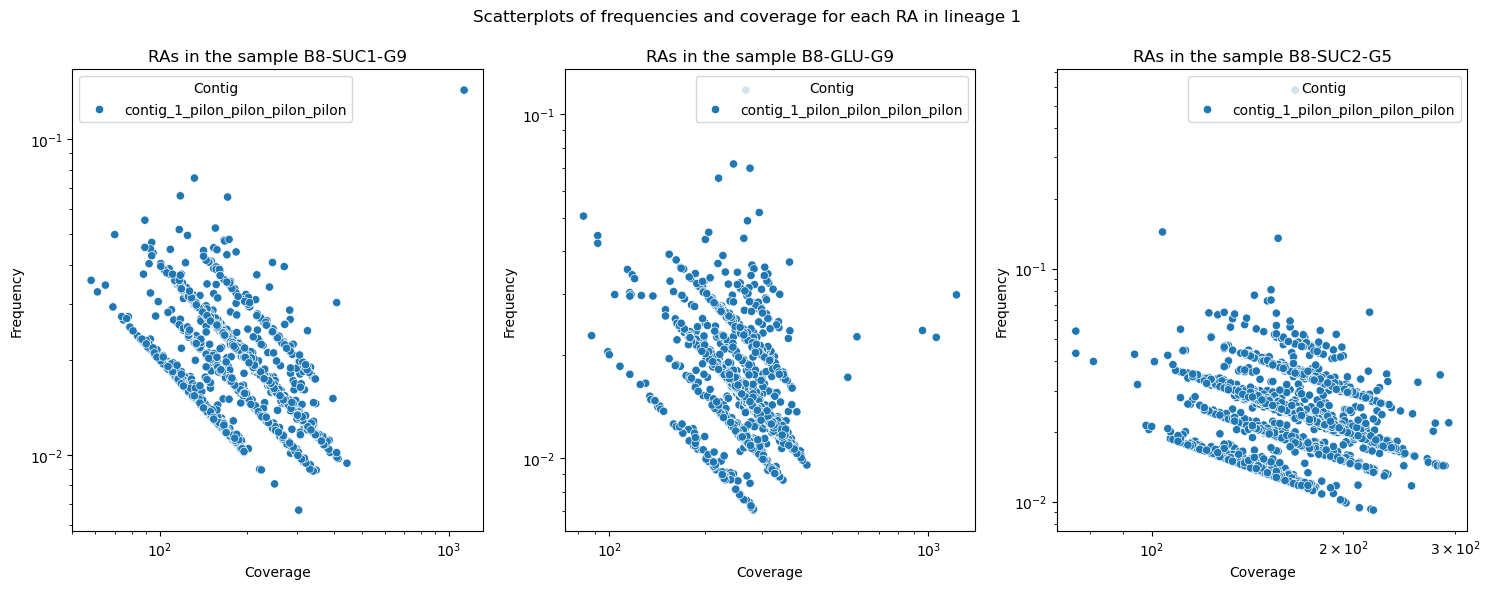

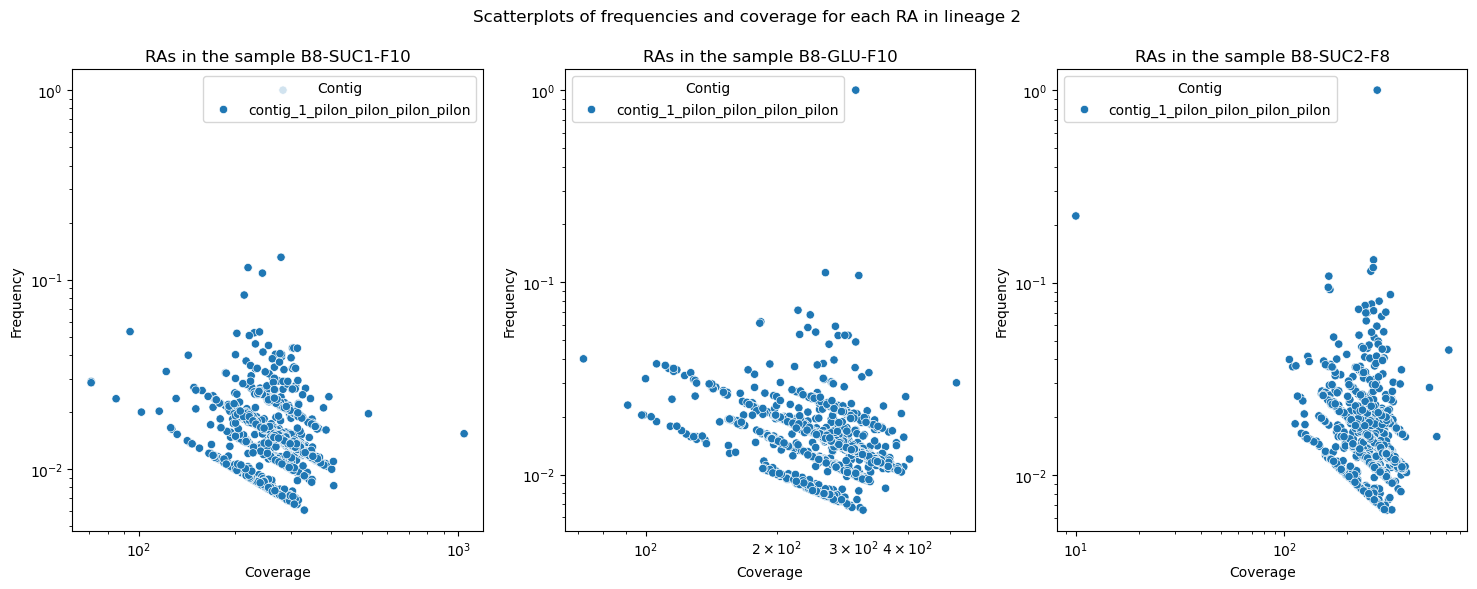

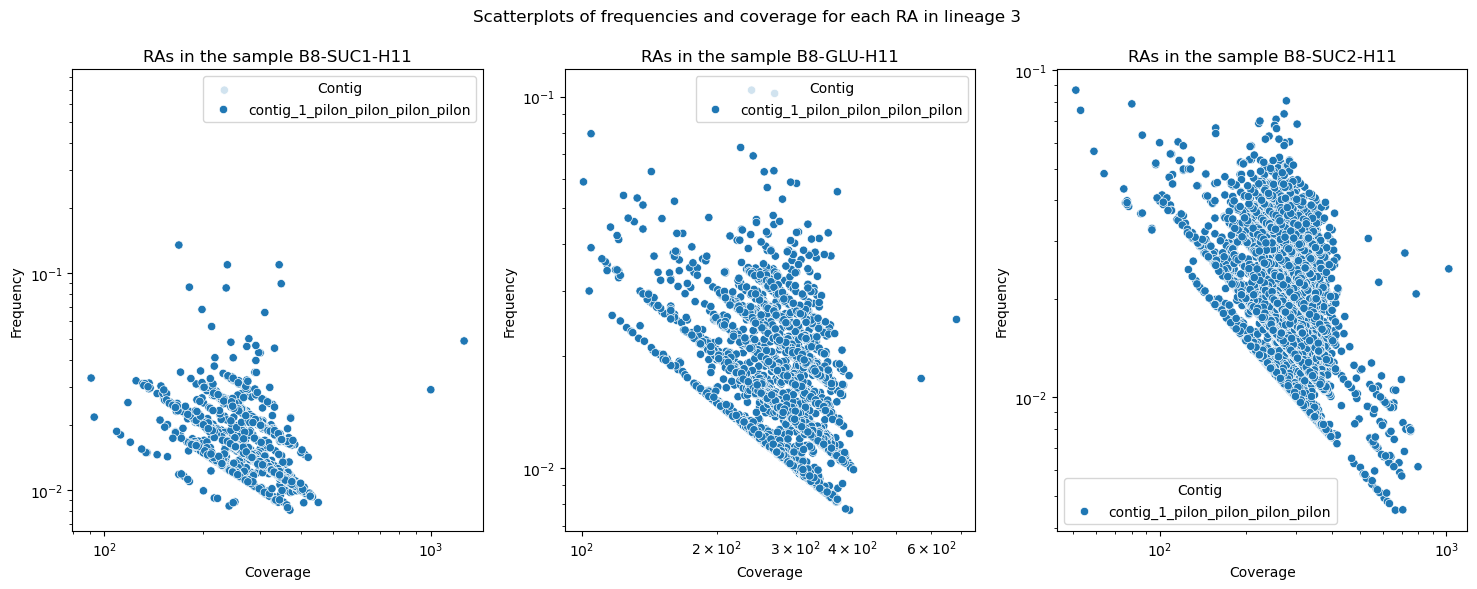

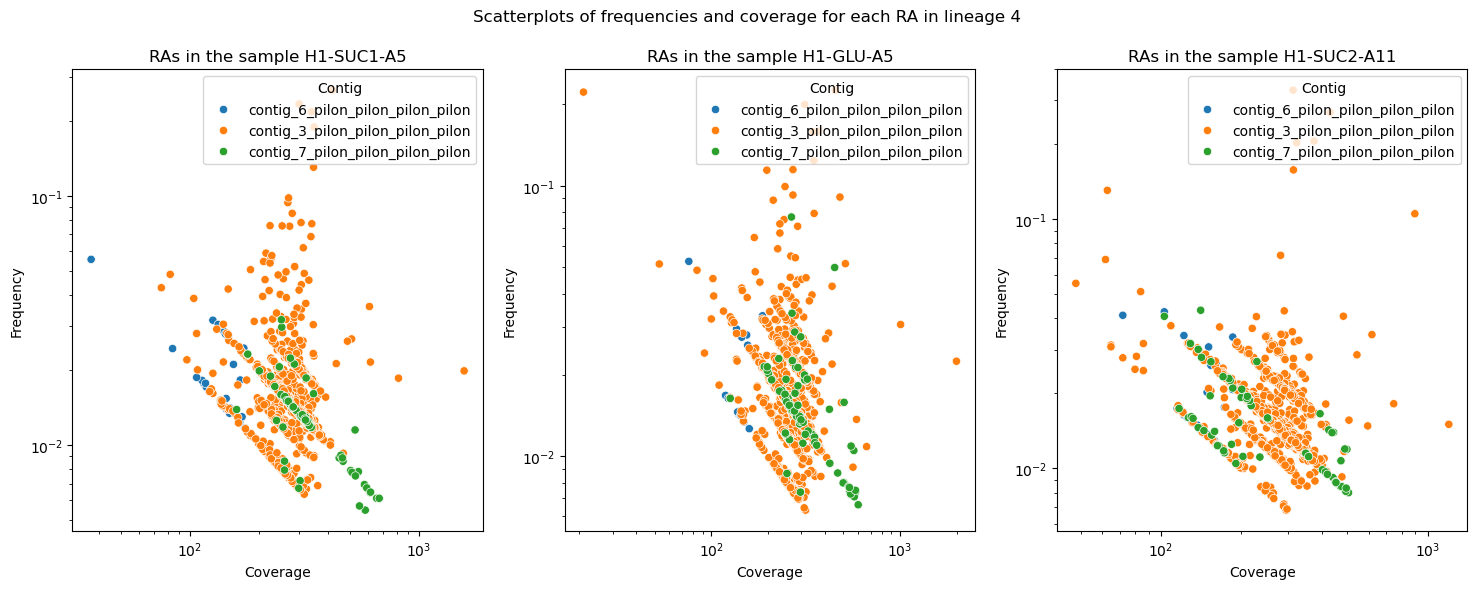

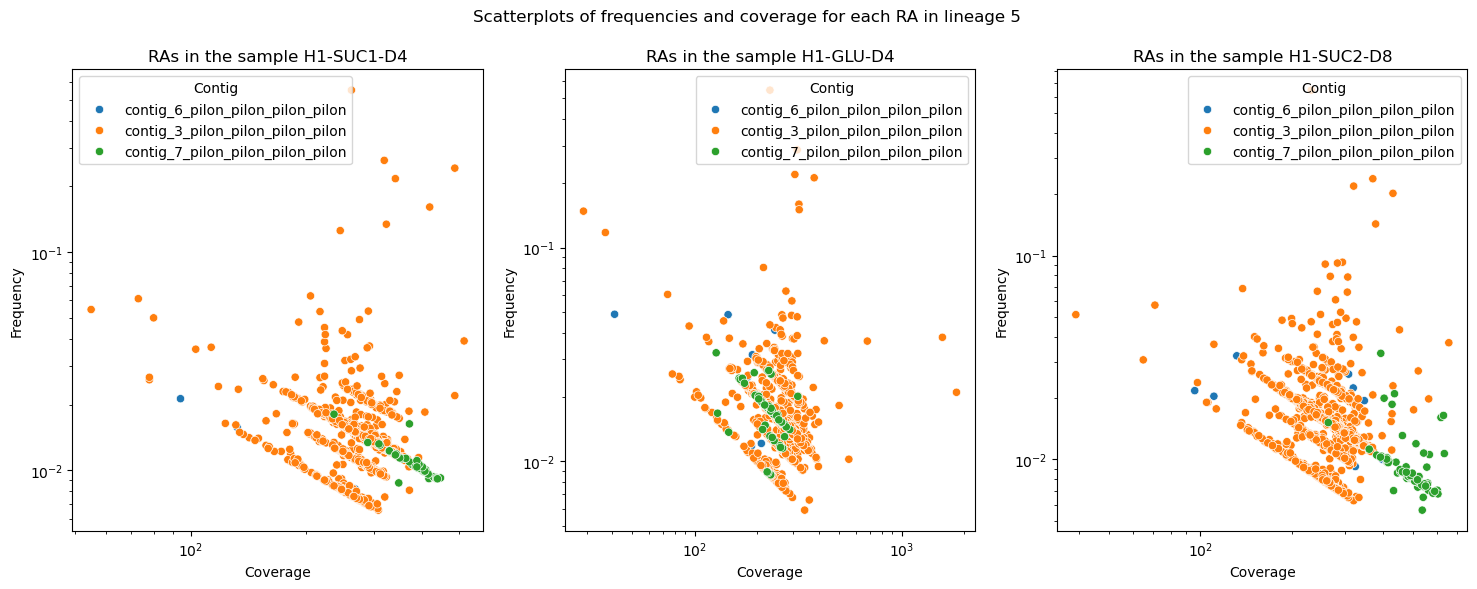

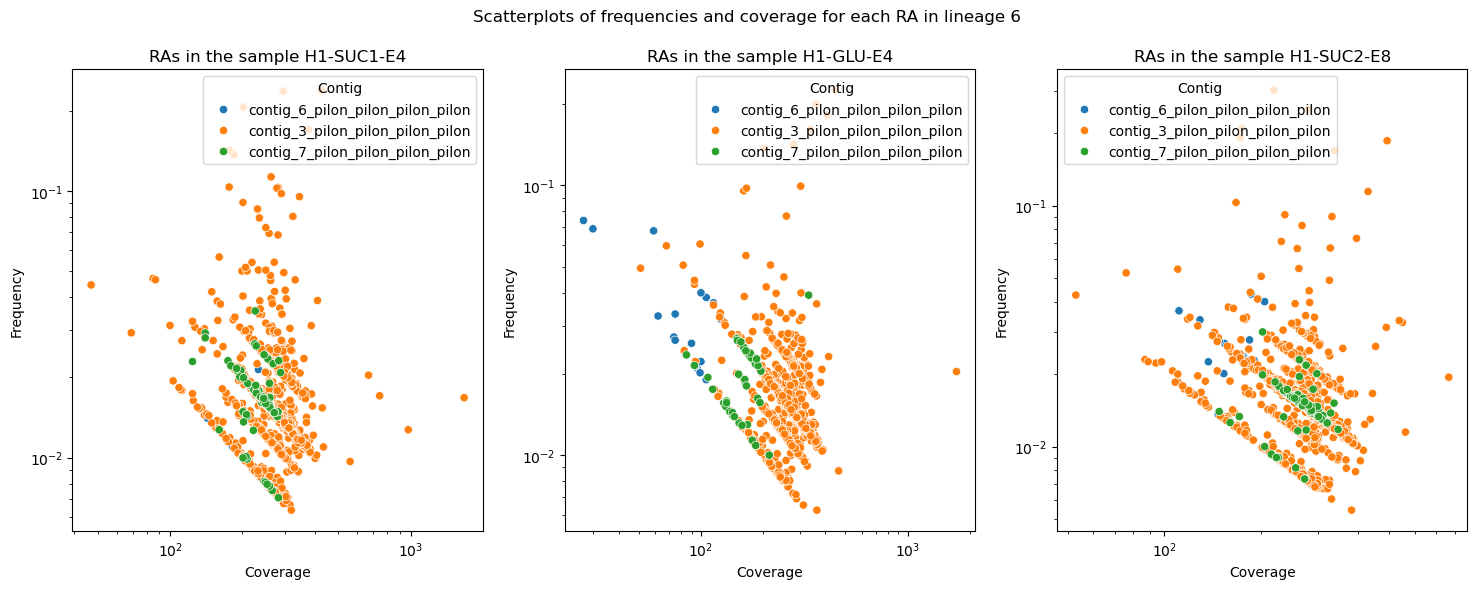

In [13]:
#plotting, for each sample, a scatterplot with on the x axis the absolute read coverage whereas on the y-axis the frequency.
#High coverage + high frequency -> real persistent, influential mutation
#READ ALIGNMENTS
max_expected_columns = 70
column_names = [f"col_{i}" for i in range(max_expected_columns)]

for i in dict_lineages.keys():

    working_df = dict_lineages[i]
    fig, axes = plt.subplots(nrows=1, ncols=len(working_df), figsize=(6 * len(working_df), 6), squeeze=False)
    
    for idx, sample in enumerate(working_df['Sample_name']):
        ax = axes[0,idx]
        cov_file = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/'+ sample + '-breseq/data/coverage.csv'
        cov_csv = pd.read_csv(cov_file, sep = '\t', names = ['Contig', 'Position', 'Coverage'])
        cov_csv.sort_values(by='Contig', ascending=True)
        mutation_data = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names, comment = '#')
        mutation_data = mutation_data[(mutation_data['col_0']=='RA')]
        only_frequencies_mask = mutation_data.astype(str).apply(lambda row: row.str.startswith('frequency='))
        only_frequencies_df = mutation_data[only_frequencies_mask]
        
        frequencies_mutations = only_frequencies_df.bfill(axis=1)['col_0'].str.strip('frequency=').astype(float)
        frequencies_indexed = pd.concat([mutation_data['col_3'], mutation_data['col_4'].astype(float), frequencies_mutations] , axis=1)
        frequencies_indexed.columns = ['Contig','Position', 'Frequency']
        position_mask = frequencies_indexed['Position']>4
        frequencies_indexed = frequencies_indexed [position_mask]
        useful_df = cov_csv.merge(frequencies_indexed, on=['Contig','Position'], how='inner')
        sns.scatterplot(data=useful_df, x='Coverage', y='Frequency', hue='Contig', ax=ax)
        print(sample+' done!')
        ax.set_title('RAs in the sample '+sample)
        ax.set_xscale('log')
        ax.set_yscale('log')
    fig.suptitle('Scatterplots of frequencies and coverage for each RA in lineage '+str(i))

B8-SUC1-G9 done!
B8-GLU-G9 done!
B8-SUC2-G5 done!
B8-SUC1-F10 done!
B8-GLU-F10 done!
B8-SUC2-F8 done!
B8-SUC1-H11 done!


/scratch/cappel0001/slurm-job.21090640/ipykernel_2140292/1144264810.py:17: DtypeWarning: Columns (2,5,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63) have mixed types. Specify dtype option on import or set low_memory=False.
  mutation_data = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names, comment = '#')


B8-GLU-H11 done!


/scratch/cappel0001/slurm-job.21090640/ipykernel_2140292/1144264810.py:17: DtypeWarning: Columns (2,5,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63) have mixed types. Specify dtype option on import or set low_memory=False.
  mutation_data = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names, comment = '#')


B8-SUC2-H11 done!
H1-SUC1-A5 done!
H1-GLU-A5 done!
H1-SUC2-A11 done!
H1-SUC1-D4 done!
H1-GLU-D4 done!
H1-SUC2-D8 done!
H1-SUC1-E4 done!
H1-GLU-E4 done!
H1-SUC2-E8 done!


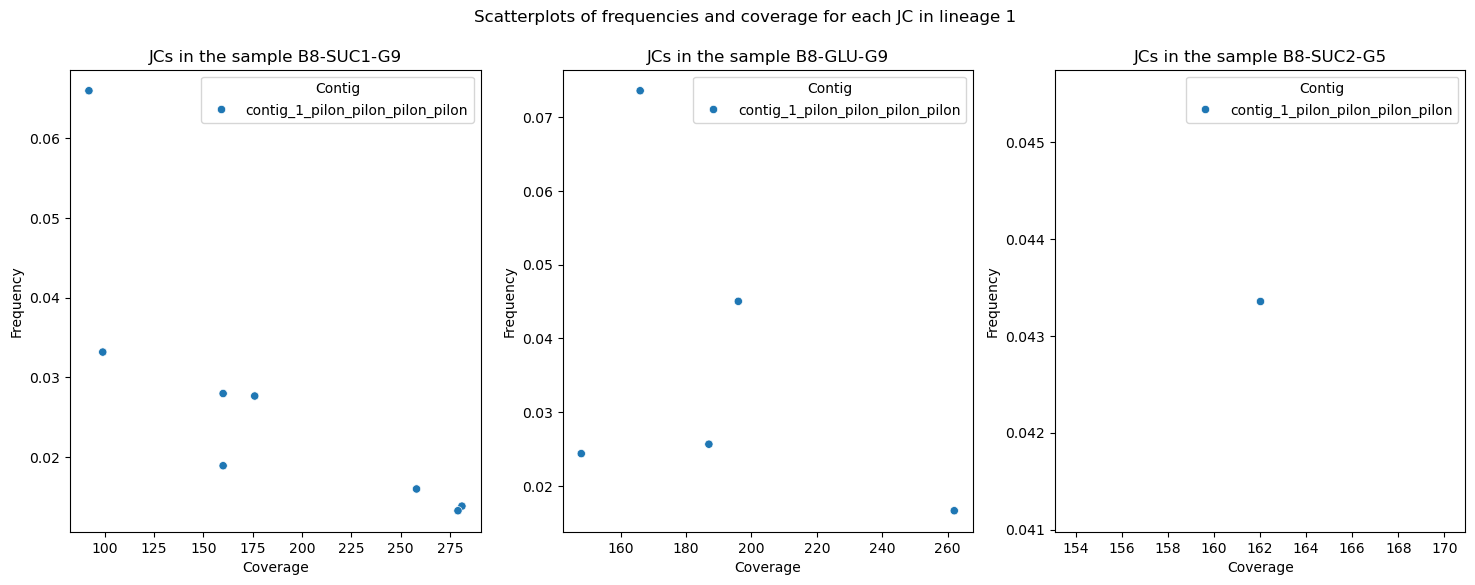

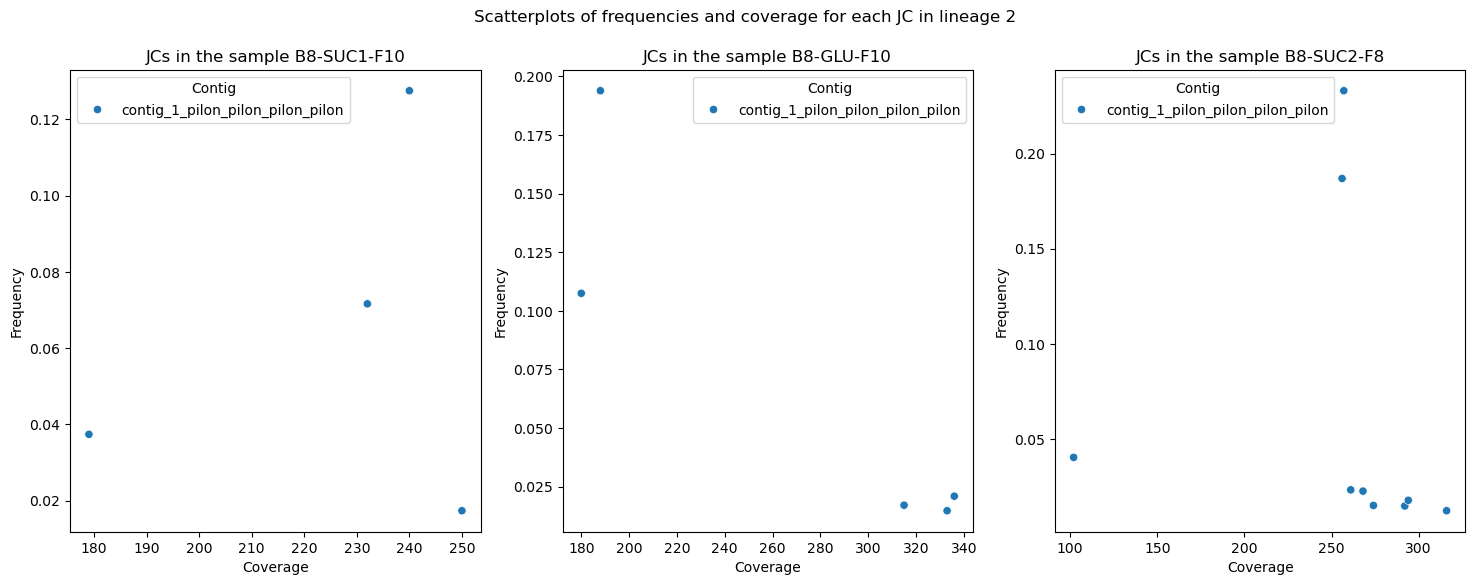

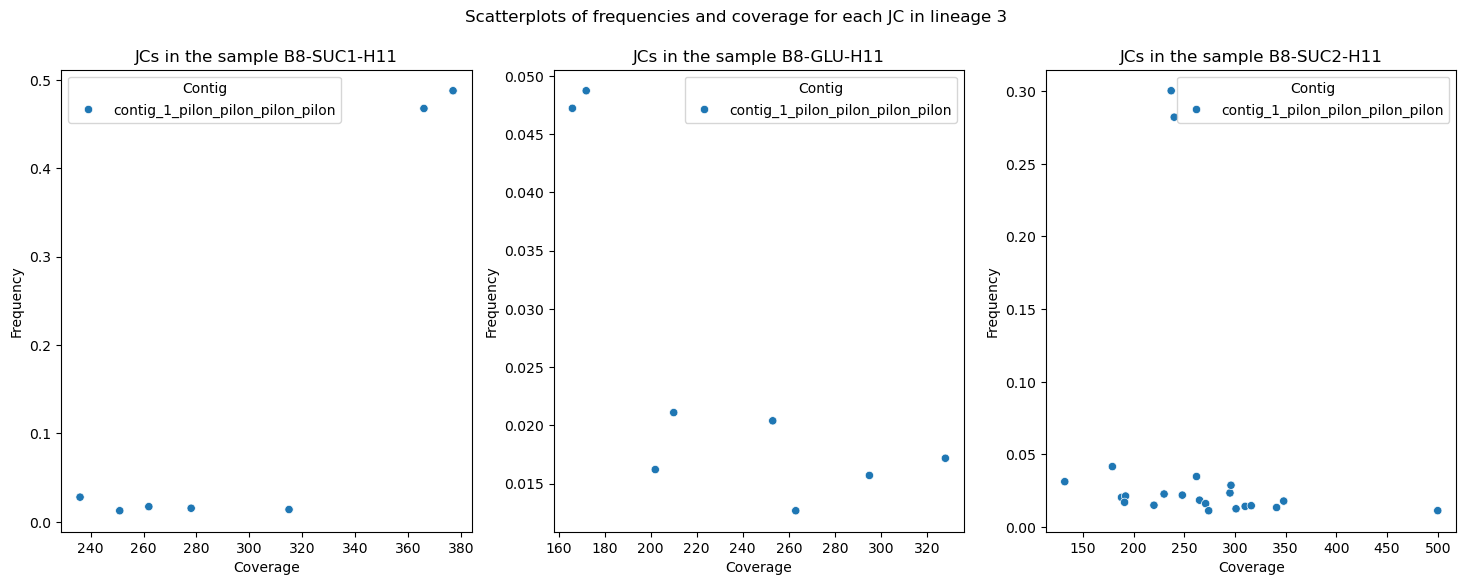

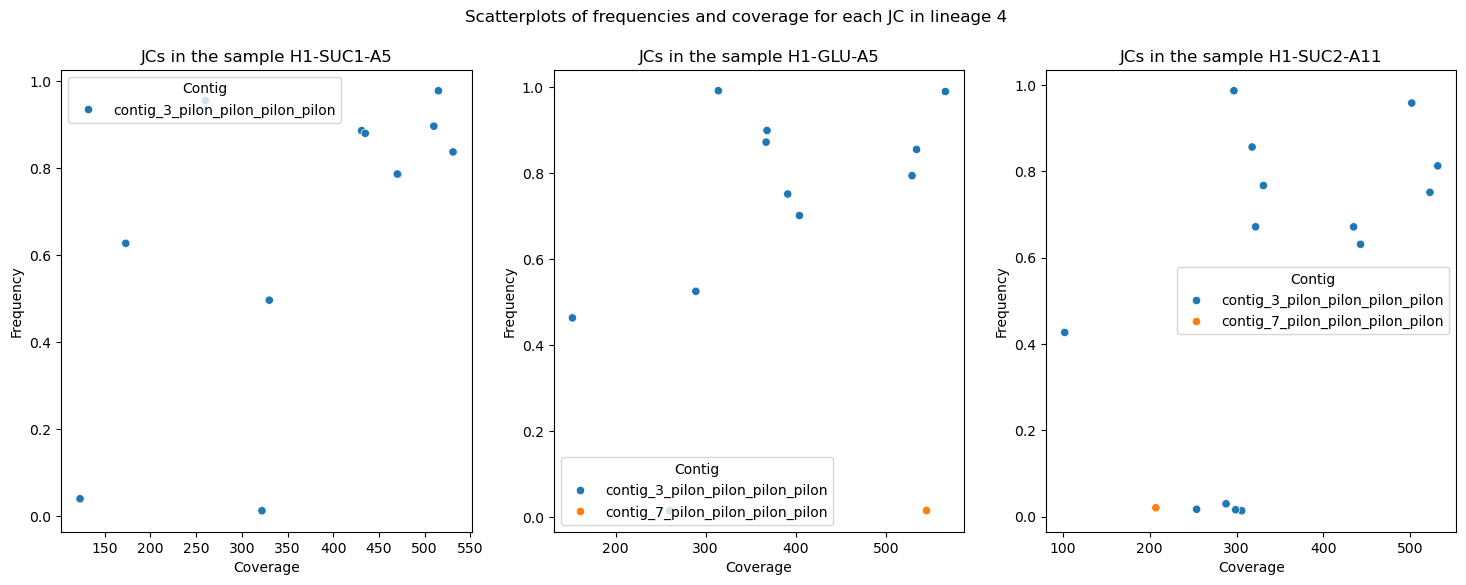

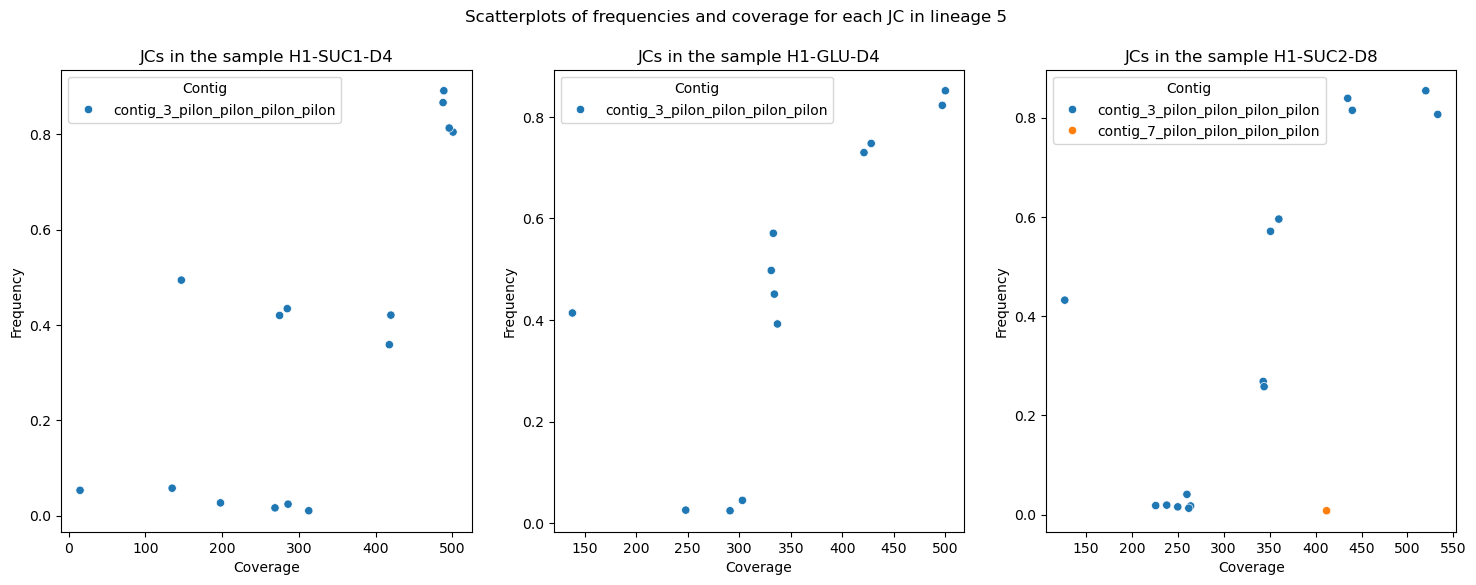

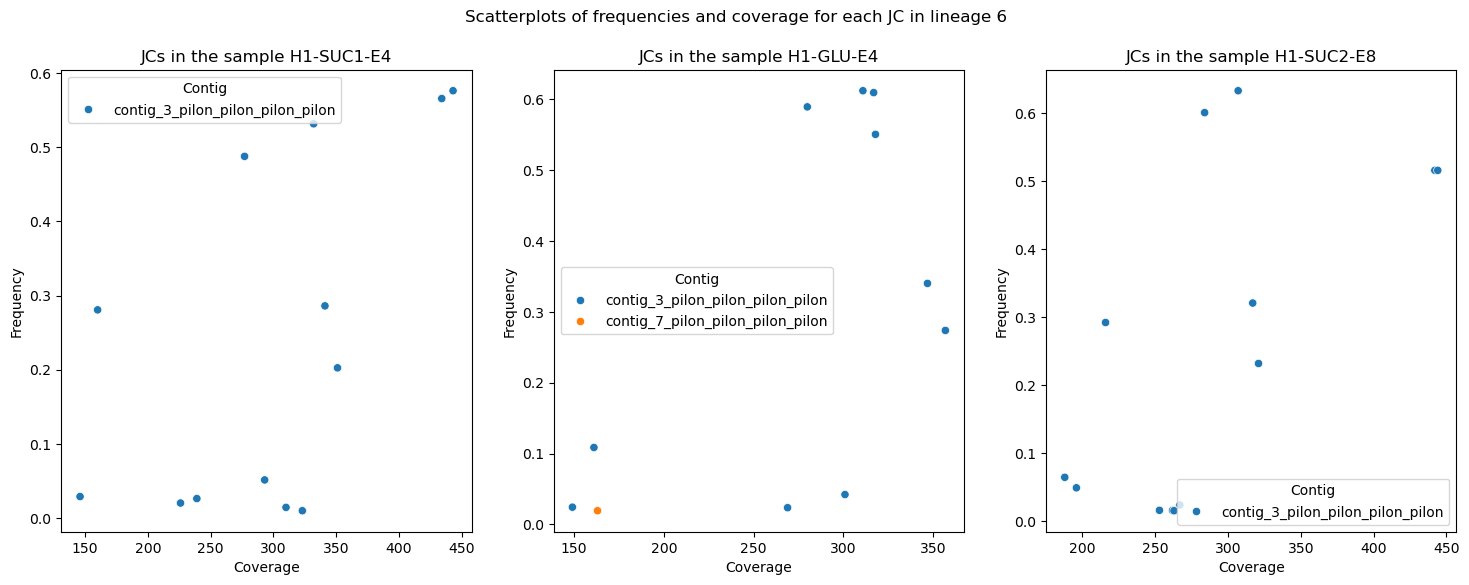

In [12]:
#plotting, for each sample, a scatterplot with on the x axis the absolute read coverage whereas on the y-axis the frequency.
#High coverage + high frequency -> real persistent, influential mutation
#NEW JUNCTIONS
max_expected_columns = 70
column_names = [f"col_{i}" for i in range(max_expected_columns)]

for i in dict_lineages.keys():

    working_df = dict_lineages[i]
    fig, axes = plt.subplots(nrows=1, ncols=len(working_df), figsize=(6 * len(working_df), 6), squeeze=False)
    
    for idx, sample in enumerate(working_df['Sample_name']):
        ax = axes[0,idx]
        cov_file = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/'+ sample + '-breseq/data/coverage.csv'
        cov_csv = pd.read_csv(cov_file, sep = '\t', names = ['Contig', 'Position', 'Coverage'])
        cov_csv.sort_values(by='Contig', ascending=True)
        mutation_data = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names, comment = '#')
        mutation_data = mutation_data[(mutation_data['col_0']=='JC')]
        only_frequencies_mask = mutation_data.astype(str).apply(lambda row: row.str.startswith('frequency='))
        only_frequencies_df = mutation_data[only_frequencies_mask]
        frequencies_mutations = only_frequencies_df.bfill(axis=1)['col_0'].str.strip('frequency=').astype(float)
        frequencies_indexed = pd.concat([mutation_data['col_3'], mutation_data['col_4'].astype(float), frequencies_mutations] , axis=1)
        frequencies_indexed.columns = ['Contig','Position', 'Frequency']
        position_mask = frequencies_indexed['Position']>4
        frequencies_indexed = frequencies_indexed [position_mask]
        useful_df = cov_csv.merge(frequencies_indexed, on=['Contig','Position'], how='inner')
        sns.scatterplot(data=useful_df, x='Coverage', y='Frequency', hue='Contig', ax=ax)
        print(sample+' done!')
        ax.set_title('JCs in the sample '+sample)

    fig.suptitle('Scatterplots of frequencies and coverage for each JC in lineage '+str(i))

B8-SUC1-G9 done!
B8-GLU-G9 done!
B8-SUC2-G5 done!
B8-SUC1-F10 done!
B8-GLU-F10 done!
B8-SUC2-F8 done!
B8-SUC1-H11 done!


/scratch/cappel0001/slurm-job.21090640/ipykernel_2140292/2041637871.py:17: DtypeWarning: Columns (2,5,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63) have mixed types. Specify dtype option on import or set low_memory=False.
  mutation_data = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names, comment = '#')


B8-GLU-H11 done!


/scratch/cappel0001/slurm-job.21090640/ipykernel_2140292/2041637871.py:17: DtypeWarning: Columns (2,5,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63) have mixed types. Specify dtype option on import or set low_memory=False.
  mutation_data = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names, comment = '#')


B8-SUC2-H11 done!
H1-SUC1-A5 done!
H1-GLU-A5 done!
H1-SUC2-A11 done!
H1-SUC1-D4 done!
H1-GLU-D4 done!
H1-SUC2-D8 done!
H1-SUC1-E4 done!
H1-GLU-E4 done!
H1-SUC2-E8 done!


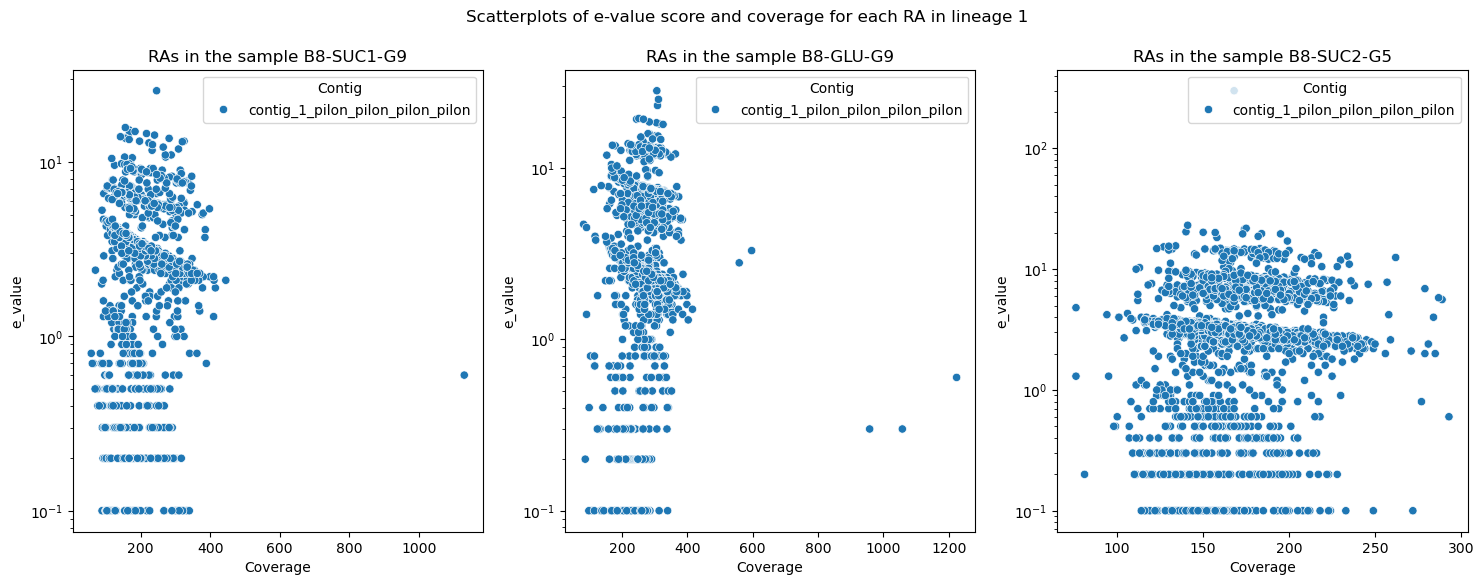

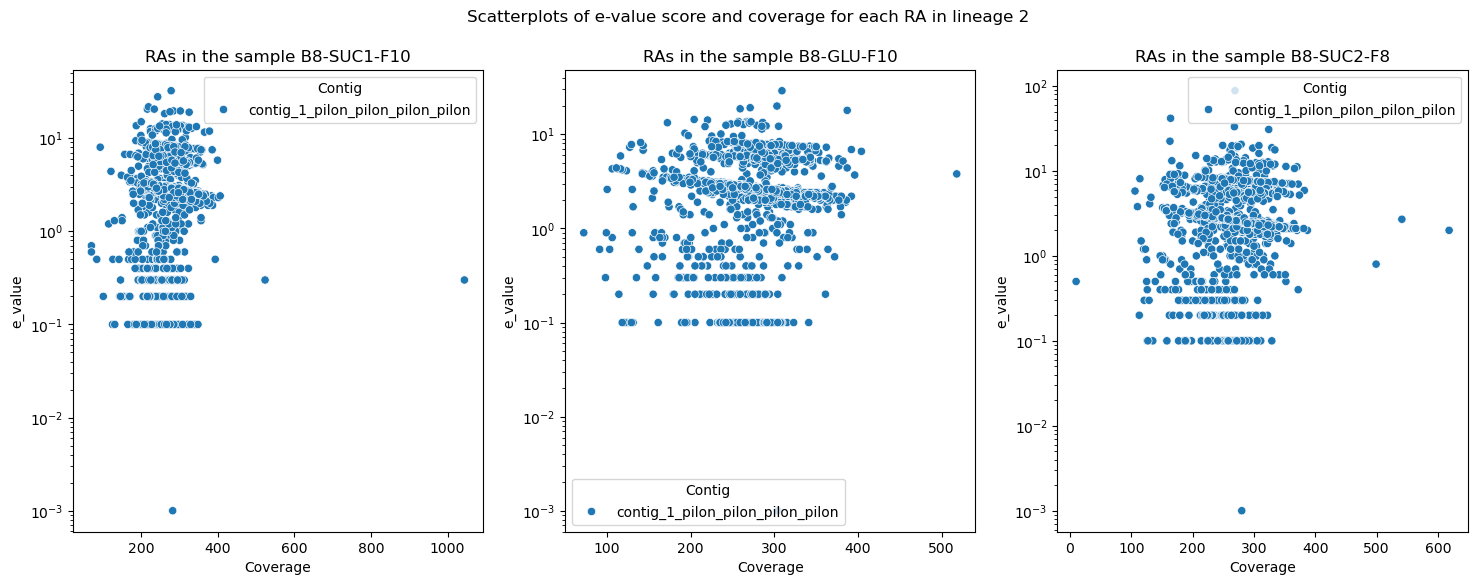

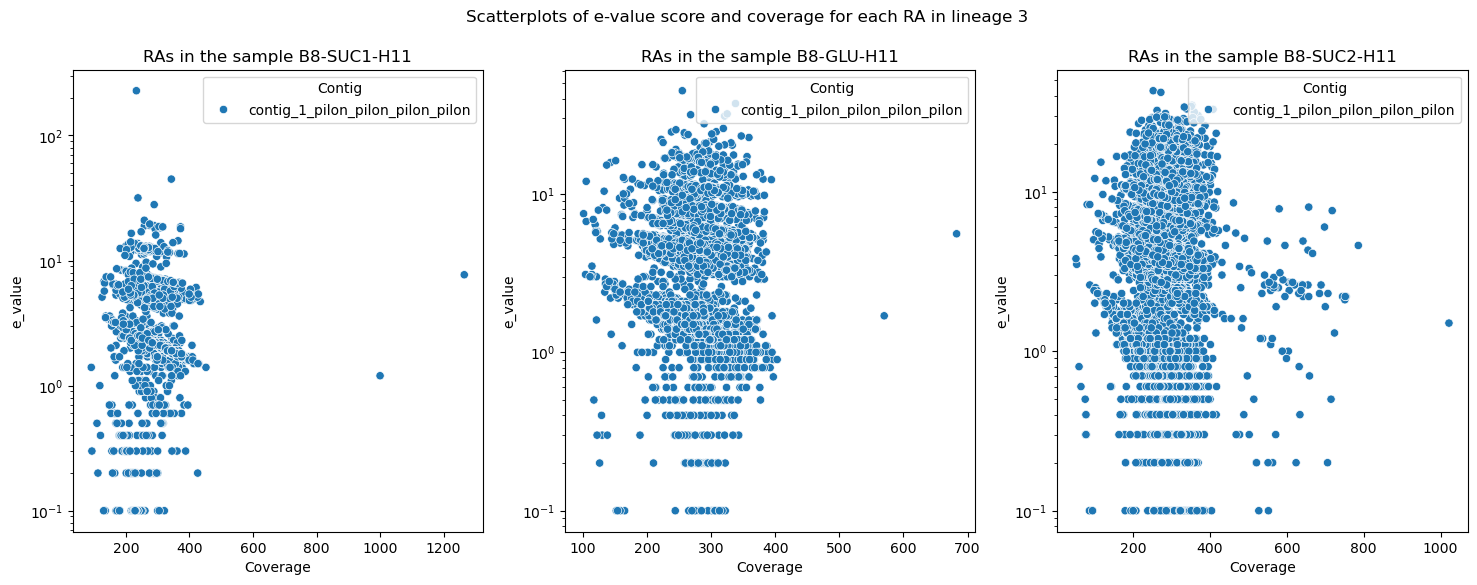

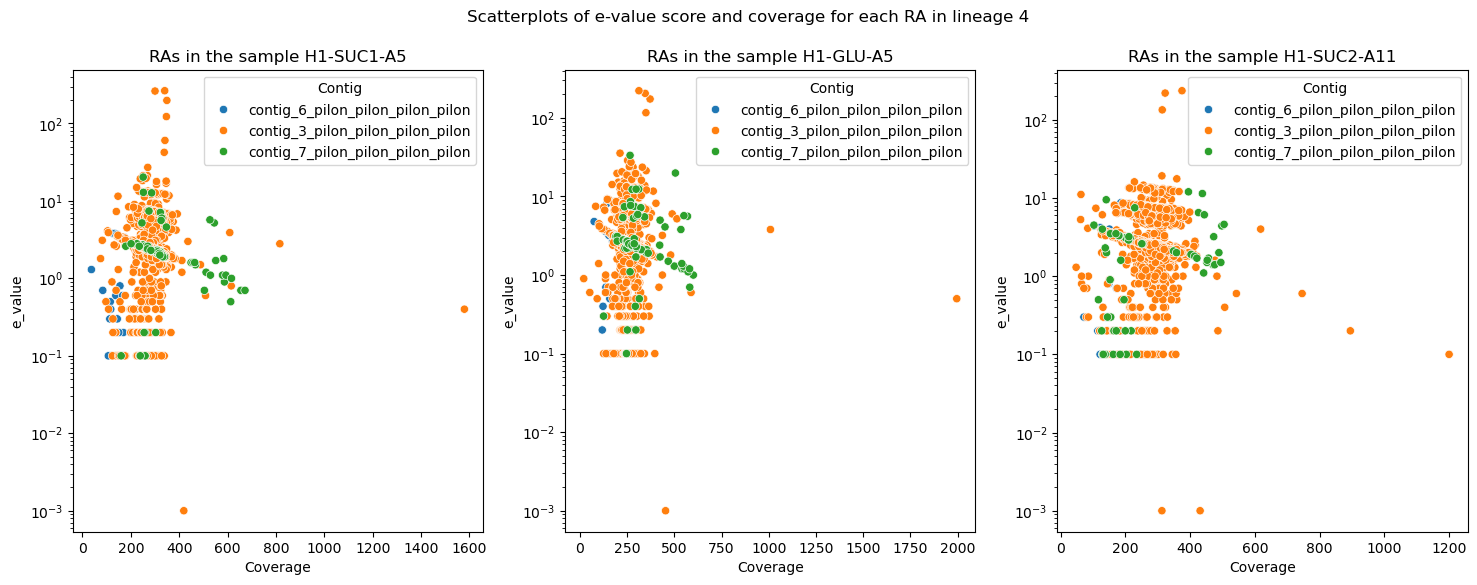

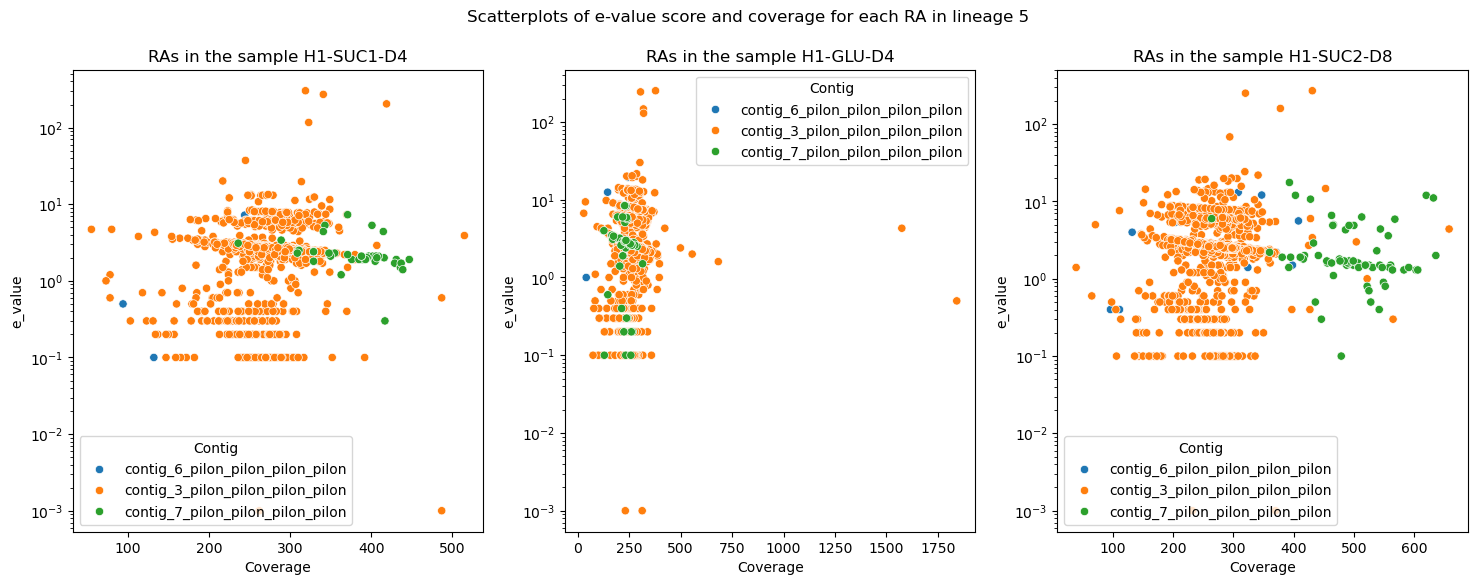

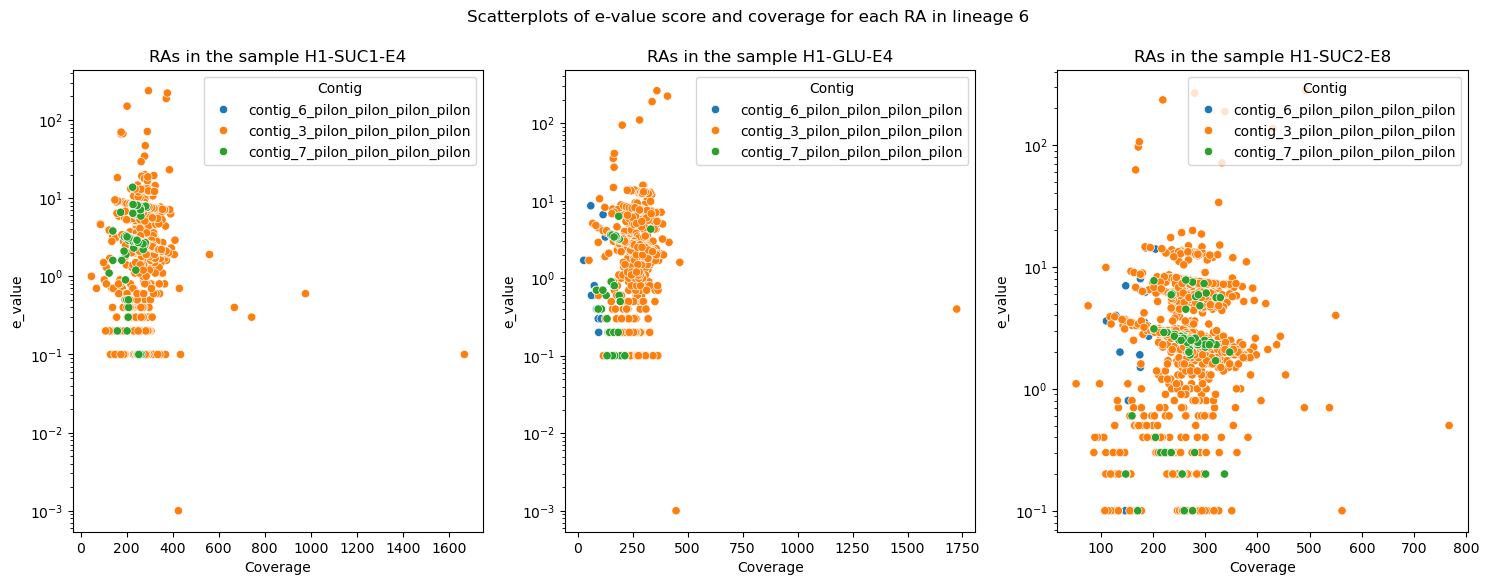

In [32]:
#plotting, for each sample, a scatterplot with on the x axis the absolute read coverage whereas on the y-axis the e-value.
#High coverage + high frequency -> real persistent, influential mutation
max_expected_columns = 70
column_names = [f"col_{i}" for i in range(max_expected_columns)]

for i in dict_lineages.keys():


    working_df = dict_lineages[i]
    fig, axes = plt.subplots(nrows=1, ncols=len(working_df), figsize=(6 * len(working_df), 6), squeeze=False)
    
    for idx, sample in enumerate(working_df['Sample_name']):
        ax = axes[0,idx]
        cov_file = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/'+ sample + '-breseq/data/coverage.csv'
        cov_csv = pd.read_csv(cov_file, sep = '\t', names = ['Contig', 'Position', 'Coverage'])
        cov_csv.sort_values(by='Contig', ascending=True)
        mutation_data = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names, comment = '#')
        mutation_data = mutation_data[(mutation_data['col_0']=='RA')]#only RAs have e-value
        only_e_values_mask = mutation_data.astype(str).apply(lambda row: row.str.startswith('polymorphism_score='))
        only_e_values_df = mutation_data[only_e_values_mask]
        if ~only_e_values_df.empty: #EMPTY PLOT ->NO MUTATIONS
            e_values_mutations = only_e_values_df.bfill(axis=1)['col_0'].astype(str).str.strip('polymorphism_score=').str.replace('NA','1e-3').str.replace('nf','1e-3').astype(float)
            e_values_indexed = pd.concat([mutation_data['col_3'], mutation_data['col_4'].astype(float), e_values_mutations] , axis=1)
            e_values_indexed.columns = ['Contig','Position', 'e_value']
            useful_df = cov_csv.merge(e_values_indexed, on=['Contig','Position'], how='inner')
            sns.scatterplot(data=useful_df, x='Coverage', y='e_value', hue='Contig', ax=ax)
        print(sample+' done!')
        ax.set_title('RAs in the sample '+sample)
        ax.set_yscale('log')
    fig.suptitle('Scatterplots of e-value score and coverage for each RA in lineage '+str(i))

B8-SUC1-G9 done!
B8-GLU-G9 done!
B8-SUC2-G5 done!


/scicore/soft/jupyterhub/envs/jupyterlab_4.3.4-notebook_7.3.2-forge/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


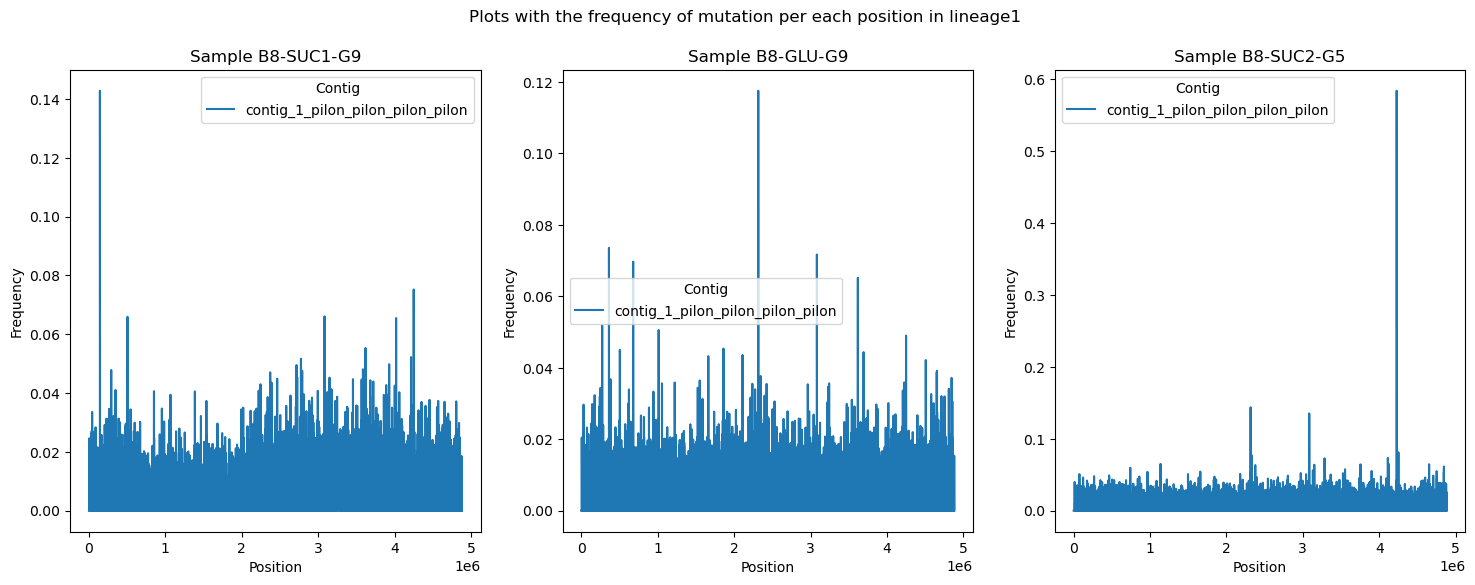

B8-SUC1-F10 done!
B8-GLU-F10 done!
B8-SUC2-F8 done!


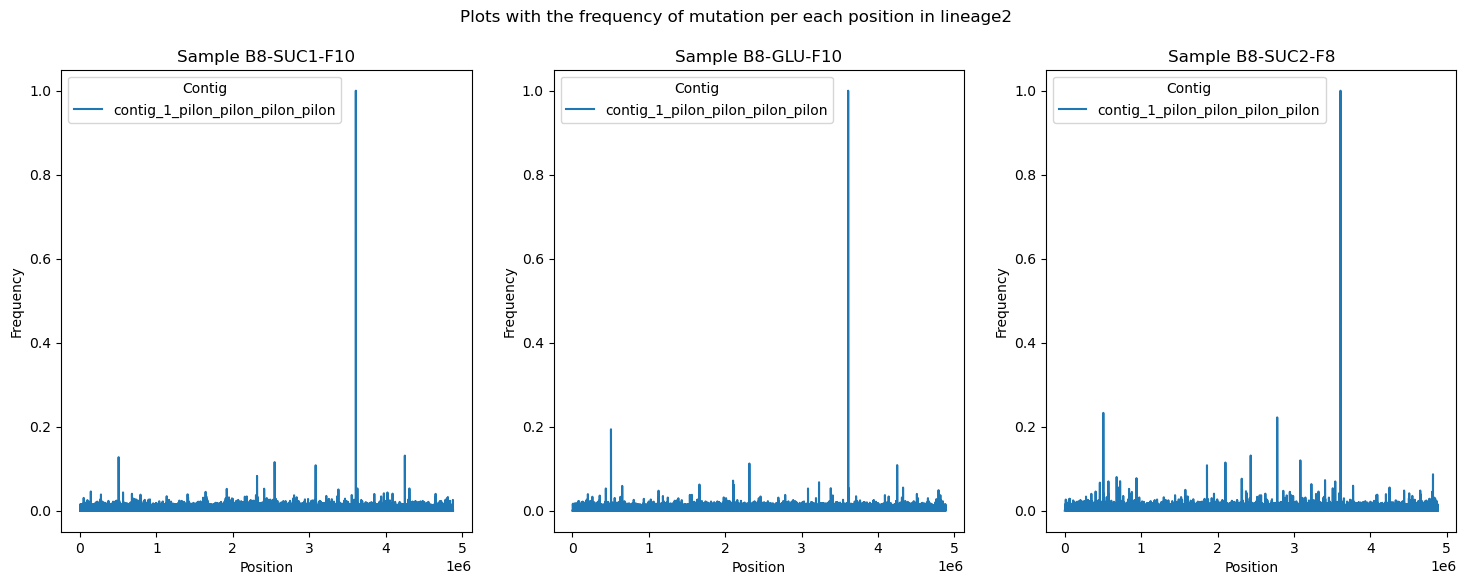

B8-SUC1-H11 done!


/scratch/cappel0001/slurm-job.21044080/ipykernel_765470/48404286.py:14: DtypeWarning: Columns (2,5,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63) have mixed types. Specify dtype option on import or set low_memory=False.
  mutation_data = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names, comment = '#')


B8-GLU-H11 done!


/scratch/cappel0001/slurm-job.21044080/ipykernel_765470/48404286.py:14: DtypeWarning: Columns (2,5,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63) have mixed types. Specify dtype option on import or set low_memory=False.
  mutation_data = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names, comment = '#')


B8-SUC2-H11 done!


/scicore/soft/jupyterhub/envs/jupyterlab_4.3.4-notebook_7.3.2-forge/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


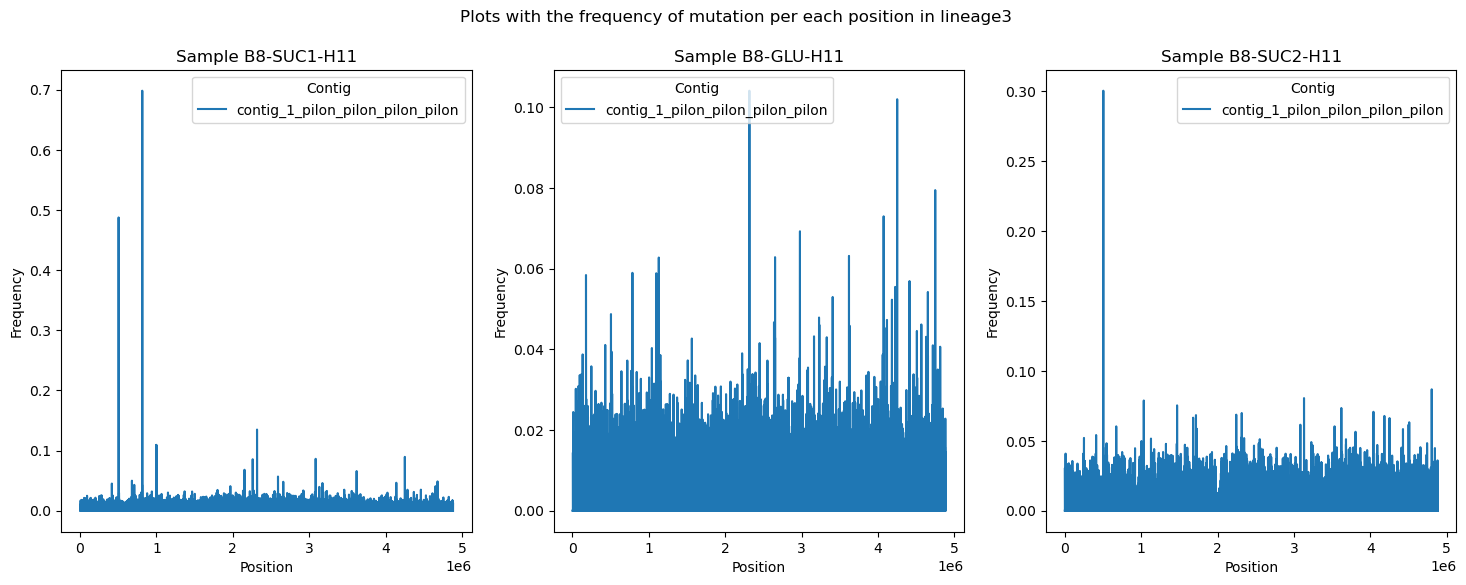

H1-SUC1-A5 done!
H1-GLU-A5 done!
H1-SUC2-A11 done!


/scicore/soft/jupyterhub/envs/jupyterlab_4.3.4-notebook_7.3.2-forge/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


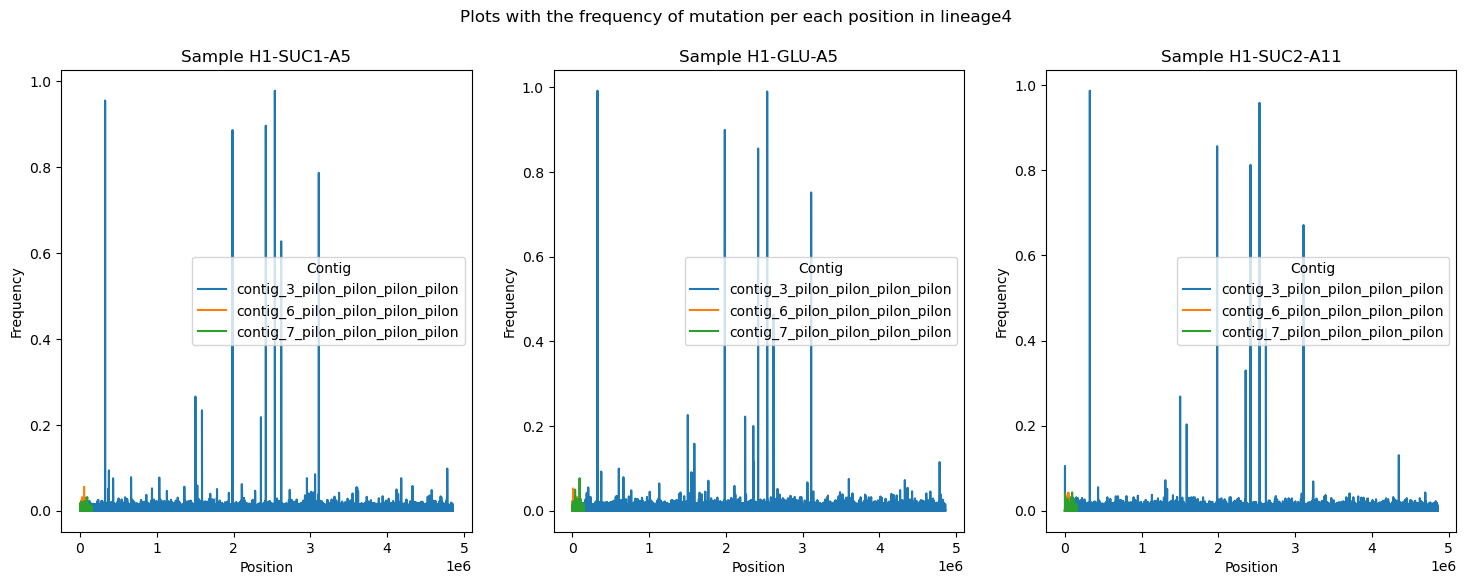

H1-SUC1-D4 done!
H1-GLU-D4 done!
H1-SUC2-D8 done!


/scicore/soft/jupyterhub/envs/jupyterlab_4.3.4-notebook_7.3.2-forge/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


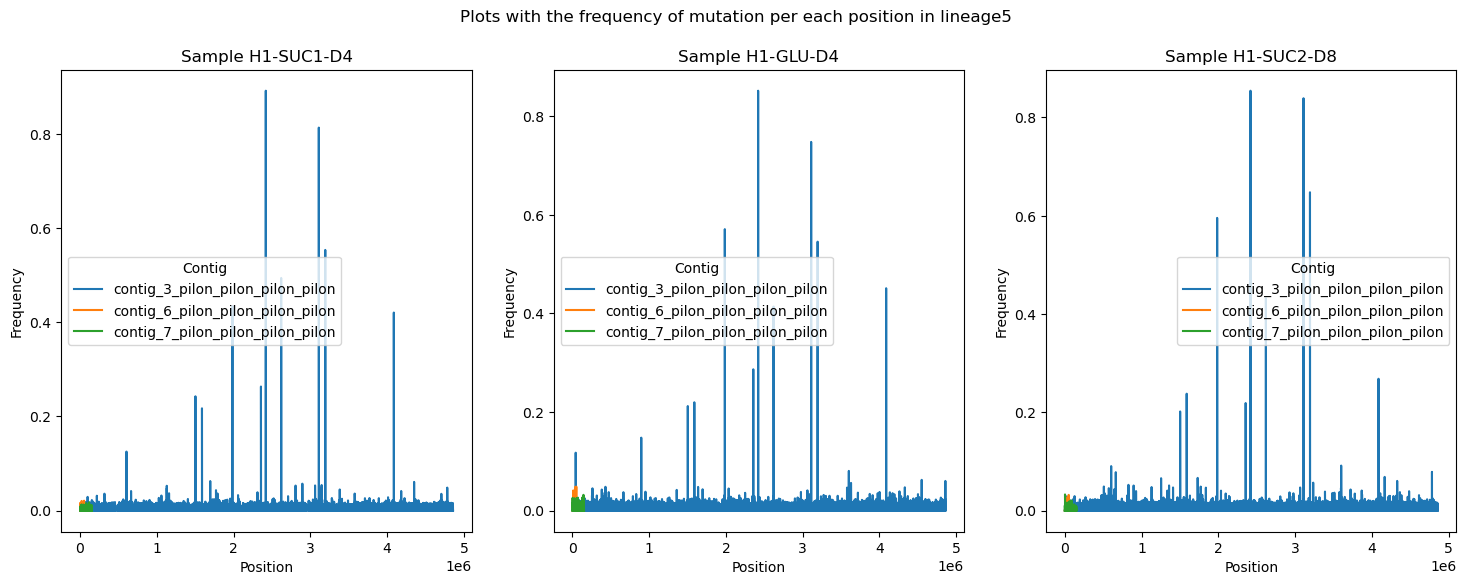

H1-SUC1-E4 done!
H1-GLU-E4 done!
H1-SUC2-E8 done!


/scicore/soft/jupyterhub/envs/jupyterlab_4.3.4-notebook_7.3.2-forge/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


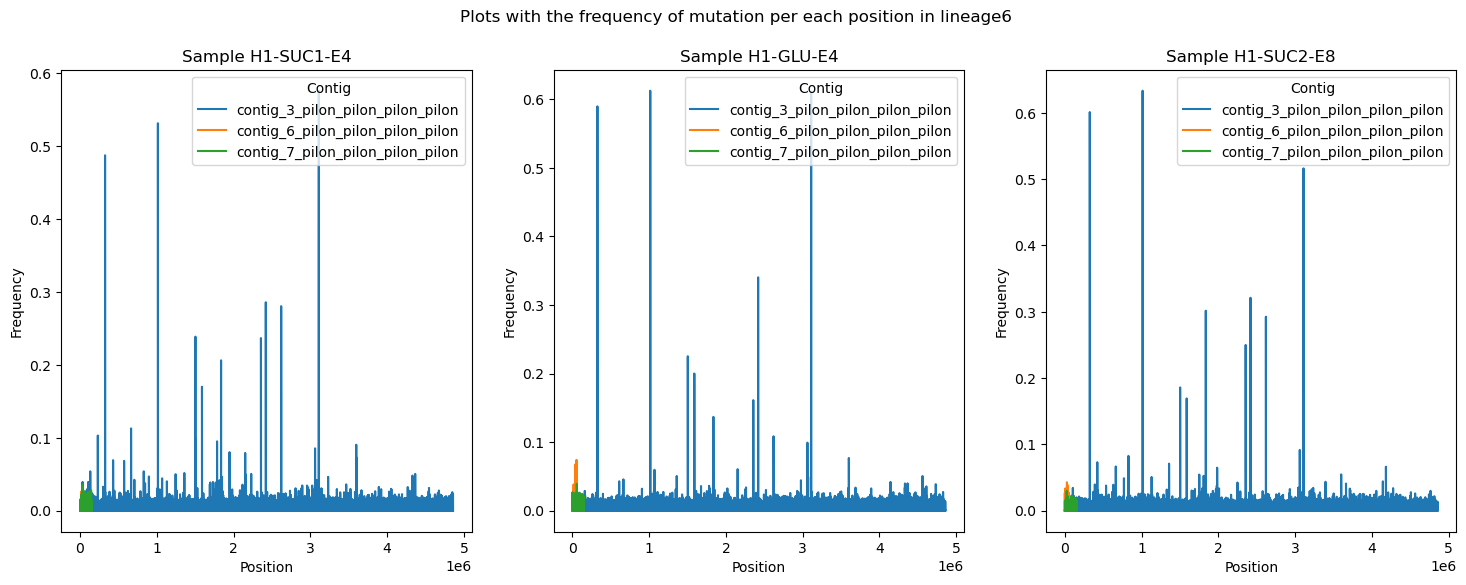

In [14]:
max_expected_columns = 70
column_names = [f"col_{i}" for i in range(max_expected_columns)]

for i in dict_lineages.keys():

    working_df = dict_lineages[i]
    fig, axes = plt.subplots(nrows=1, ncols=len(working_df), figsize=(6 * len(working_df), 6), squeeze=False)
    
    for idx, sample in enumerate(working_df['Sample_name']):
        ax = axes[0,idx]
        cov_file = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/'+ sample + '-breseq/data/coverage.csv'
        cov_csv = pd.read_csv(cov_file, sep = '\t', names = ['Contig', 'Position', 'Coverage'])
        cov_csv.sort_values(by='Contig', ascending=True)
        mutation_data = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names, comment = '#')
        mutation_data = mutation_data[mutation_data['col_0'].isin(['RA', 'JC'])]
        only_frequencies_mask = mutation_data.astype(str).apply(lambda row: row.str.startswith('frequency='))
        only_frequencies_df = mutation_data[only_frequencies_mask]
        frequencies_mutations = only_frequencies_df.bfill(axis=1)['col_0'].str.strip('frequency=').astype(float)
        frequencies_indexed = pd.concat([mutation_data['col_3'], mutation_data['col_4'].astype(float), frequencies_mutations] , axis=1)
        frequencies_indexed.columns = ['Contig','Position', 'Frequency']
        position_mask = frequencies_indexed['Position']>4
        frequencies_indexed = frequencies_indexed[position_mask]
        useful_df = cov_csv.merge(frequencies_indexed, on=['Contig','Position'], how='outer')
        sns.lineplot(data=useful_df.fillna(0), x='Position', y='Frequency', hue='Contig', ax=ax)
        print(sample+' done!')
        ax.set_title('Sample '+sample)
    fig.suptitle('Plots with the frequency of mutation per each position in lineage '+ str(i))
    plt.show()


B8-SUC1-G9 done!
B8-GLU-G9 done!
B8-SUC2-G5 done!


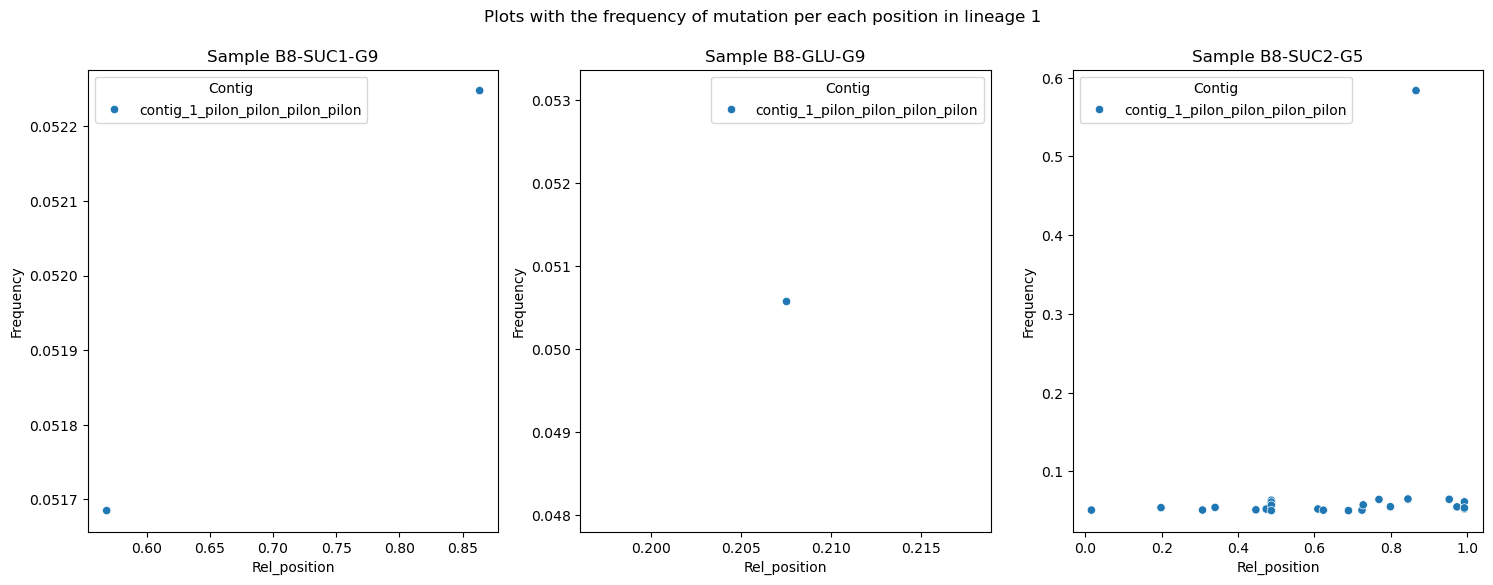

B8-SUC1-F10 done!
B8-GLU-F10 done!
B8-SUC2-F8 done!


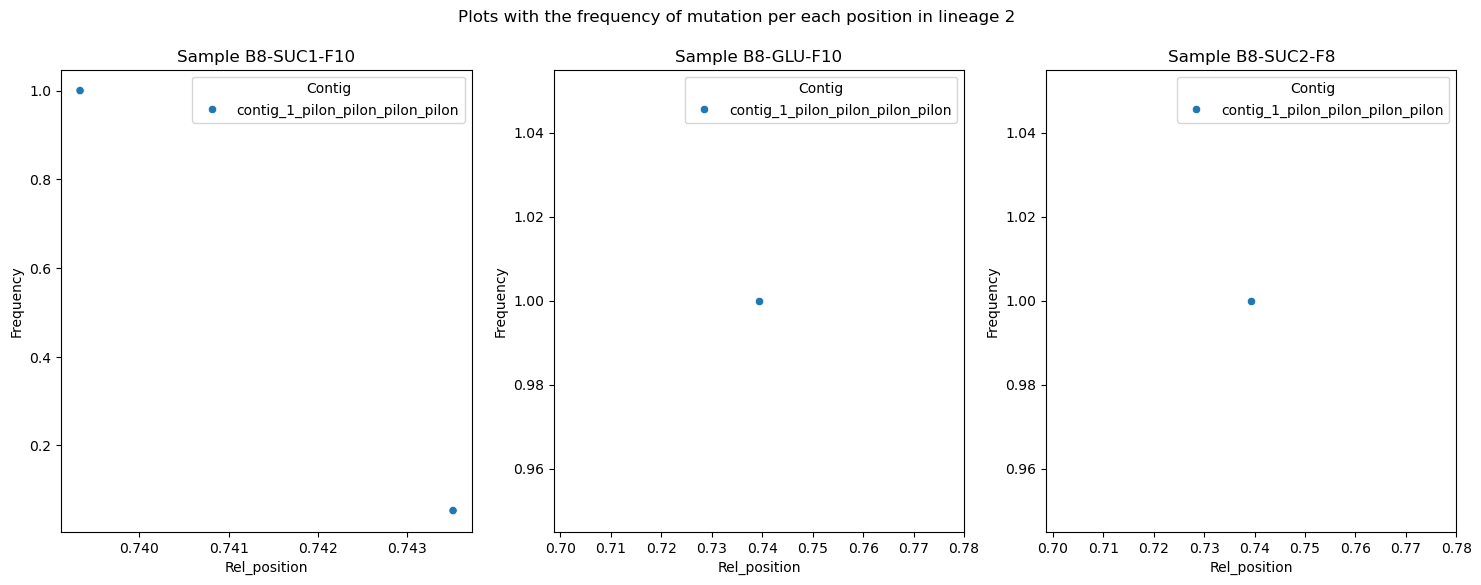

B8-SUC1-H11 done!
B8-GLU-H11 done!
B8-SUC2-H11 done!


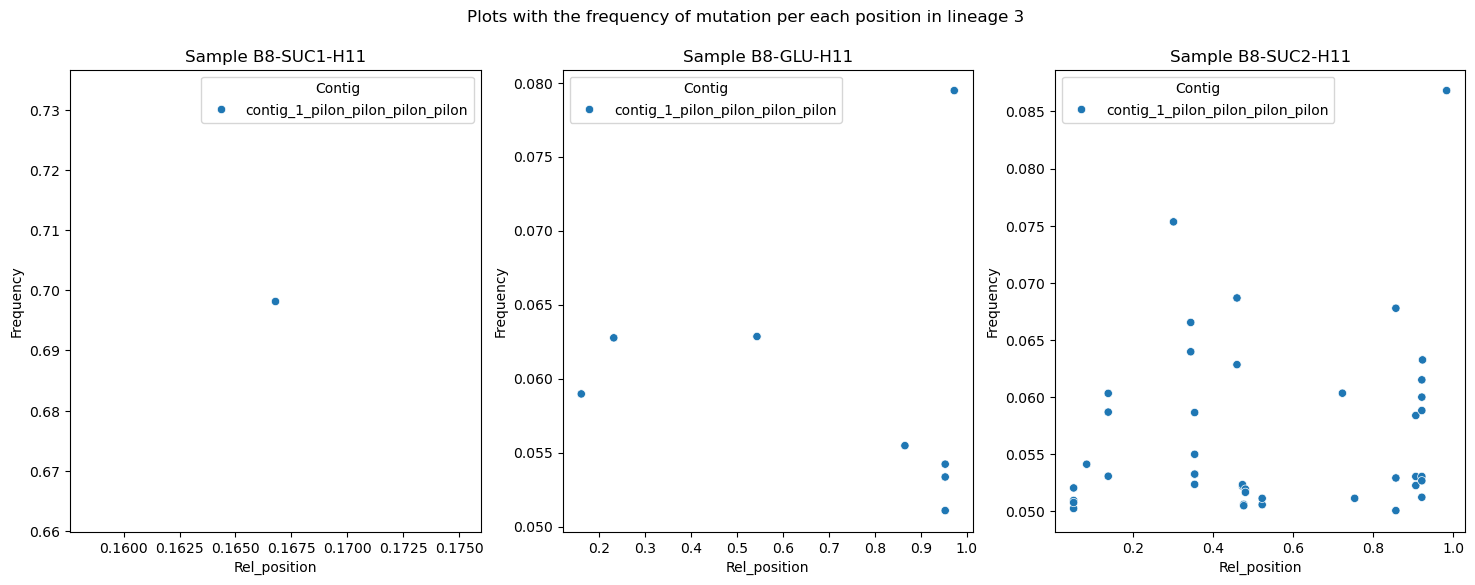

H1-SUC1-A5 done!
H1-GLU-A5 done!
H1-SUC2-A11 done!


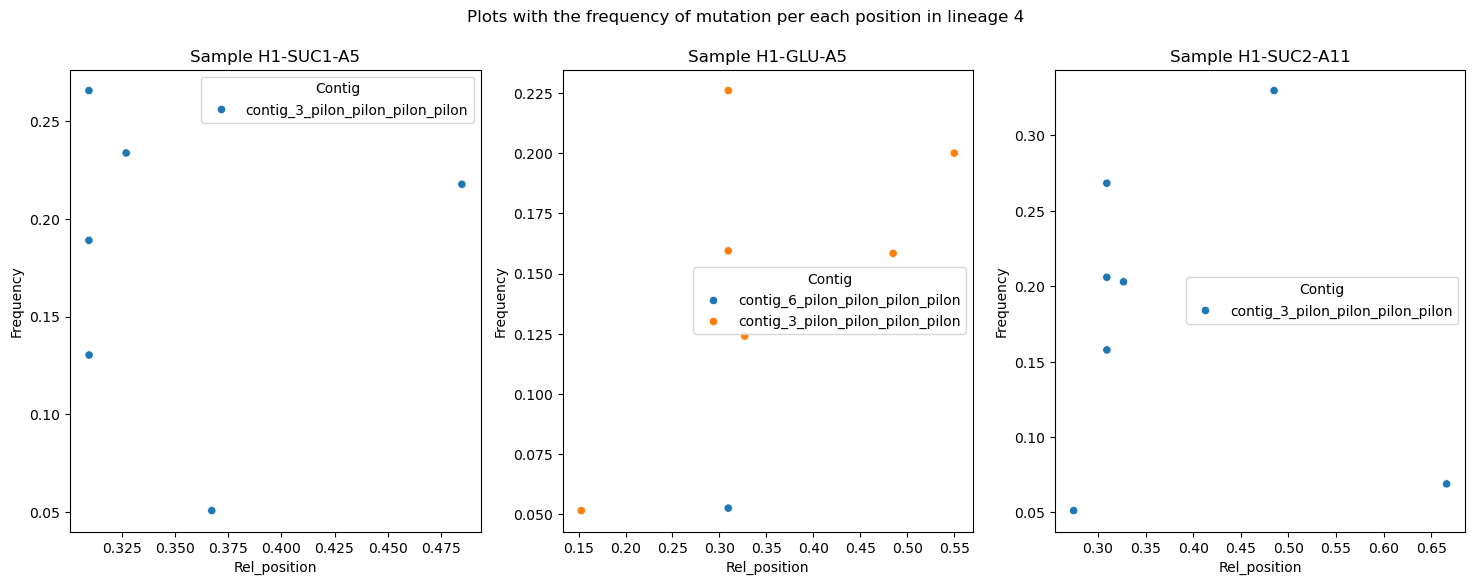

H1-SUC1-D4 done!
H1-GLU-D4 done!
H1-SUC2-D8 done!


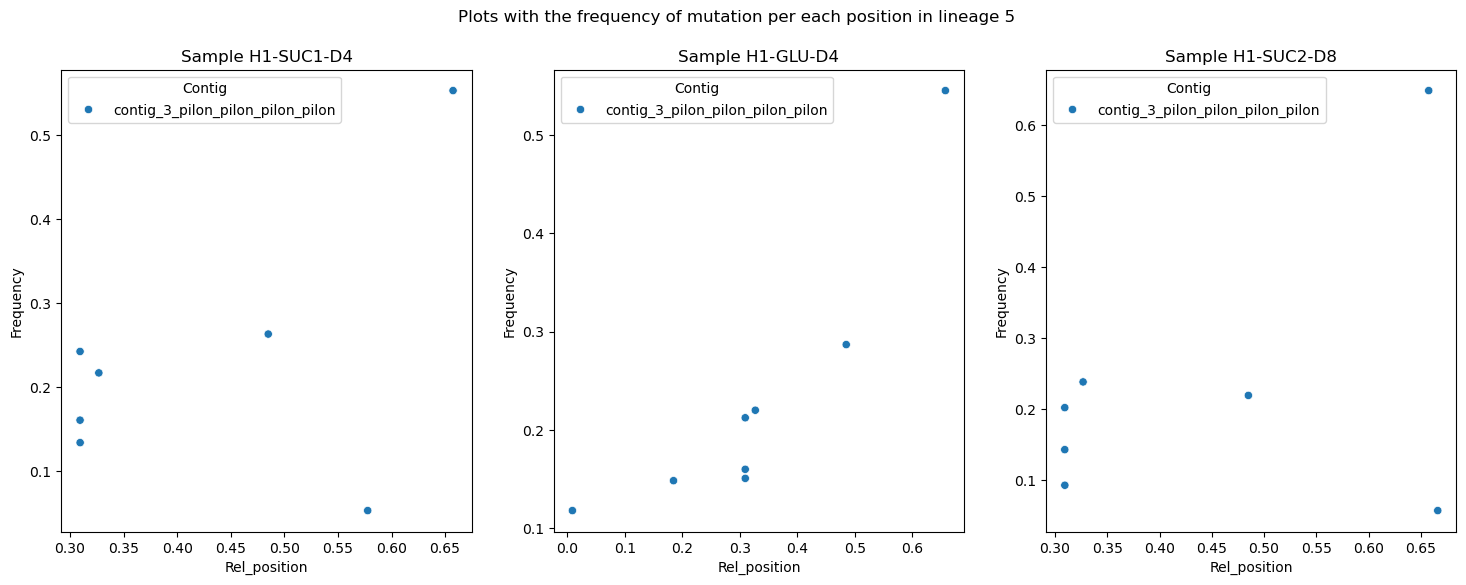

H1-SUC1-E4 done!
H1-GLU-E4 done!
H1-SUC2-E8 done!


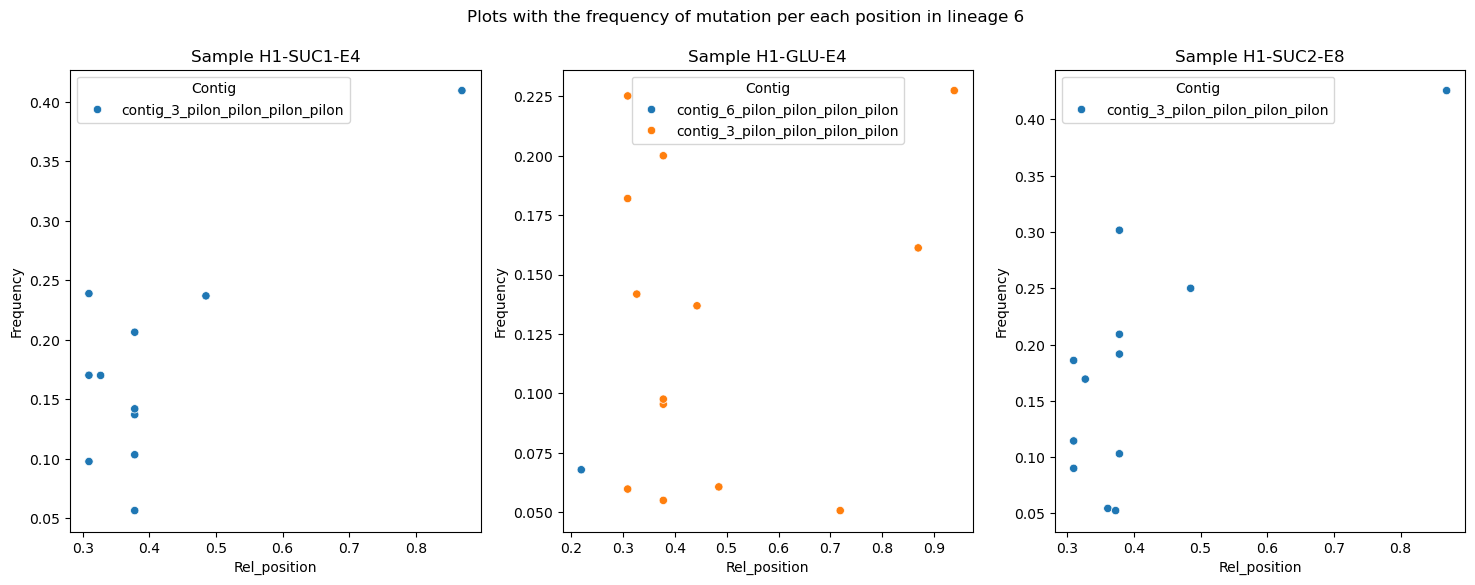

In [39]:
#plotting, for each sample, a plot for the frequency of each mutation based on its position inside the genome
#READ ALIGNMENTS, ABSOLUTE POSITION (CHROMOSOMES only; basically)
max_expected_columns = 70
column_names = [f"col_{i}" for i in range(max_expected_columns)]

for i in dict_lineages.keys():

    working_df = dict_lineages[i]
    fig, axes = plt.subplots(nrows=1, ncols=len(working_df), figsize=(6 * len(working_df), 6), squeeze=False)    
    
    for idx, sample in enumerate(working_df['Sample_name']):
        ax = axes[0,idx]
        cov_file = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/'+ sample + '-breseq/data/coverage.csv'
        cov_csv = pd.read_csv(cov_file, sep = '\t', names = ['Contig', 'Position', 'Coverage'])
        cov_csv.sort_values(by='Contig', ascending=True)
        n_bases_contig = cov_csv.groupby(by='Contig').max()['Position']

        mutation_data = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names, comment = '#')
        mutation_data = mutation_data[(mutation_data['col_0']=='RA')]
        only_frequencies_mask = mutation_data.astype(str).apply(lambda row: row.str.startswith('frequency='))
        only_frequencies_df = mutation_data[only_frequencies_mask] #only considering the boxes with frequency data
        frequencies_mutations = only_frequencies_df.bfill(axis=1)['col_0'].str.strip('frequency=').astype(float) #aligning them
        frequencies_indexed = pd.concat([mutation_data['col_3'], mutation_data['col_4'].astype(float), frequencies_mutations],
                                        axis=1)
        #concatenating the frequency with all the other useful parameters
        frequencies_indexed.columns = ['Contig','Position', 'Frequency']
        position_mask = frequencies_indexed['Position']>4
        frequencies_indexed = frequencies_indexed [position_mask]
        contig_bps = frequencies_indexed['Contig'].map(n_bases_contig)
        relative_position = (frequencies_indexed['Position'] / contig_bps).reset_index(drop=True)
        useful_df = cov_csv.merge(frequencies_indexed, on=['Position','Contig'], how='inner').fillna(0)
        useful_df = pd.concat([useful_df, relative_position], axis = 1)
        useful_df = useful_df.rename(columns={0: 'Rel_position'})
        sns.scatterplot(data=useful_df, x='Rel_position', y='Frequency', hue='Contig', ax=ax)
        print(sample+' done!')
        ax.set_title('Sample '+sample)
    fig.suptitle('Plots with the frequency of mutation per each position in lineage '+ str(i))
    plt.show()
        

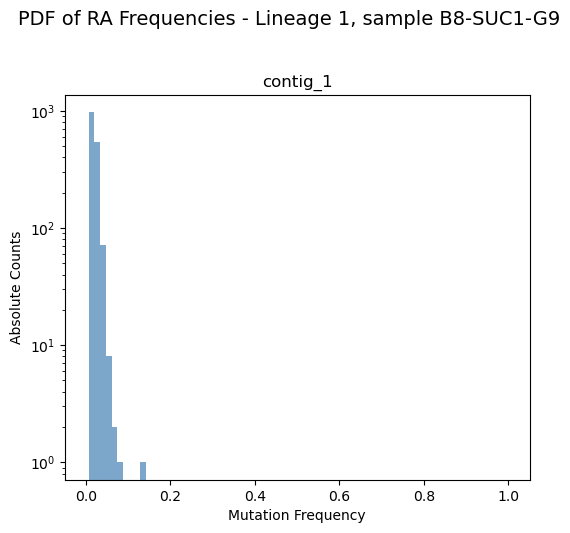

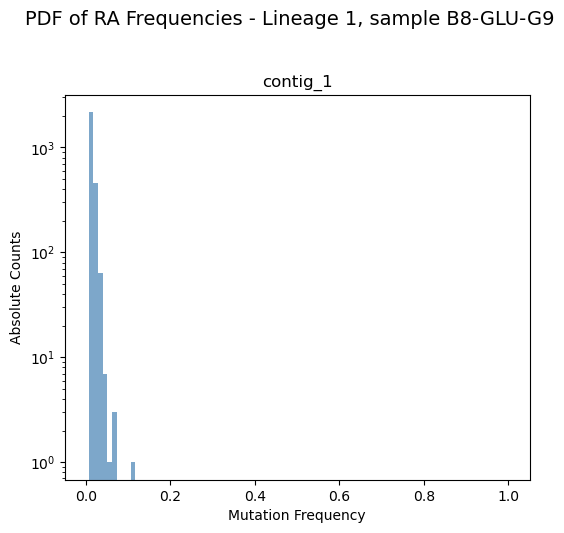

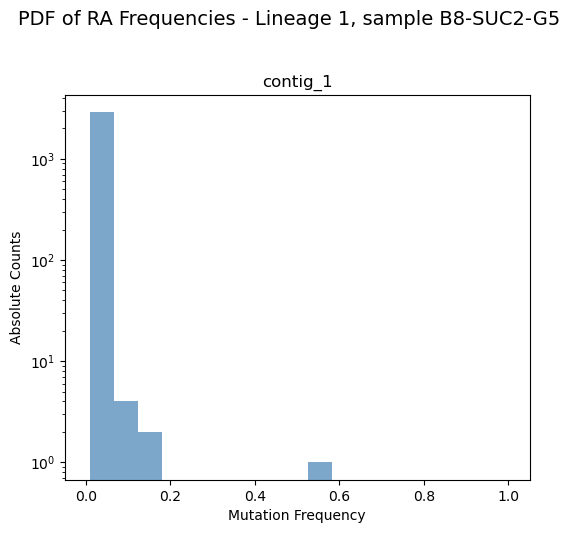

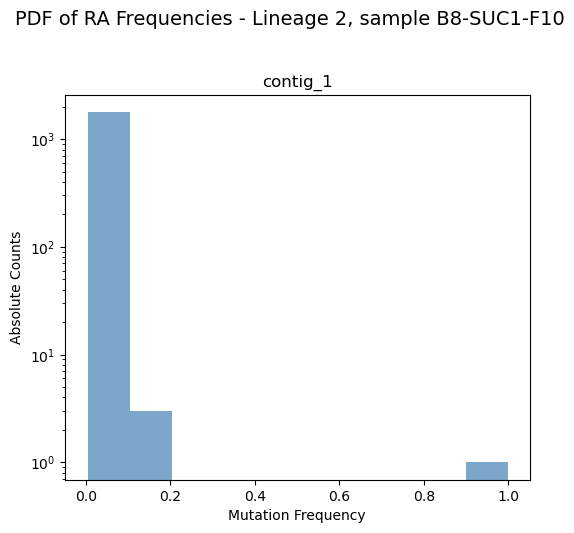

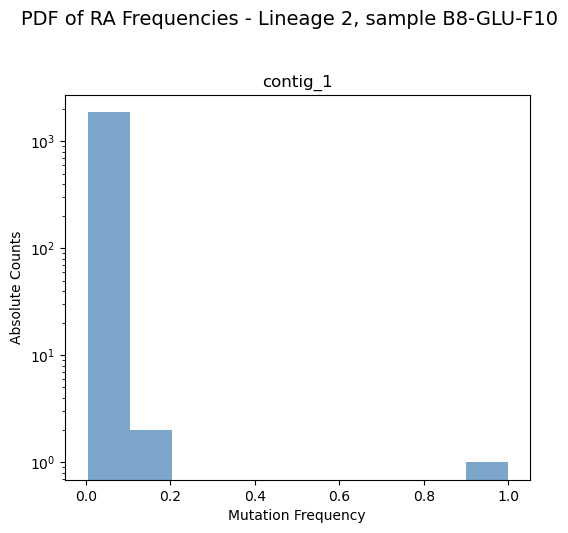

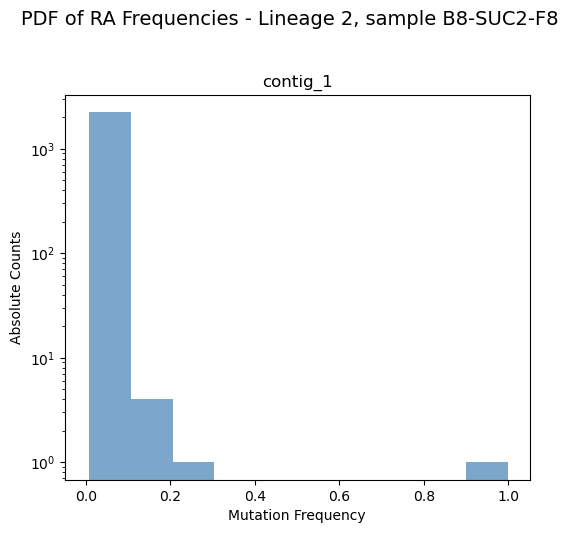

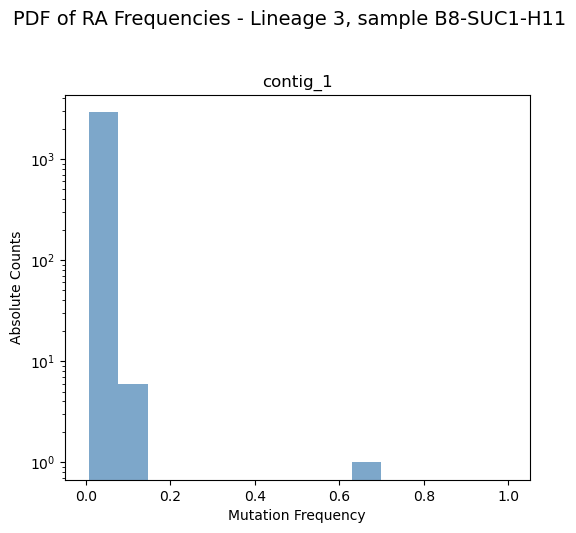

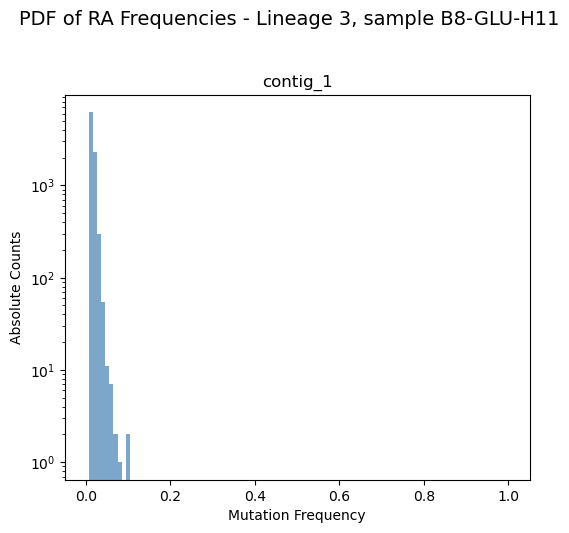

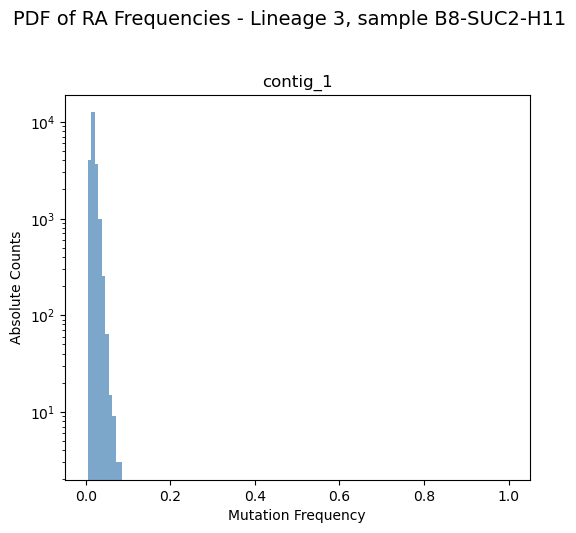

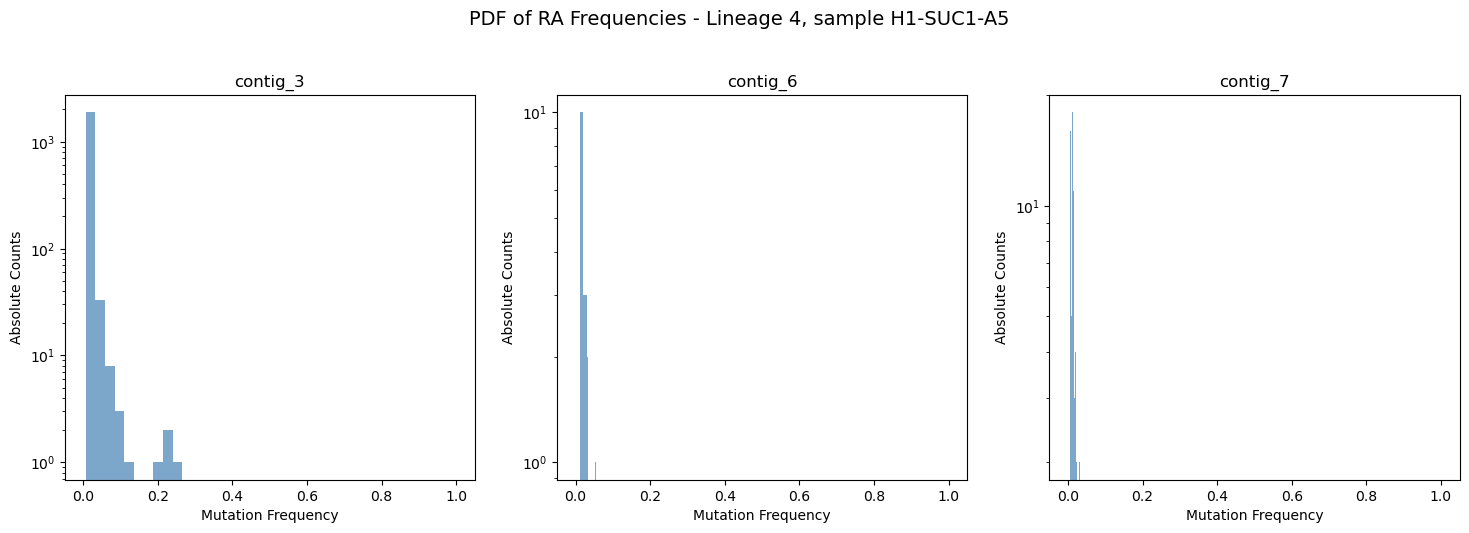

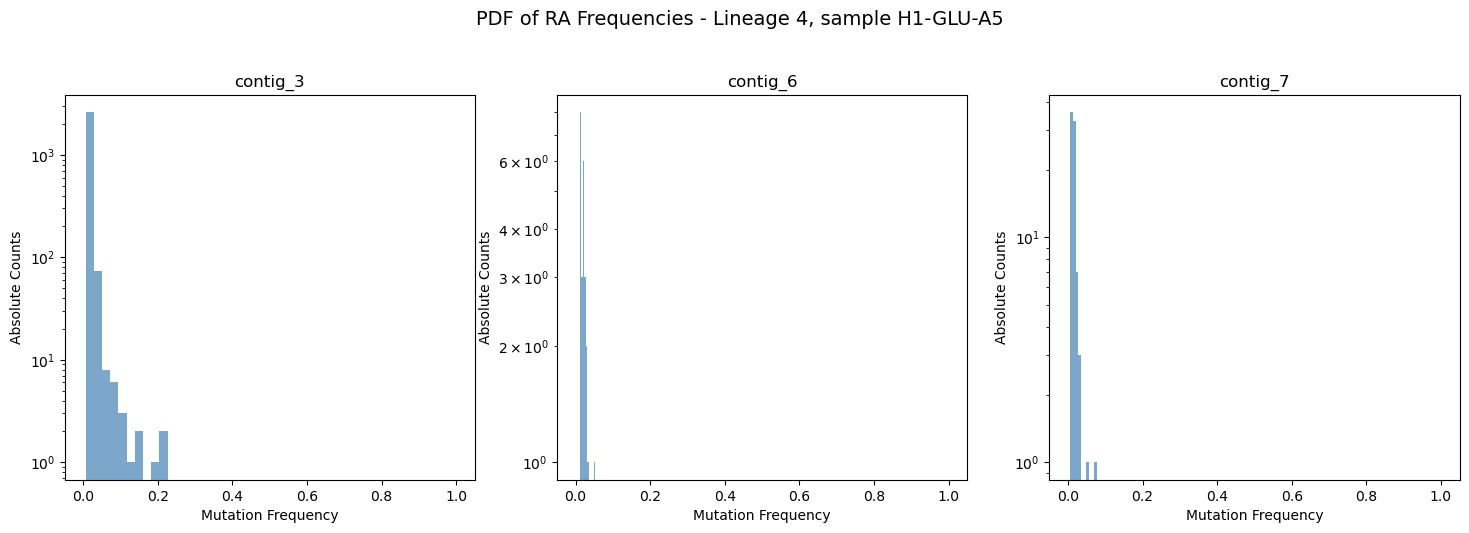

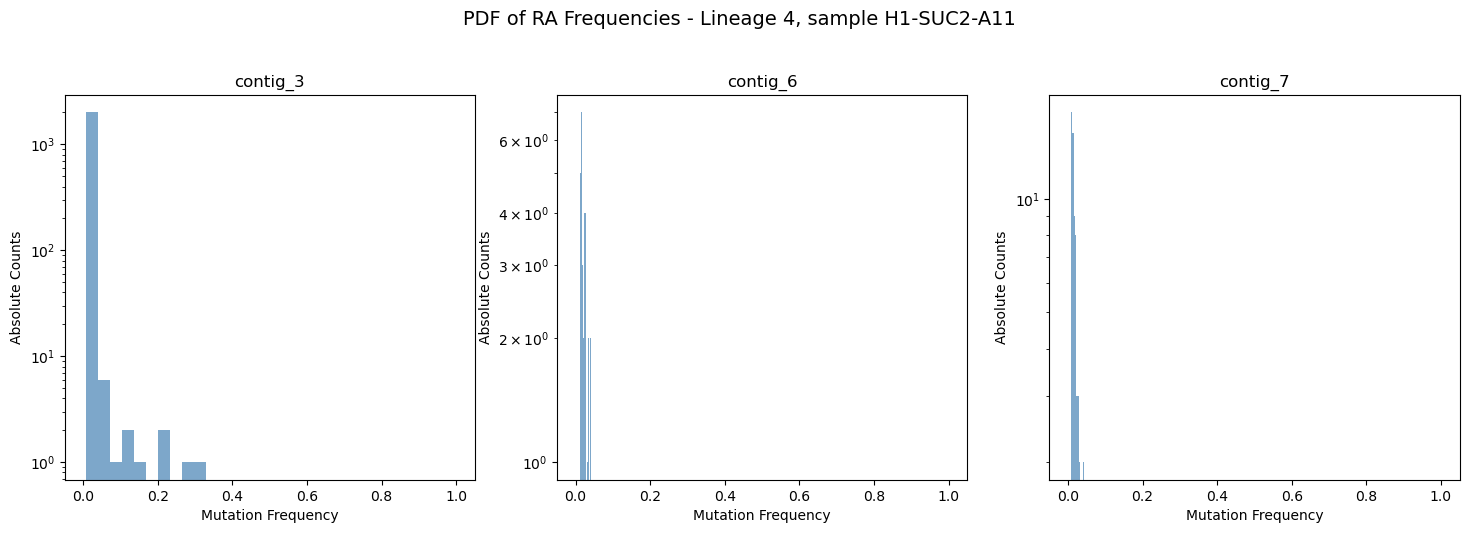

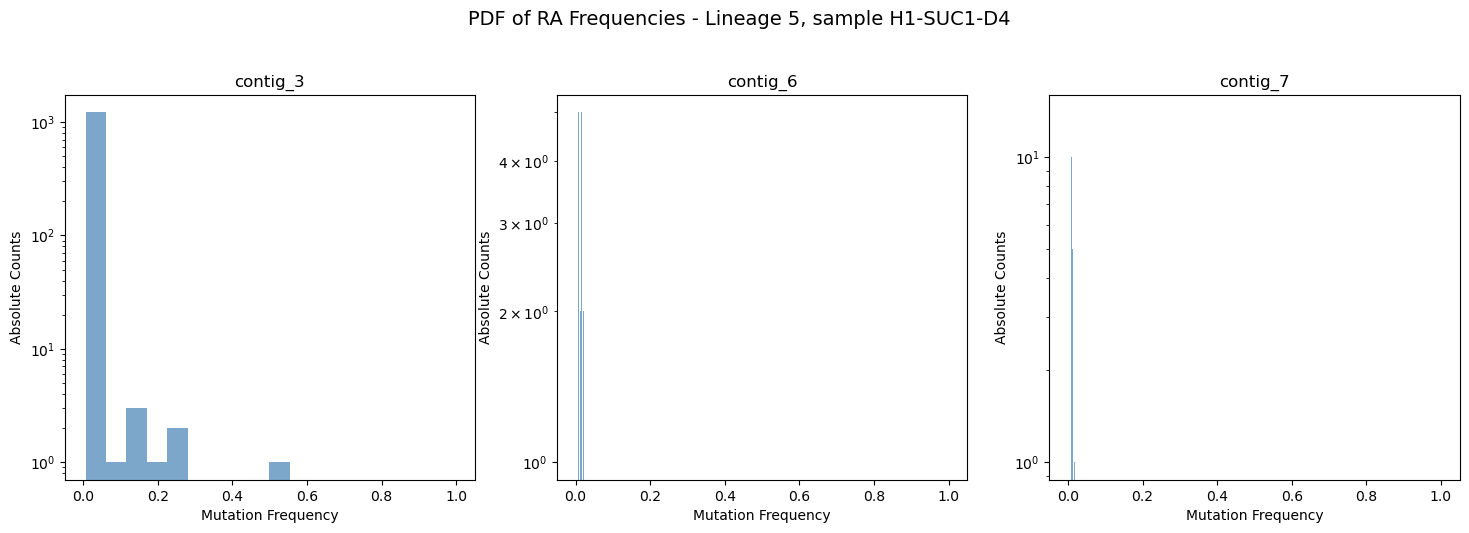

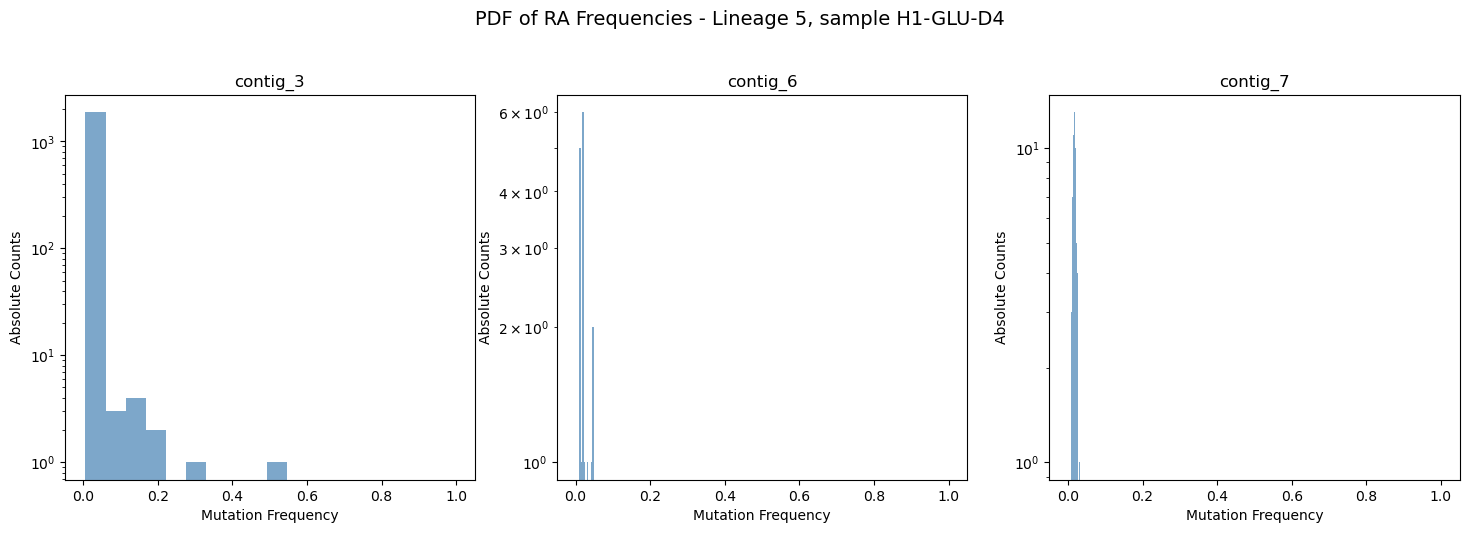

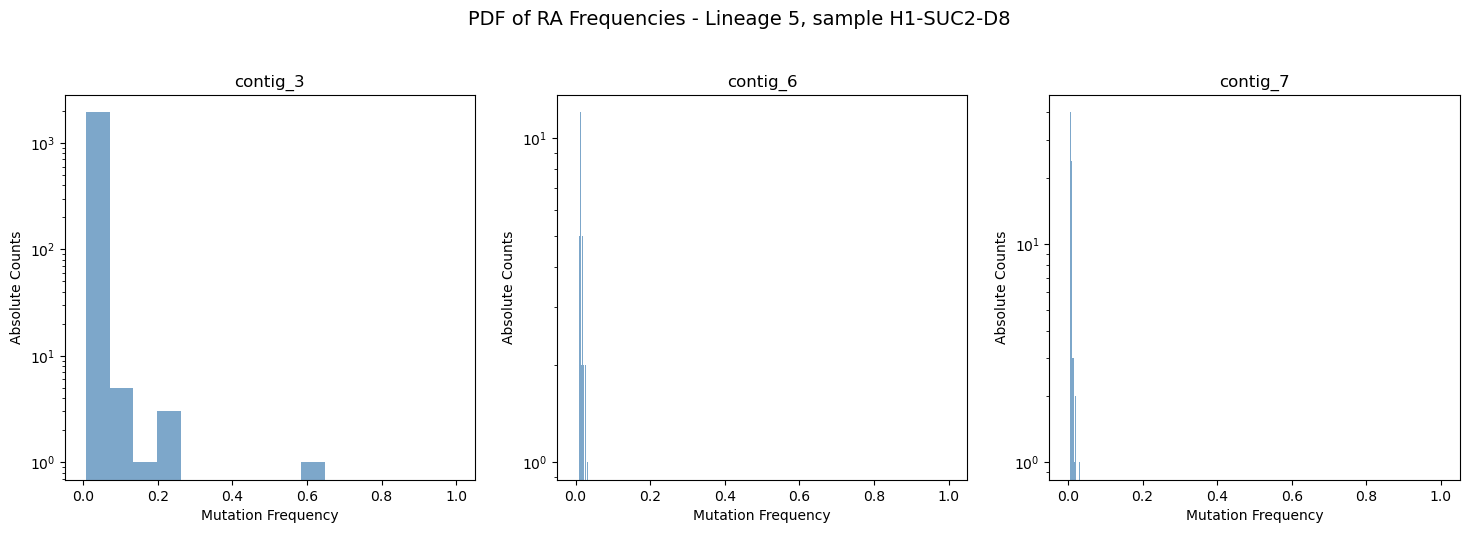

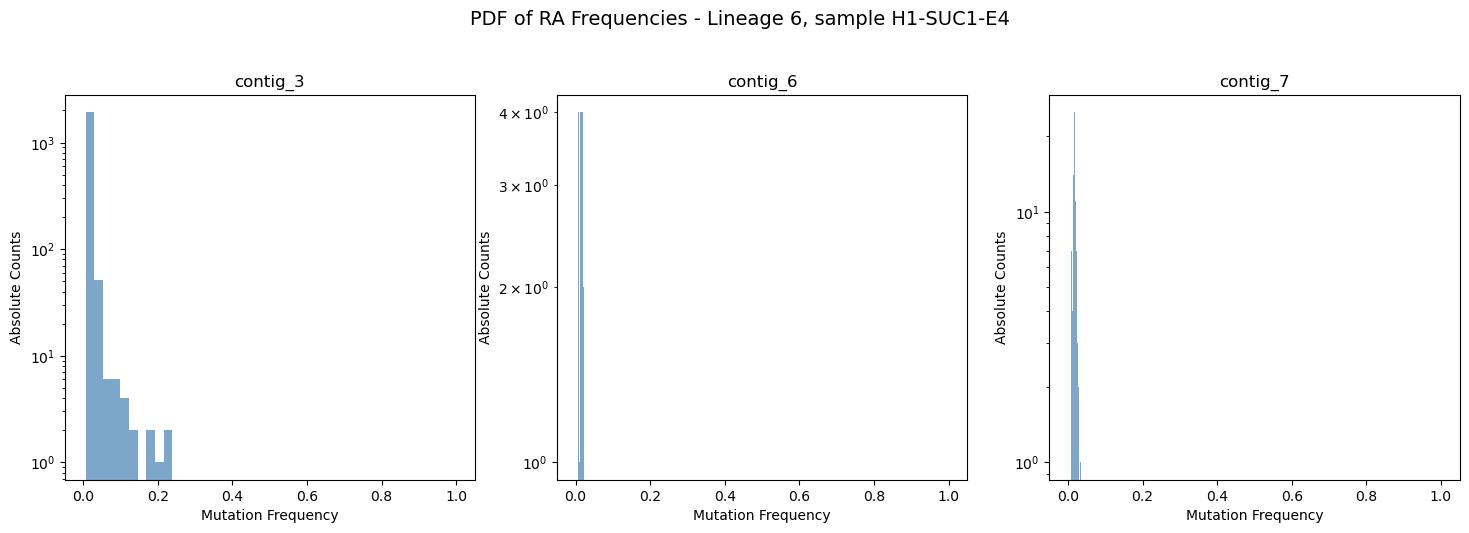

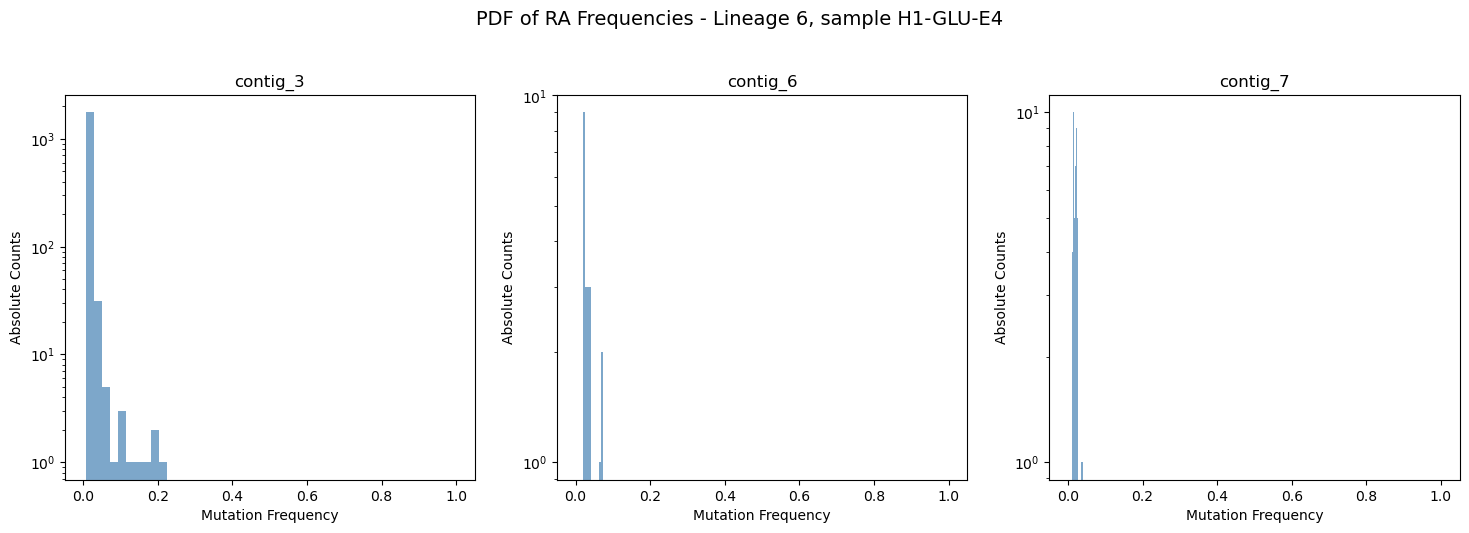

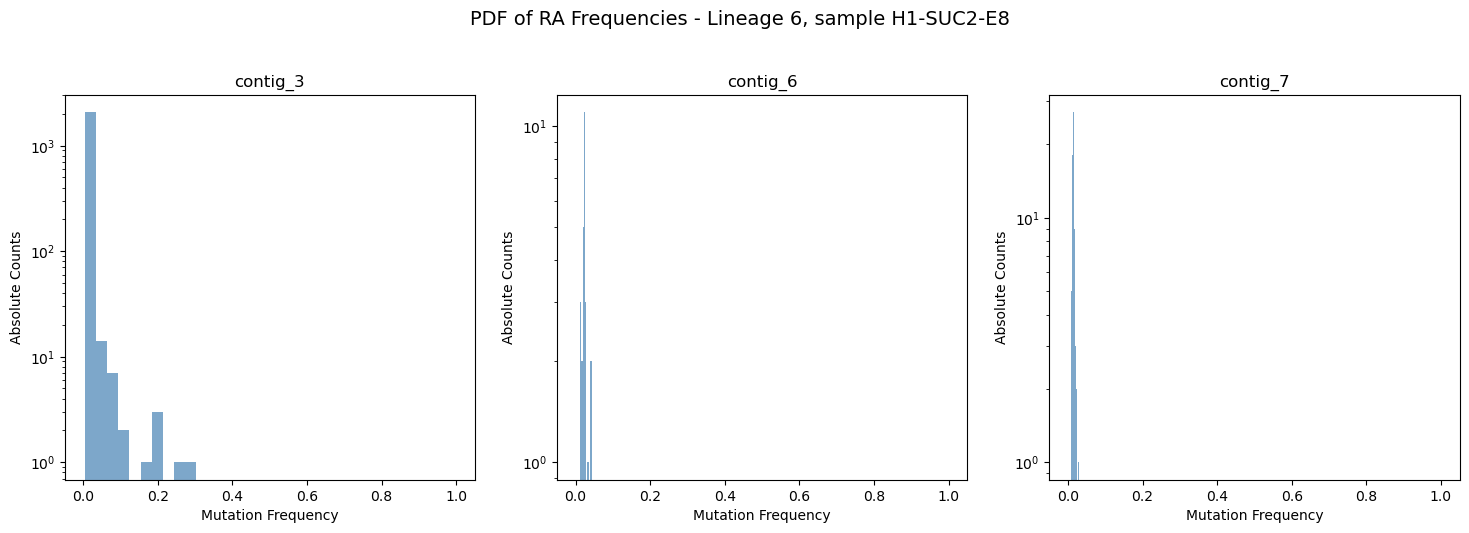

In [26]:
#HISTOGRAMS

max_expected_columns = 70
column_names = [f"col_{i}" for i in range(max_expected_columns)]

for i in dict_lineages.keys():
    working_df = dict_lineages[i]
    
    for idx, sample in enumerate(working_df['Sample_name']):
        
        gd_file = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+pars_folder+'/'+sample+'-breseq/data/annotated.gd'
        mutation_data = pd.read_csv(gd_file, sep='\t', names=column_names, comment='#', low_memory=False)
        mutation_data = mutation_data[mutation_data['col_0'] == 'RA'].copy()
        
        if mutation_data.empty:
            print(f"Sample {sample} has no RA mutations.")
            continue
            

        mutation_data['Contig'] = mutation_data['col_3']
        
        only_frequencies_mask = mutation_data.astype(str).apply(lambda row: row.str.startswith('frequency='))
        only_frequencies_df = mutation_data[only_frequencies_mask]
        frequencies_mutations = only_frequencies_df.bfill(axis=1)['col_0'].str.strip('frequency=').astype(float)
        
        mutation_data['Frequency'] = frequencies_mutations
        
        # 4. Generate the plot
        unique_contigs = mutation_data['Contig'].unique()
        fig, axes = plt.subplots(nrows=1, ncols=len(unique_contigs), figsize=(6 * len(unique_contigs), 5), squeeze=False)
        
        for idxc, contig in enumerate(unique_contigs):
            ax = axes[0, idxc]
            
            contig_data = mutation_data[mutation_data['Contig'] == contig]
            frequencies = contig_data['Frequency'].dropna()
            
            if len(frequencies) > 0:
                counts, bins = np.histogram(frequencies)
                
                # Plot the stairs
                ax.stairs(counts, bins, fill=True, alpha=0.7, color='steelblue')
            
            # Formatting to make it readable
            ax.set_xlim(-0.05, 1.05) # Lock X-axis from 0 to 1
            ax.set_xlabel('Mutation Frequency')
            ax.set_ylabel('Absolute Counts')
            ax.set_yscale('log')
            ax.set_title(contig.rstrip('_pilon'))
        
        fig.suptitle(f'PDF of RA Frequencies - Lineage {i}, sample {sample}', fontsize=14, y=1.05)
        plt.show()

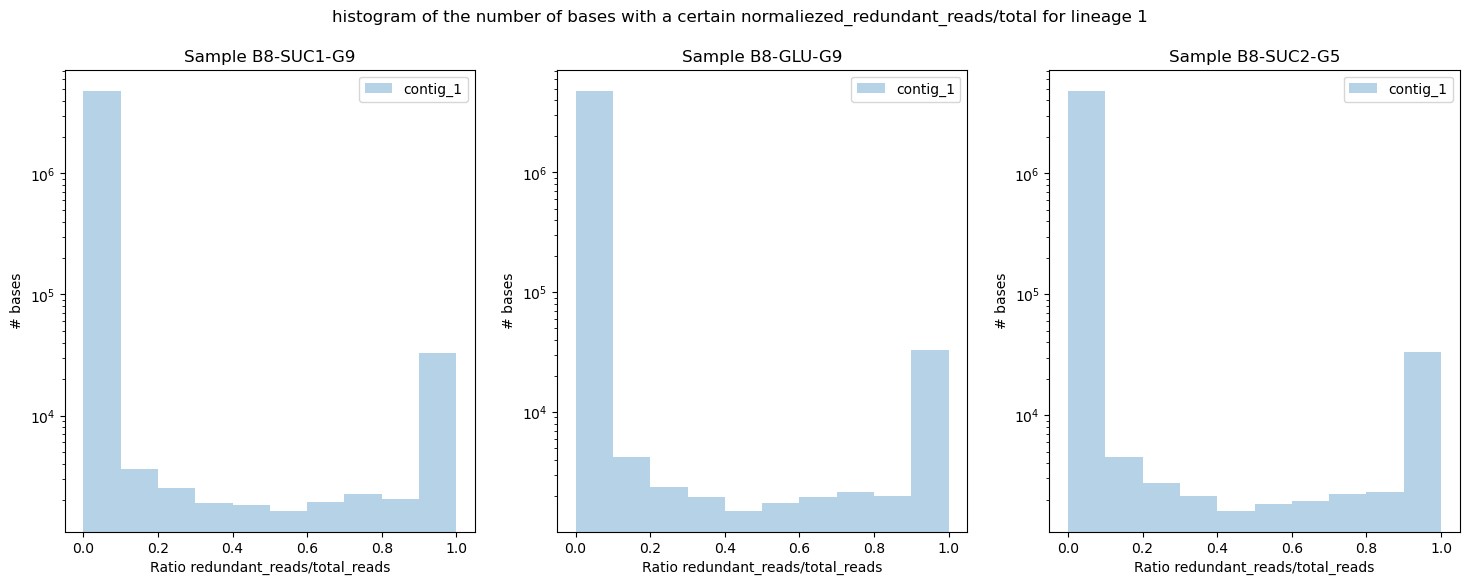

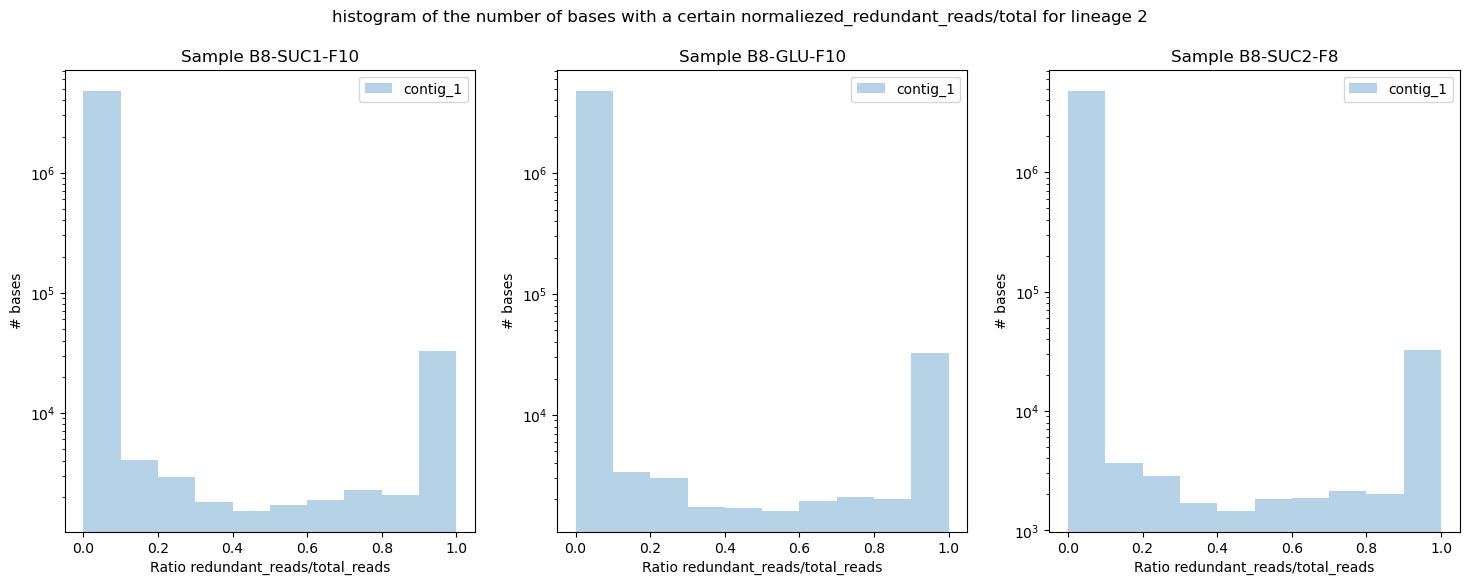

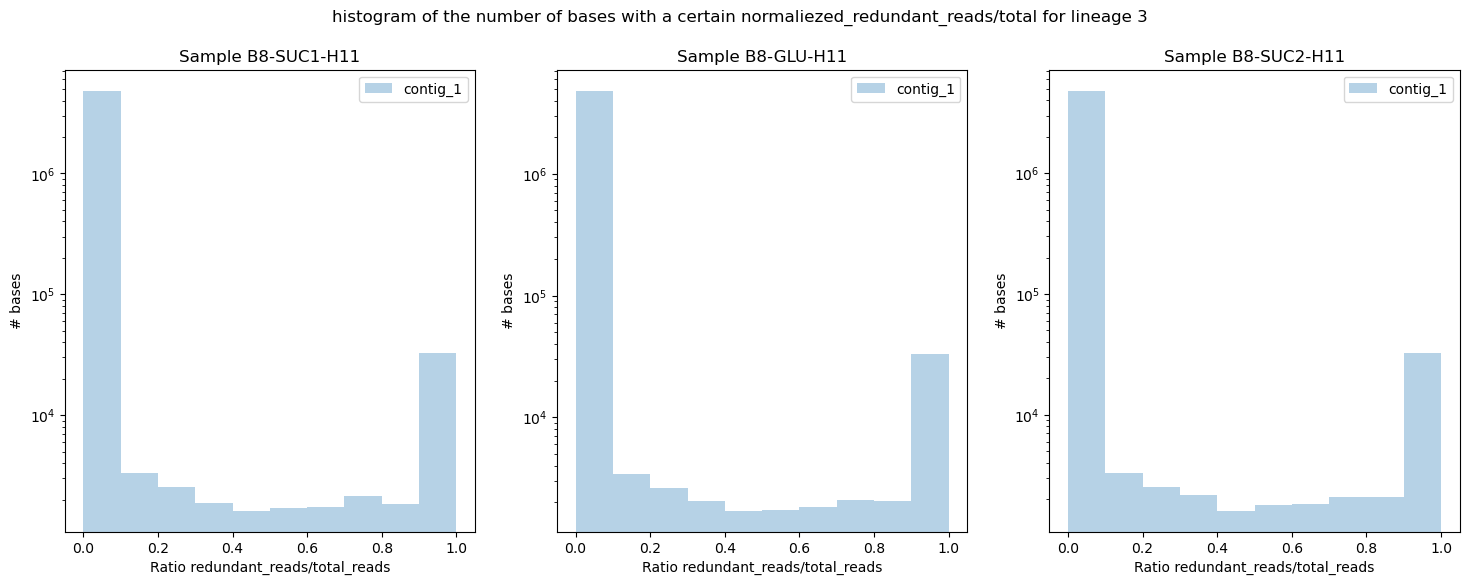

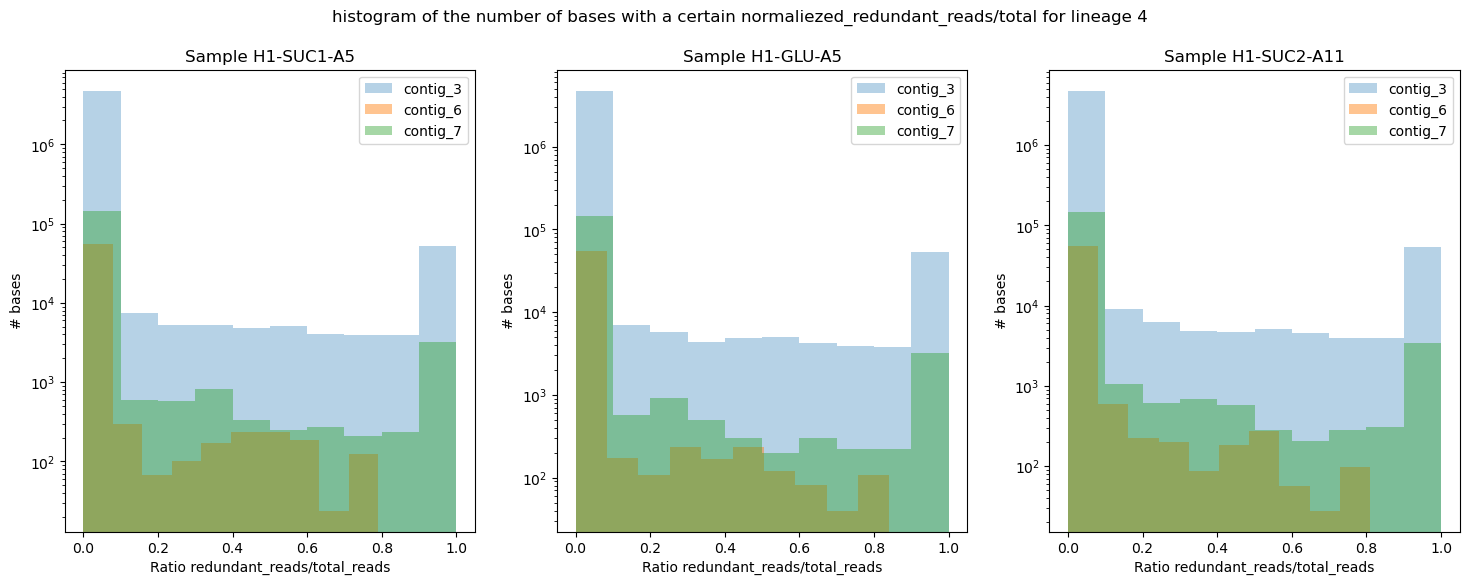

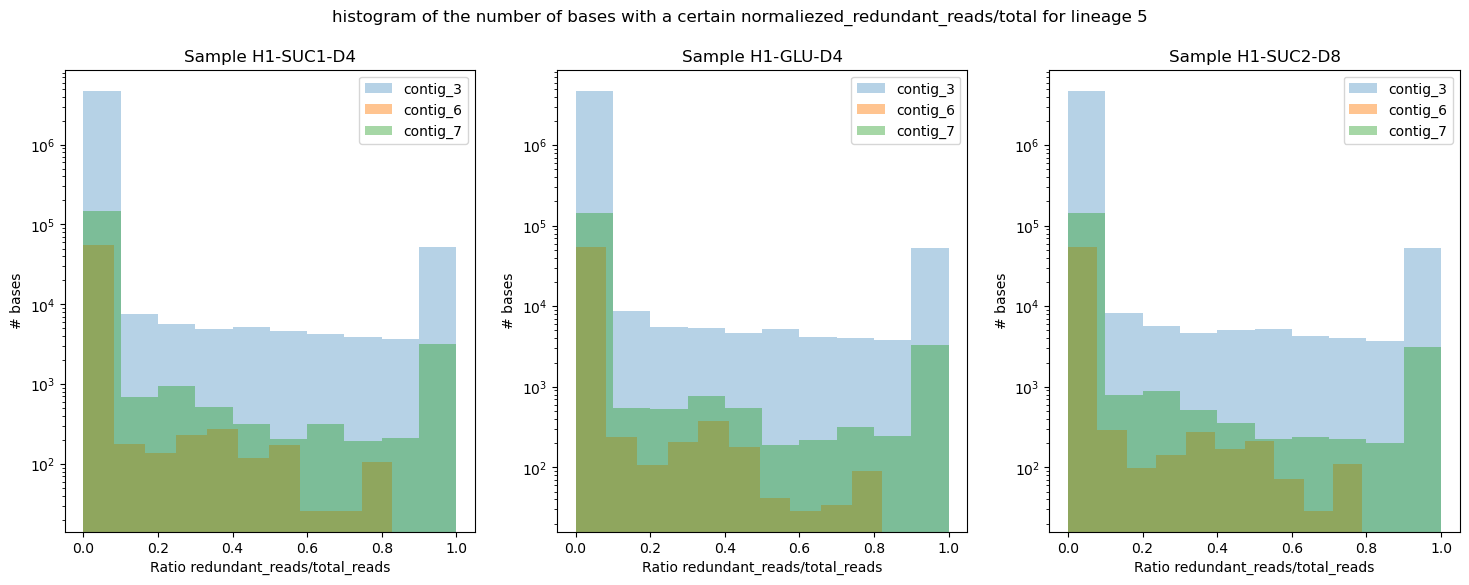

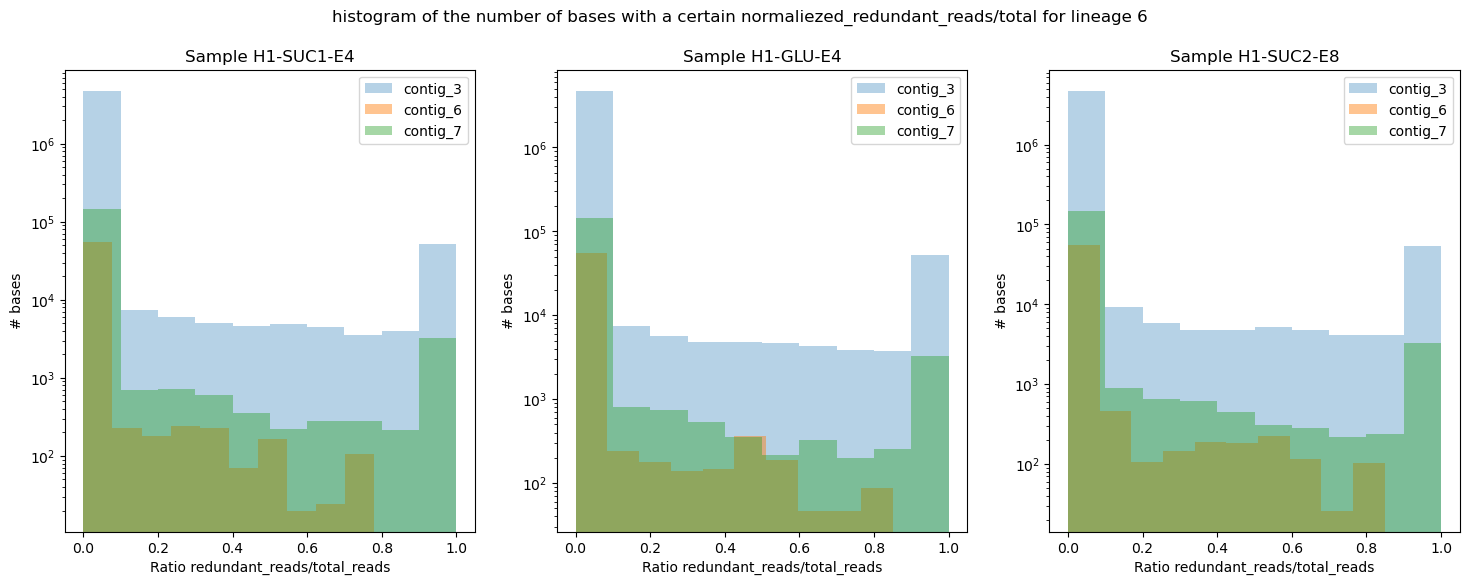

In [83]:
#make a histogram for the RATIO BETWEEN REPEAT READS COVERAGE AND TOTAL READ COVERAGE

for i in dict_lineages.keys():
    working_df = dict_lineages[i]
    fig, axes = plt.subplots(nrows=1, ncols=len(working_df), figsize=(6 * len(working_df), 6), squeeze=False)    
    
    for idx, sample in enumerate(working_df['Sample_name']):
        ax = axes[0,idx]
        sample_dir = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/'+ sample + '-breseq/data/bam2cov_table/'
        cov_file = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/'+ sample + '-breseq/data/coverage.csv'
        cov_csv = pd.read_csv(cov_file, sep = '\t', names = ['Contig', 'Position', 'Coverage'])
        contigs = pd.Series(np.unique(cov_csv['Contig']))
        for contig in contigs:
            bam2cov_file = sample_dir + contig + '_coverage.tab'
            bam2cov_csv = pd.read_csv(bam2cov_file, sep = '\t', comment = '#')
            unique_cov = bam2cov_csv['unique_top_cov'].astype(float) + bam2cov_csv['unique_bot_cov'].astype(float)
            redundant_cov = bam2cov_csv['redundant_top_cov'].astype(float) + bam2cov_csv['redundant_bot_cov'].astype(float)
            repeat_ratio = (redundant_cov / (unique_cov + redundant_cov)).fillna(0)
            repeat_ratio_notzeros = repeat_ratio[repeat_ratio == True]
            counts, bins = np.histogram(repeat_ratio)
            ax.stairs(counts, bins, fill=True, alpha=5/np.log(len(bam2cov_csv)))
        ax.set_xlim(-0.05, 1.05) # Lock X-axis from 0 to 1
        ax.set_xlabel('Ratio redundant_reads/total_reads')
        ax.set_ylabel('# bases')
        ax.legend(contigs.str.rstrip('_pilon'))
        ax.set_yscale('log')
        ax.set_title('Sample '+sample)
    fig.suptitle('histogram of the number of bases with a certain normaliezed_redundant_reads/total for lineage '+str(i))    

Text(0.5, 0.98, 'histogram of the number of bases with a certain normaliezed_redundant_reads/total for pre_culture H1')

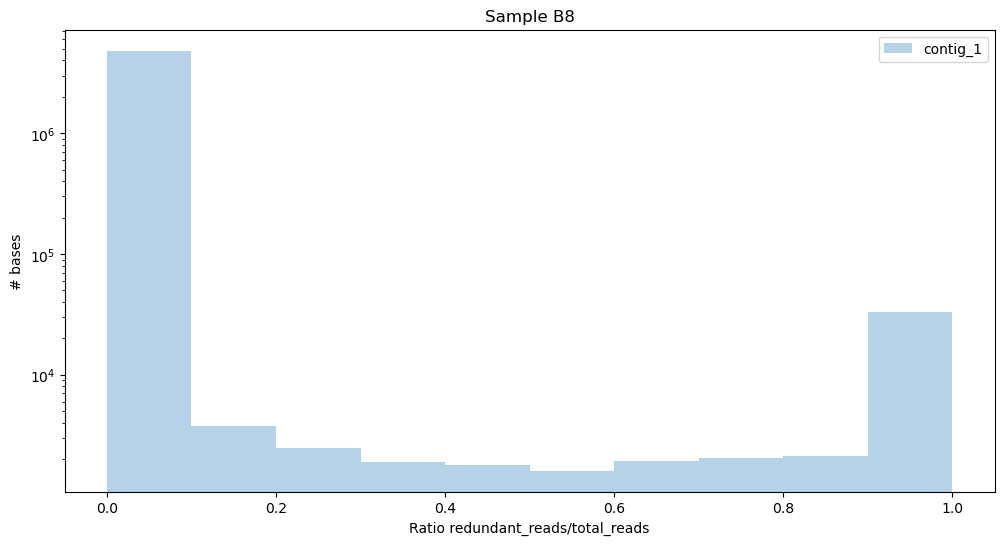

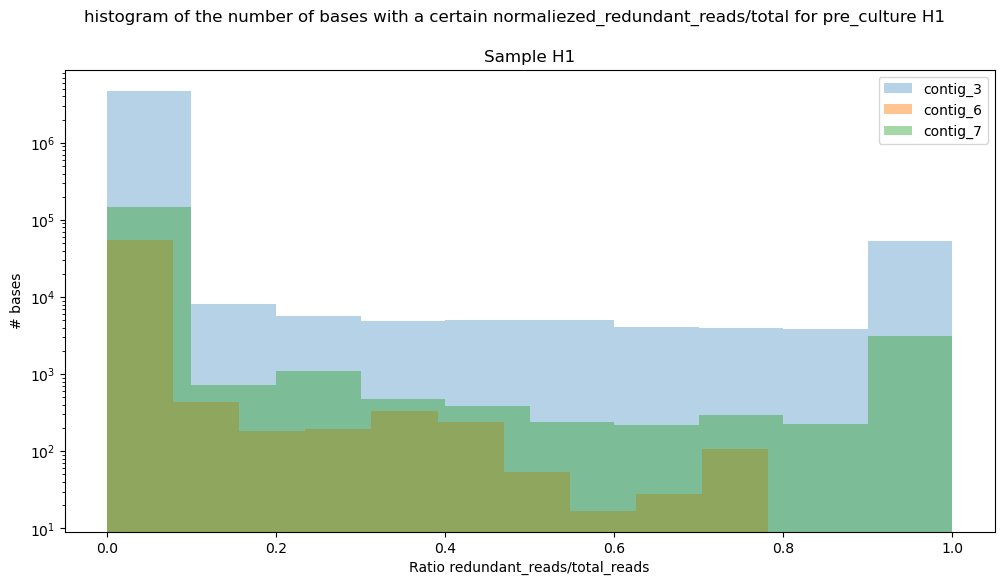

In [84]:
#make a histogram for the RATIO BETWEEN REPEAT READS COVERAGE AND TOTAL READ COVERAGE - PRECULTURES

for sample in dict_precultures.keys():
    
    fig, ax = plt.subplots(figsize=(12, 6)) 
    sample_dir = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/Pre-culture-'+ sample + '-breseq/data/bam2cov_table/'
    cov_file = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/Pre-culture-'+ sample + '-breseq/data/coverage.csv'
    cov_csv = pd.read_csv(cov_file, sep = '\t', names = ['Contig', 'Position', 'Coverage'])
    contigs = pd.Series(np.unique(cov_csv['Contig']))
    for contig in contigs:
        bam2cov_file = sample_dir + contig + '_coverage.tab'
        bam2cov_csv = pd.read_csv(bam2cov_file, sep = '\t', comment = '#')
        unique_cov = bam2cov_csv['unique_top_cov'].astype(float) + bam2cov_csv['unique_bot_cov'].astype(float)
        redundant_cov = bam2cov_csv['redundant_top_cov'].astype(float) + bam2cov_csv['redundant_bot_cov'].astype(float)
        repeat_ratio = (redundant_cov / (unique_cov + redundant_cov)).fillna(0)
        repeat_ratio_notzeros = repeat_ratio[repeat_ratio == True]
        counts, bins = np.histogram(repeat_ratio)
        ax.stairs(counts, bins, fill=True, alpha=5/np.log(len(bam2cov_csv)))
    ax.set_xlim(-0.05, 1.05) # Lock X-axis from 0 to 1
    ax.set_xlabel('Ratio redundant_reads/total_reads')
    ax.set_ylabel('# bases')
    ax.legend(contigs.str.rstrip('_pilon'))
    ax.set_yscale('log')
    ax.set_title('Sample '+sample)
fig.suptitle('histogram of the number of bases with a certain normalized_redundant_reads/total for pre_culture '+ sample)    

WARNINg! 10^-5 frequencies menas that only unique reads are mapping with that mutation!


/scratch/cappel0001/slurm-job.21146981/ipykernel_4136997/4093035469.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutant_coverages.loc[:, 'rel_position'] = mutant_coverages['position'] / contig_len
/scratch/cappel0001/slurm-job.21146981/ipykernel_4136997/4093035469.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutant_coverages.loc[:, 'rel_position'] = mutant_coverages['position'] / contig_len
/scratch/cappel0001/slurm-job.21146981/ipykernel_4136997/4093035469.py:30: SettingWithCopyWarning: 
A 

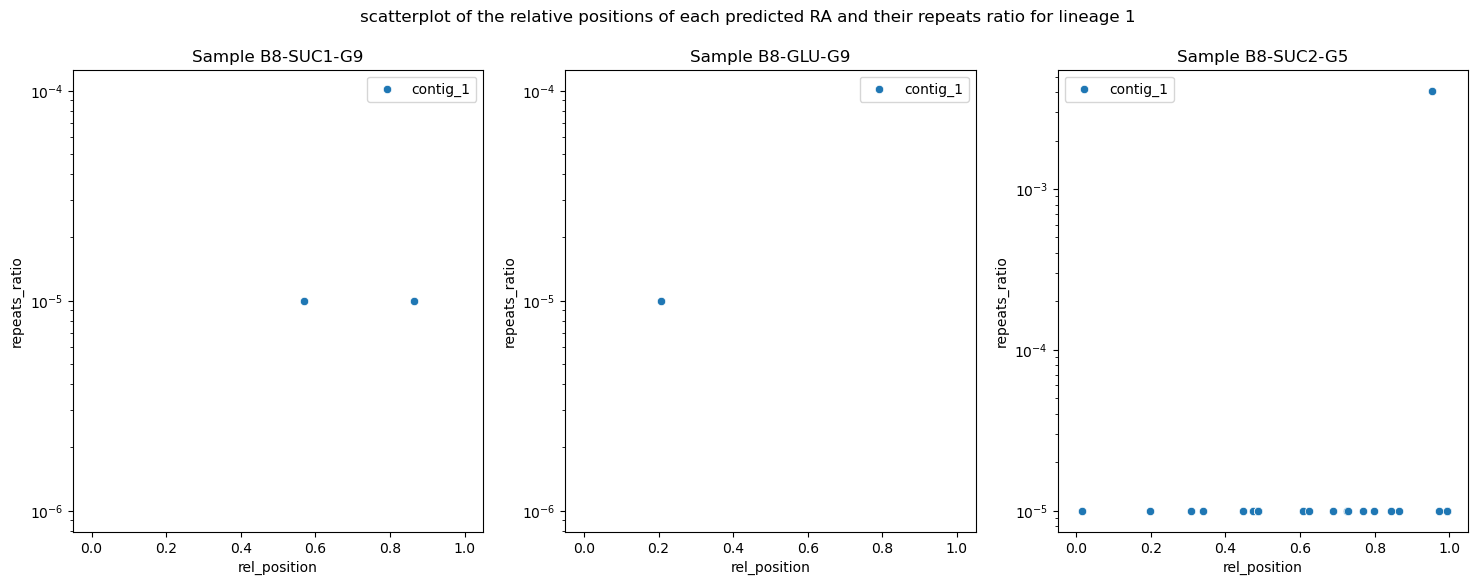

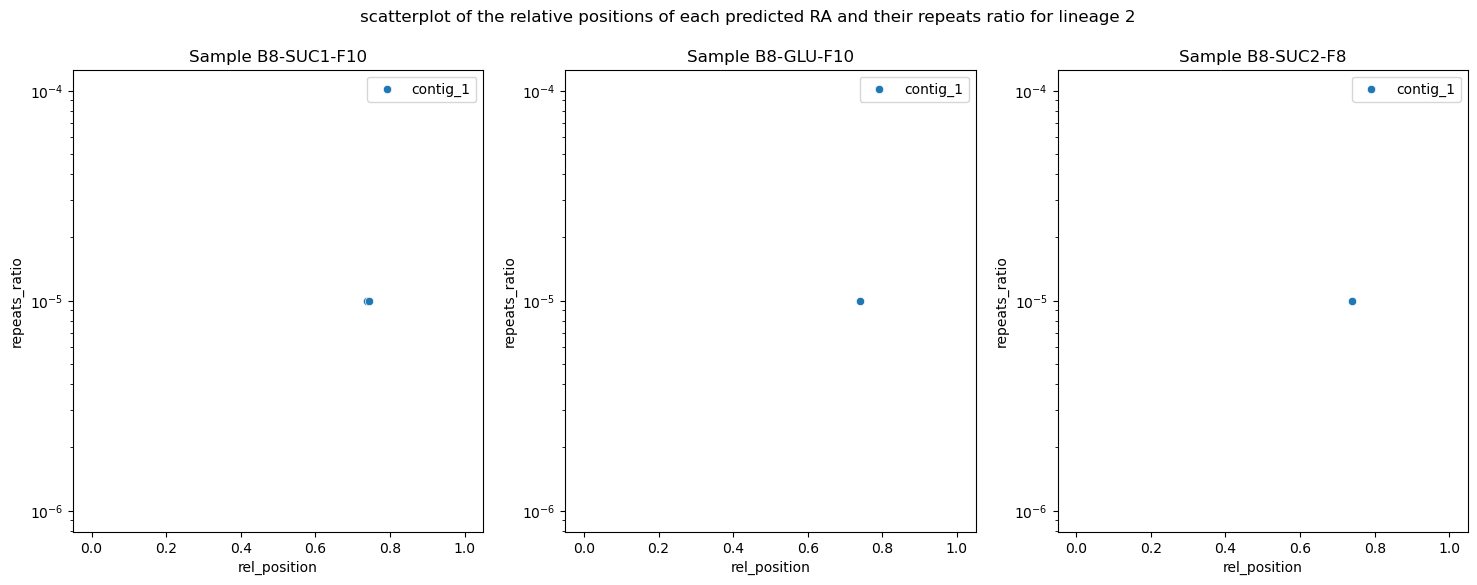

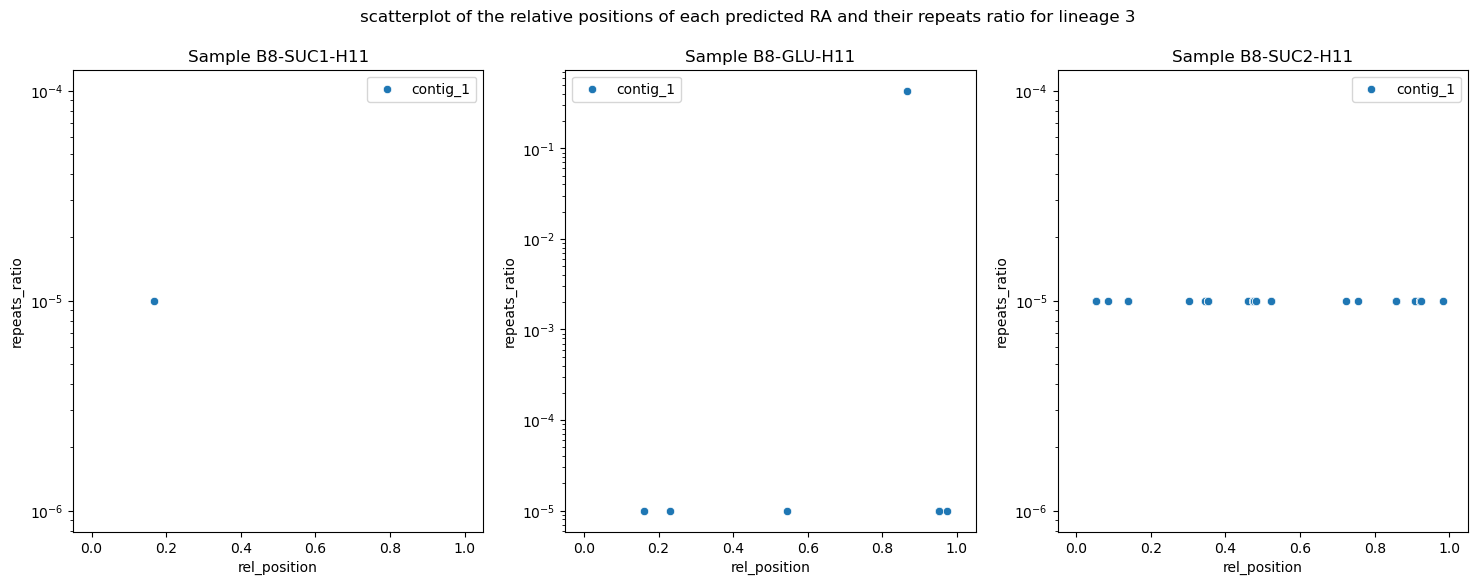

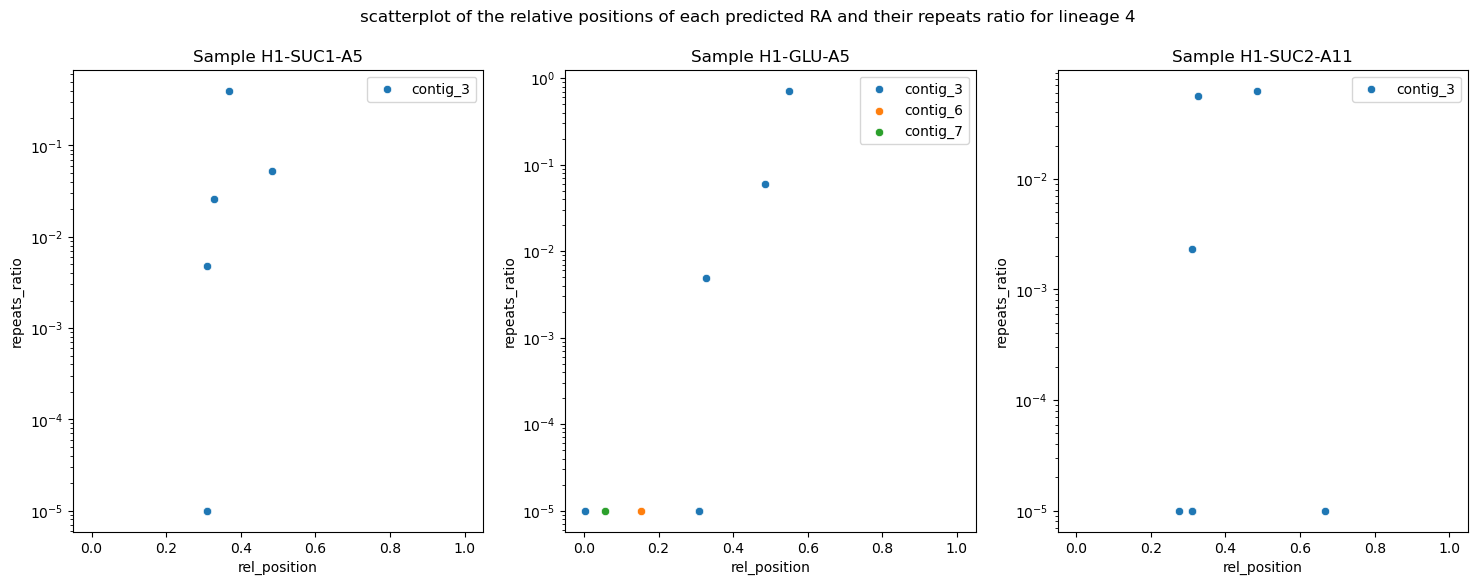

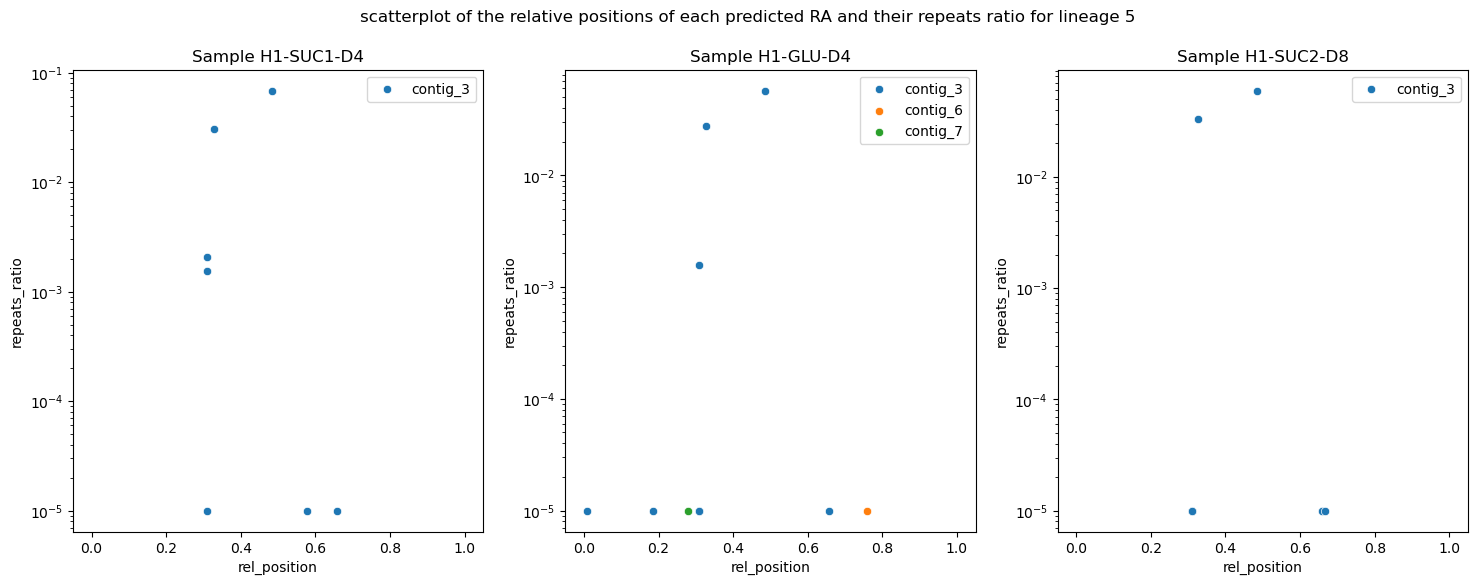

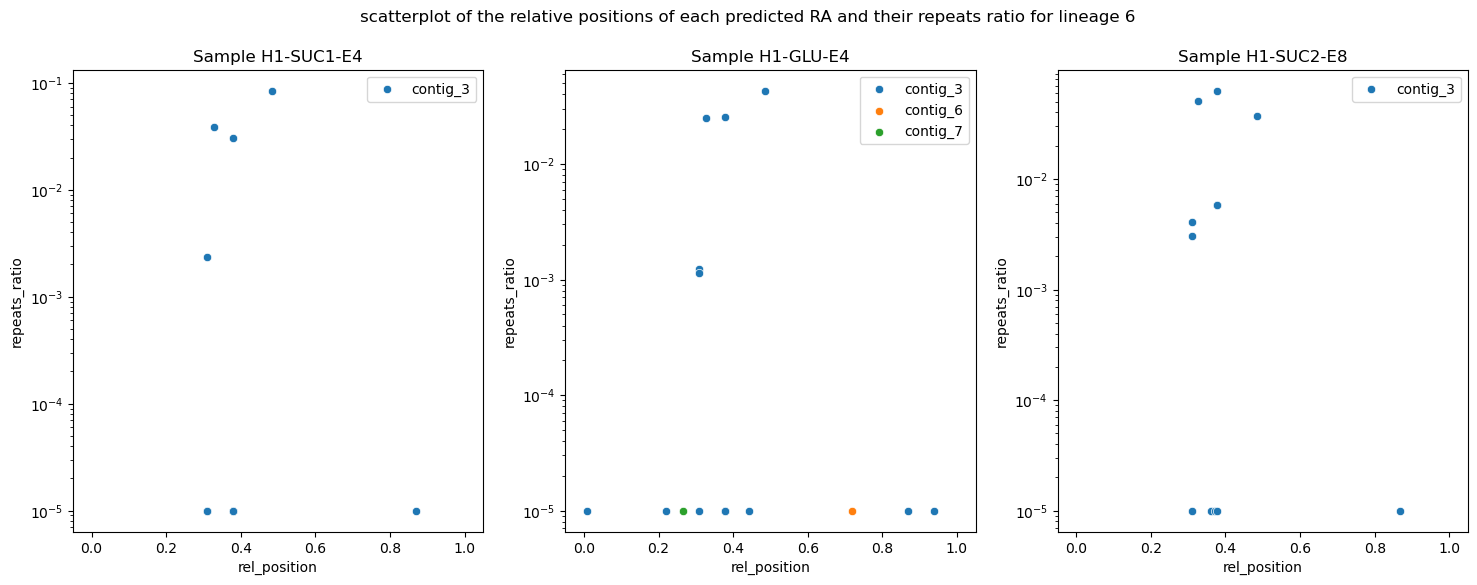

In [326]:
#for each sample make a scatterplot that shows on the x-axis the position of the mutation for the contig; on the y-axis, their ratio
#make a histogram for the RATIO BETWEEN REPEAT READS COVERAGE AND TOTAL READ COVERAGE

print('WARNING! 10^-5 frequencies menas that only unique reads are mapping with that mutation!')
variant_option = 'RA'
for i in dict_lineages.keys():
    working_df = dict_lineages[i]
    fig, axes = plt.subplots(nrows=1, ncols=len(working_df), figsize=(6 * len(working_df), 6), squeeze=False)    
    
    for idx, sample in enumerate(working_df['Sample_name']):
        ax = axes[0,idx]
        sample_dir = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/'+ sample + '-breseq/data/bam2cov_table/'
        cov_file = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/'+ sample + '-breseq/data/coverage.csv'
        cov_csv = pd.read_csv(cov_file, sep = '\t', names = ['Contig', 'Position', 'Coverage'])
        contigs = pd.Series(np.unique(cov_csv['Contig']))
        
        for contig in contigs:
            bam2cov_file = sample_dir + contig + '_coverage.tab'
            bam2cov_csv = pd.read_csv(bam2cov_file, sep = '\t', comment = '#')
            unique_cov = bam2cov_csv['unique_top_cov'].astype(float) + bam2cov_csv['unique_bot_cov'].astype(float)
            redundant_cov = bam2cov_csv['redundant_top_cov'].astype(float) + bam2cov_csv['redundant_bot_cov'].astype(float)
            repeat_ratio = (redundant_cov / (unique_cov + redundant_cov)).fillna(0) + pow(10, -5)
            bam2cov_csv['repeats_ratio'] = repeat_ratio

            mutation_data = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names, comment = '#')
            mutation_data = mutation_data[(mutation_data['col_0']==variant_option)]
            contig_len = len(bam2cov_csv)
            mutant_coverages = bam2cov_csv[bam2cov_csv['position'].isin(mutation_data['col_4'])]
            if len(mutant_coverages):
                mutant_coverages.loc[:, 'rel_position'] = mutant_coverages['position'] / contig_len

                sns.scatterplot(mutant_coverages, x='rel_position', y ='repeats_ratio', ax=ax)
            
        ax.set_xlim(-0.05, 1.05) # Lock X-axis from 0 to 1
        ax.legend(contigs.str.rstrip('_pilon'))
        ax.set_yscale('log')
        ax.set_title('Sample '+sample)
    fig.suptitle('scatterplot of the relative positions of each predicted '+ variant_option+' and their repeats ratio for lineage '+str(i))
    fig.show()


In [309]:
#for each REFERENCEEEEe make a scatterplot that shows on the x-axis the position of the mutation for the contig; on the y-axis, their ratio
#make a histogram for the RATIO BETWEEN REPEAT READS COVERAGE AND TOTAL READ COVERAGE
print('WARNING! 10^-5 frequencies menas that only unique reads are mapping with that mutation!')
variant_option = 'RA'

for sample in dict_precultures.keys():
    fig, ax = plt.subplots(figsize=(12, 6))     
    sample_dir = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/Pre-culture-'+ sample + '-breseq/data/bam2cov_table/'
    cov_file = dict_precultures[sample]
    cov_csv = pd.read_csv(cov_file, sep = '\t', names = ['Contig', 'Position', 'Coverage'])
    contigs = pd.Series(np.unique(cov_csv['Contig']))
        
    for contig in contigs:
        bam2cov_file = sample_dir + contig + '_coverage.tab'
        bam2cov_csv = pd.read_csv(bam2cov_file, sep = '\t', comment = '#')
        unique_cov = bam2cov_csv['unique_top_cov'].astype(float) + bam2cov_csv['unique_bot_cov'].astype(float)
        redundant_cov = bam2cov_csv['redundant_top_cov'].astype(float) + bam2cov_csv['redundant_bot_cov'].astype(float)
        repeat_ratio = (redundant_cov / (unique_cov + redundant_cov)).fillna(0) + pow(10, -5)
        bam2cov_csv['repeats_ratio'] = repeat_ratio

        mutation_data = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/Pre-culture-'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names, comment = '#')
        mutation_data = mutation_data[(mutation_data['col_0']==variant_option)]
        contig_len = len(bam2cov_csv)
        mutant_coverages = bam2cov_csv[bam2cov_csv['position'].isin(mutation_data['col_4'])]
        if len(mutant_coverages):
            mutant_coverages.loc[:, 'rel_position'] = mutant_coverages['position'] / contig_len

            sns.scatterplot(mutant_coverages, x='rel_position', y ='repeats_ratio', ax=ax)
        
        ax.set_xlim(-0.05, 1.05) # Lock X-axis from 0 to 1
        ax.legend(contigs.str.rstrip('_pilon'))
        ax.set_yscale('log')
        ax.set_title('Sample '+sample)
    fig.suptitle('scatterplot of the relative positions of each predicted '+ variant_option +' and their repeats ratio for the pre_culture of '+ sample)
    fig.show()


SyntaxError: invalid syntax (3584114314.py, line 32)

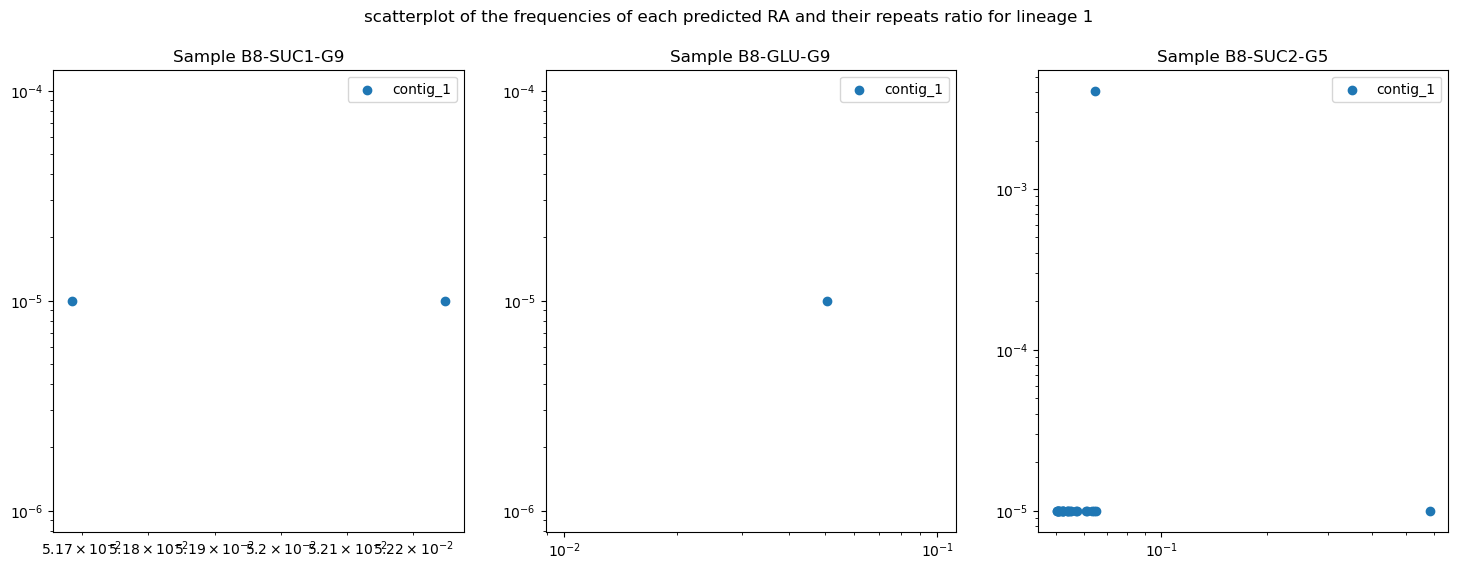

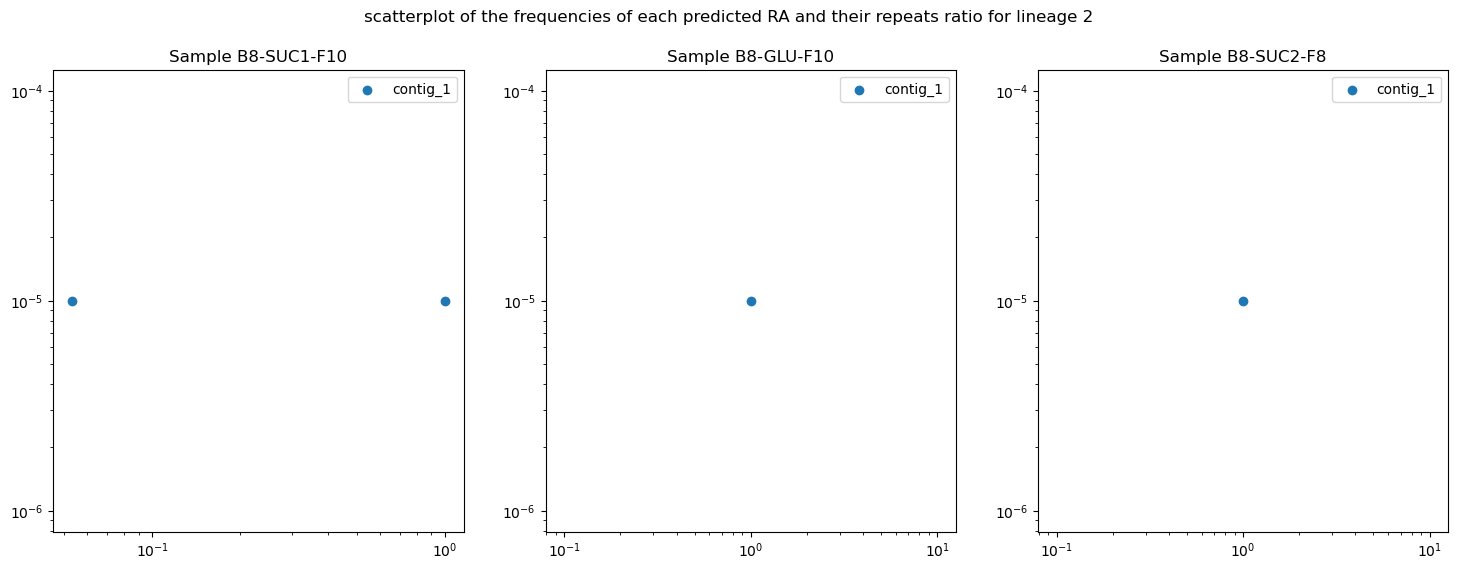

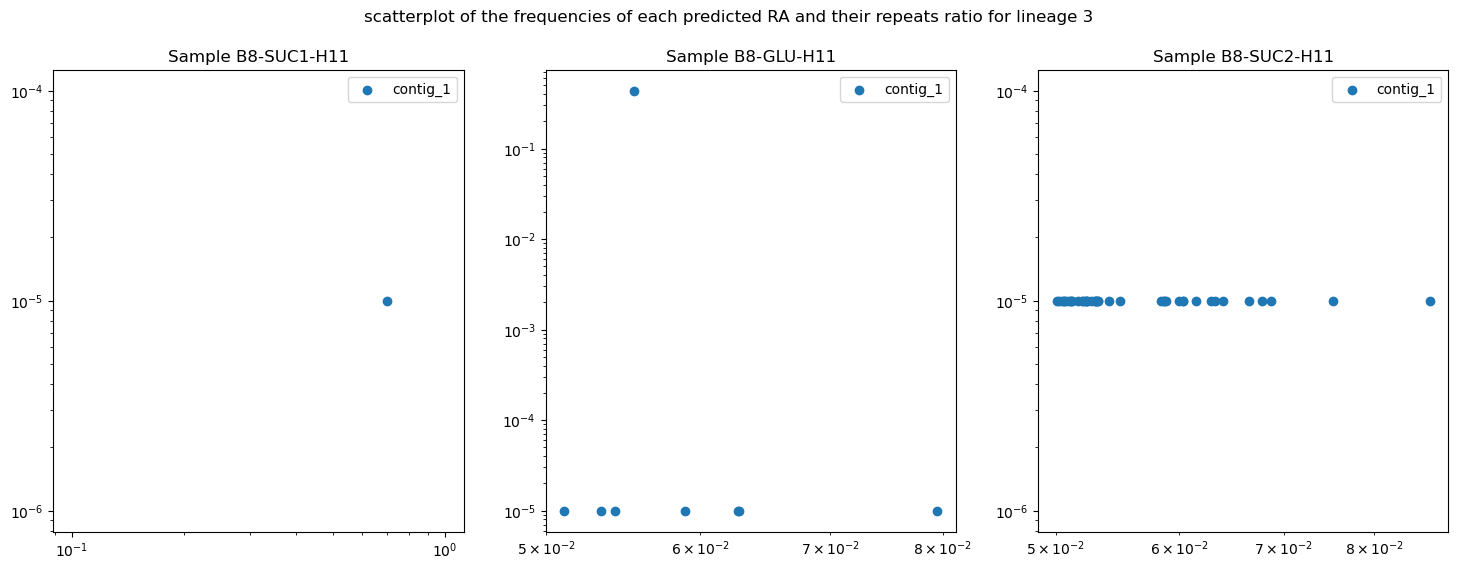

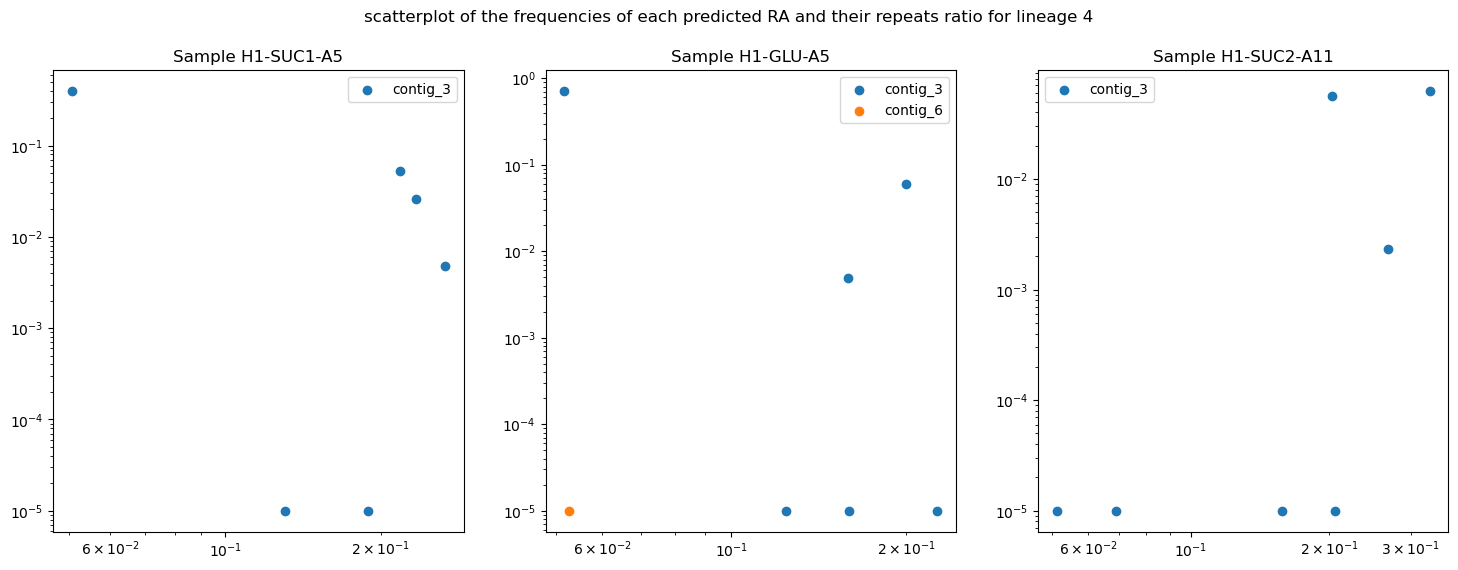

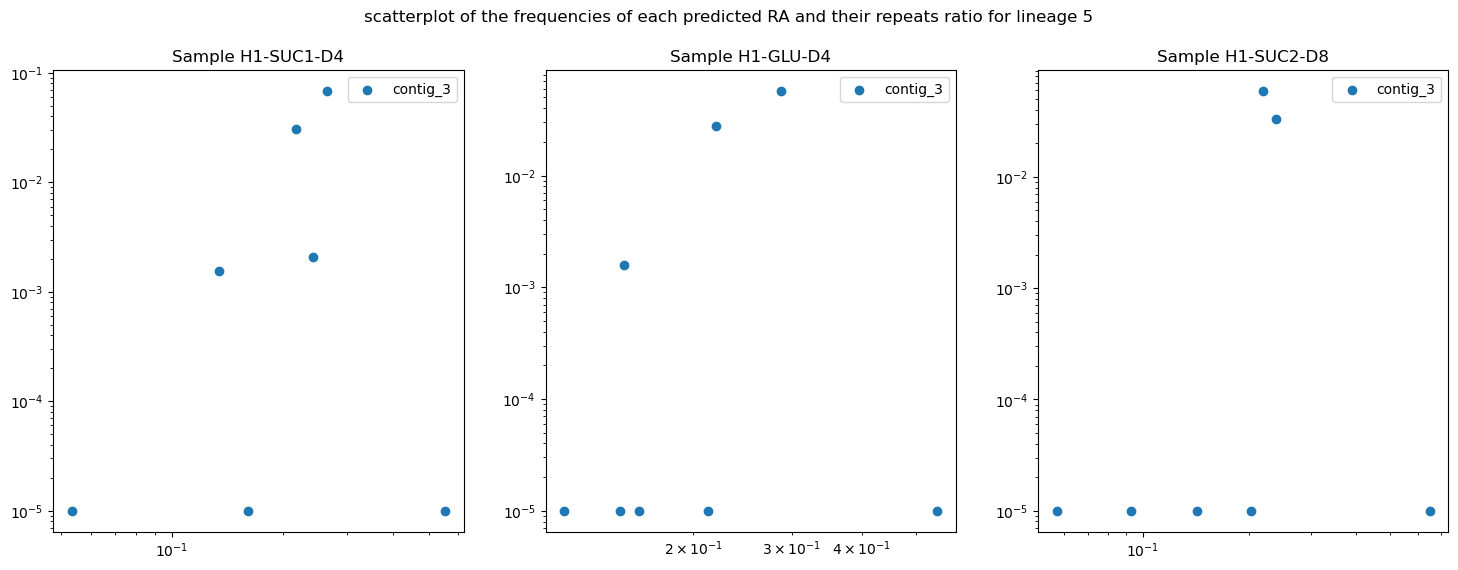

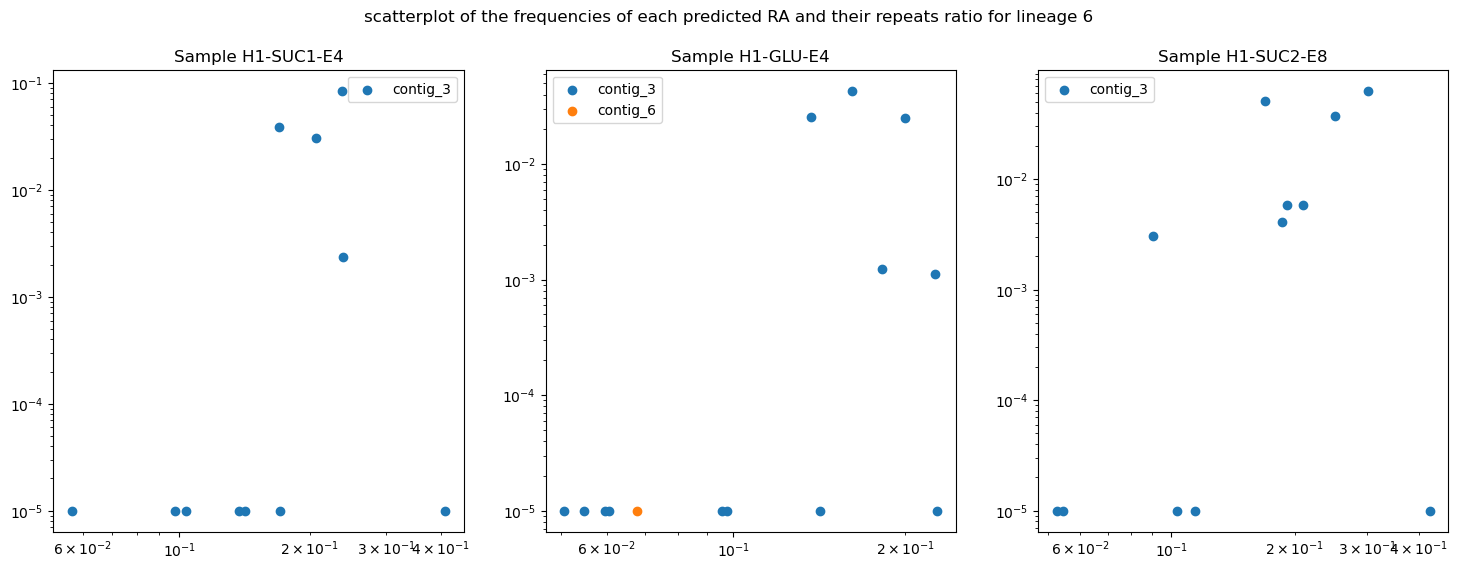

In [311]:
#for each sample make a scatterplot that shows on the x-axis the position of the mutation for the contig; on the y-axis, their ratio
#make a histogram for the RATIO BETWEEN REPEAT READS COVERAGE AND TOTAL READ COVERAGE

print('WARNING! 10^-5 frequencies menas that only unique reads are mapping with that mutation!')
variant_option = 'RA'
for i in dict_lineages.keys():
    working_df = dict_lineages[i]
    fig, axes = plt.subplots(nrows=1, ncols=len(working_df), figsize=(6 * len(working_df), 6), squeeze=False)    
    
    for idx, sample in enumerate(working_df['Sample_name']):
        ax = axes[0,idx]
        sample_dir = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/'+ sample + '-breseq/data/bam2cov_table/'
        cov_file = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/'+ sample + '-breseq/data/coverage.csv'
        cov_csv = pd.read_csv(cov_file, sep = '\t', names = ['Contig', 'Position', 'Coverage'])
        contigs = pd.Series(np.unique(cov_csv['Contig']))
        
        for contig in contigs:
            bam2cov_file = sample_dir + contig + '_coverage.tab'
            bam2cov_csv = pd.read_csv(bam2cov_file, sep = '\t', comment = '#')
            unique_cov = bam2cov_csv['unique_top_cov'].astype(float) + bam2cov_csv['unique_bot_cov'].astype(float)
            redundant_cov = bam2cov_csv['redundant_top_cov'].astype(float) + bam2cov_csv['redundant_bot_cov'].astype(float)
            repeat_ratio = (redundant_cov / (unique_cov + redundant_cov)).fillna(0) + pow(10, -5)
            contig_len = len(bam2cov_csv)
            bam2cov_csv['repeat_ratio'] = repeat_ratio
            
            mutation_data_og = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names, comment = '#')
            mutation_data = mutation_data_og[(mutation_data_og['col_0']==variant_option) & (mutation_data_og['col_3']==contig)]
            
            mutant_coverages = bam2cov_csv[bam2cov_csv['position'].isin(mutation_data['col_4'])]
            
            only_frequencies_mask = mutation_data.astype(str).apply(lambda row: row.str.startswith('frequency='))
            only_frequencies_df = mutation_data[(only_frequencies_mask)] #only considering the boxes with frequency data

            if not only_frequencies_df.empty:
                frequencies_mutations = only_frequencies_df.bfill(axis=1)['col_0'].str.strip('frequency=').astype(float) #aligning them
                frequencies_indexed = pd.concat([ mutation_data['col_4'].astype(float), frequencies_mutations], axis=1)
                frequencies_indexed.columns = ['position','frequency']

                ax.scatter(frequencies_indexed['frequency'], mutant_coverages['repeat_ratio'])


        ax.legend(contigs.str.rstrip('_pilon'))
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title('Sample '+sample)
    fig.suptitle('scatterplot of the frequencies of each predicted '+ variant_option +' and their repeats ratio for lineage '+str(i))
    fig.show()


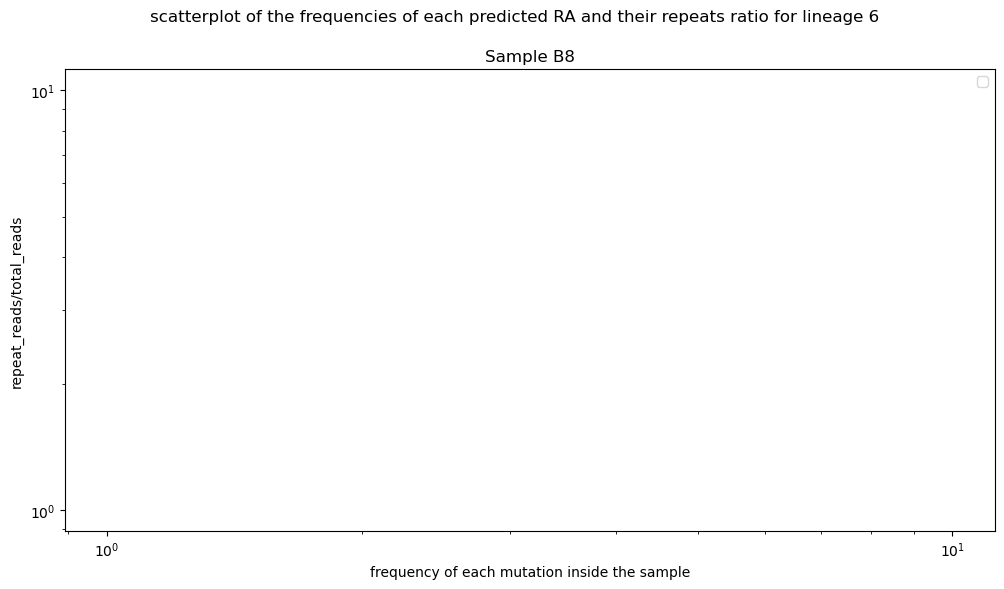

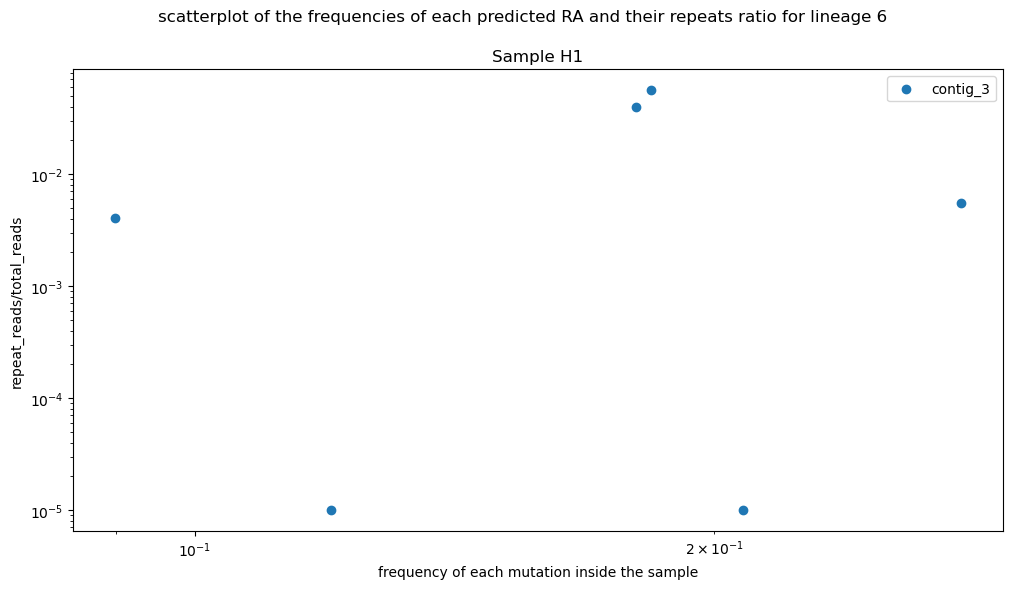

In [325]:
#for each REFERENCE SAMPLE make a scatterplot that shows on the x-axis the position of the mutation for the contig; on the y-axis, their ratio
#make a histogram for the RATIO BETWEEN REPEAT READS COVERAGE AND TOTAL READ COVERAGE
print('WARNING! 10^-5 frequencies menas that only unique reads are mapping with that mutation!')
variant_option = 'RA'

for sample in dict_precultures.keys():
    fig, ax = plt.subplots(figsize=(12, 6))     
    sample_dir = '/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/'+ pars_folder + '/Pre-culture-'+ sample + '-breseq/data/bam2cov_table/'
    cov_file = dict_precultures[sample]
    cov_csv = pd.read_csv(cov_file, sep = '\t', names = ['Contig', 'Position', 'Coverage'])
    contigs = pd.Series(np.unique(cov_csv['Contig']))
        
        
    for contig in contigs:
        bam2cov_file = sample_dir + contig + '_coverage.tab'
        bam2cov_csv = pd.read_csv(bam2cov_file, sep = '\t', comment = '#')
        unique_cov = bam2cov_csv['unique_top_cov'].astype(float) + bam2cov_csv['unique_bot_cov'].astype(float)
        redundant_cov = bam2cov_csv['redundant_top_cov'].astype(float) + bam2cov_csv['redundant_bot_cov'].astype(float)
        repeat_ratio = (redundant_cov / (unique_cov + redundant_cov)).fillna(0) + pow(10, -5)
        contig_len = len(bam2cov_csv)
        bam2cov_csv['repeat_ratio'] = repeat_ratio
        
        mutation_data_og = pd.read_csv('/scicore/home/nimwegen/cappel0001/BZRS_PROJECT/breseq_test/' + pars_folder + '/Pre-culture-'+sample+'-breseq/data/annotated.gd', sep='\t', names = column_names, comment = '#')
        mutation_data = mutation_data_og[(mutation_data_og['col_0']==variant_option) & (mutation_data_og['col_3']==contig)]
        
        mutant_coverages = bam2cov_csv[bam2cov_csv['position'].isin(mutation_data['col_4'])]
        mutant_coverages.index = bam2cov_csv[bam2cov_csv['position'].isin(mutation_data['col_4'])]['position']

        only_frequencies_mask = mutation_data.astype(str).apply(lambda row: row.str.startswith('frequency='))
        only_frequencies_df = mutation_data[(only_frequencies_mask)] #only considering the boxes with frequency data

        if not only_frequencies_df.empty:
            frequencies_mutations = only_frequencies_df.bfill(axis=1)['col_0'].str.strip('frequency=').astype(float) #aligning them
            frequencies_indexed = pd.concat([ mutation_data['col_4'].astype(int), frequencies_mutations], axis=1)
            frequencies_indexed.columns = ['position','frequency']

            ax.scatter(frequencies_indexed['frequency'], mutant_coverages['repeat_ratio'])

        ax.legend(contigs.str.rstrip('_pilon'))
        ax.set_xlabel('frequency of each mutation inside the sample')
        ax.set_ylabel('repeat_reads/total_reads')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title('Sample '+sample)
    fig.suptitle('scatterplot of the frequencies of each predicted '+ variant_option +' and their repeats ratio for lineage '+str(i))
    fig.show()